In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.6 MB/s eta 0:00:00


In [ ]:
# Cell-1 Environment setup and seeds

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torch_geometric
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.data import Data, DataLoader as GeometricDataLoader
from torch_geometric.utils import add_self_loops, degree

import pandas as pd
import numpy as np
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Global constants
BATCH_SIZE_TRAIN = 32
BATCH_SIZE_VAL = 64
BATCH_SIZE_TEST = 64
LEARNING_RATE = 0.001
EPOCHS = 100
PATIENCE = 15

# Data paths
PATHS = {
    'netflix': '/content/drive/MyDrive/Netflix_1.csv',
    'zoom1': '/content/drive/MyDrive/Zoom_1.csv',
    'zoom2': '/content/drive/MyDrive/Zoom_2.csv',
    'zoom3': '/content/drive/MyDrive/Zoom_3.csv'
}

print("Environment setup complete")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Geometric version: {torch_geometric.__version__}")

Using device: cpu
Environment setup complete
PyTorch version: 2.8.0+cu126
PyTorch Geometric version: 2.6.1


In [ ]:
# Cell-2 Data paths and availability


import os

# Check file existence and basic info
data_info = {}

for name, path in PATHS.items():
    if os.path.exists(path):
        # Get file size
        size_mb = os.path.getsize(path) / (1024 * 1024)

        # Load and preview
        df = pd.read_csv(path, nrows=1000)  # Preview first 1000 rows

        data_info[name] = {
            'path': path,
            'exists': True,
            'size_mb': round(size_mb, 2),
            'preview_rows': len(df),
            'columns': list(df.columns),
            'shape_preview': df.shape
        }

        print(f"\n{name.upper()} Dataset:")
        print(f"  Size: {size_mb:.2f} MB")
        print(f"  Columns: {df.columns.tolist()}")
        print(f"  Preview shape: {df.shape}")
        print(f"  First few rows:")
        print(df.head(3))

    else:
        data_info[name] = {
            'path': path,
            'exists': False,
            'error': 'File not found'
        }
        print(f"\nERROR: {name} file not found at {path}")

print(f"\nData availability summary:")
available_files = sum(1 for info in data_info.values() if info['exists'])
print(f"Available files: {available_files}/{len(PATHS)}")


NETFLIX Dataset:
  Size: 704.59 MB
  Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
  Preview shape: (1000, 7)
  First few rows:
   No.                        Time        Source   Destination Protocol  \
0    3  2022-06-17 23:48:34.871426     192.0.0.2  10.215.173.2      TCP   
1    6  2022-06-17 23:48:34.953834  10.215.173.1    45.57.41.1      TCP   
2    7  2022-06-17 23:48:35.035546    45.57.41.1  10.215.173.1      TCP   

   Length                                               Info  
0      60  43968  >  853 [SYN] Seq=0 Win=65535 Len=0 MSS=...  
1      60  33420  >  443 [SYN] Seq=0 Win=65535 Len=0 MSS=...  
2      48  443  >  33420 [SYN, ACK] Seq=0 Ack=1 Win=1024 ...  

ZOOM1 Dataset:
  Size: 628.04 MB
  Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
  Preview shape: (1000, 7)
  First few rows:
   No.                        Time     Source    Destination Protocol  Length  \
0    2  2022-05-30 16:01:36.328035  192.0.

In [ ]:
# Cell-3 Schema inference and validation

def analyze_dataset_schema(df, dataset_name):
    """Analyze dataset schema and infer column meanings"""
    print(f"\n=== {dataset_name.upper()} SCHEMA ANALYSIS ===")

    # Basic info
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Data types:\n{df.dtypes}")

    # Missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nMissing values:\n{missing[missing > 0]}")
    else:
        print("\nNo missing values found")

    # Duplicates
    duplicates = df.duplicated().sum()
    print(f"Duplicate rows: {duplicates}")

    # Infer column purposes
    cols = df.columns.str.lower()

    # Time column detection
    time_cols = [col for col in df.columns if any(term in col.lower() for term in ['time', 'timestamp', 'ts', 'datetime'])]

    # Node column detection
    node_cols = [col for col in df.columns if any(term in col.lower() for term in ['src', 'dst', 'source', 'dest', 'from', 'to', 'node']) and col.lower() != 'protocol']

    # Traffic/size columns
    traffic_cols = [col for col in df.columns if any(term in col.lower() for term in ['len', 'length', 'size', 'bytes', 'packet', 'volume'])]

    # Label columns
    label_cols = [col for col in df.columns if any(term in col.lower() for term in ['label', 'class', 'target', 'bottleneck'])]

    print(f"\nInferred column purposes:")
    print(f"  Time columns: {time_cols}")
    print(f"  Node columns: {node_cols}")
    print(f"  Traffic columns: {traffic_cols}")
    print(f"  Label columns: {label_cols}")

    # Unique values for categorical columns
    for col in df.columns:
        unique_vals = df[col].nunique()
        if unique_vals < 20 and df[col].dtype == 'object':
            print(f"  {col} unique values: {df[col].unique()}")

    # Time range if time column exists
    if time_cols:
        time_col = time_cols[0]
        try:
            df[time_col] = pd.to_datetime(df[time_col])
            print(f"\nTime range: {df[time_col].min()} to {df[time_col].max()}")
            print(f"Duration: {df[time_col].max() - df[time_col].min()}")
        except:
            print(f"Could not parse {time_col} as datetime")

    # Unique nodes count
    if len(node_cols) >= 2:
        src_col, dst_col = node_cols[0], node_cols[1]
        unique_nodes = set(df[src_col].unique()) | set(df[dst_col].unique())
        print(f"\nUnique nodes: {len(unique_nodes)}")
        print(f"Source nodes: {df[src_col].nunique()}")
        print(f"Destination nodes: {df[dst_col].nunique()}")

    return {
        'time_cols': time_cols,
        'node_cols': node_cols,
        'traffic_cols': traffic_cols,
        'label_cols': label_cols,
        'shape': df.shape,
        'missing': missing.sum(),
        'duplicates': duplicates
    }

# Analyze each dataset
schemas = {}
for name, path in PATHS.items():
    if os.path.exists(path):
        df = pd.read_csv(path, nrows=5000)  # Analyze first 5000 rows
        schemas[name] = analyze_dataset_schema(df, name)

print(f"\n=== SCHEMA SUMMARY ===")
for name, schema in schemas.items():
    print(f"{name}: {schema['shape'][0]} rows, {schema['shape'][1]} cols, {schema['missing']} missing, {schema['duplicates']} duplicates")


=== NETFLIX SCHEMA ANALYSIS ===
Shape: (5000, 7)
Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
Data types:
No.             int64
Time           object
Source         object
Destination    object
Protocol       object
Length          int64
Info           object
dtype: object

No missing values found
Duplicate rows: 0

Inferred column purposes:
  Time columns: ['Time']
  Node columns: ['Source', 'Destination']
  Traffic columns: ['Length']
  Label columns: []
  Source unique values: ['192.0.0.2' '10.215.173.1' '45.57.41.1' '23.246.46.167' '54.189.33.245']
  Destination unique values: ['10.215.173.2' '45.57.41.1' '10.215.173.1' '23.246.46.167'
 '54.189.33.245']
  Protocol unique values: ['TCP' 'TLSv1.3']

Time range: 2022-06-17 23:48:34.871426 to 2022-06-17 23:49:35.646048
Duration: 0 days 00:01:00.774622

Unique nodes: 6
Source nodes: 5
Destination nodes: 5

=== ZOOM1 SCHEMA ANALYSIS ===
Shape: (5000, 7)
Columns: ['No.', 'Time', 'Source', 'Destination',

In [ ]:
# cell-4 Data cleaning

import pandas as pd
import os

def clean_dataset(df, dataset_name):
    """Clean and standardize dataset format"""
    print(f"\nCleaning {dataset_name}...")
    original_shape = df.shape

    # Make a copy
    df_clean = df.copy()

    # Standardize column names based on common patterns
    col_mapping = {}

    for col in df_clean.columns:
        col_lower = col.lower()
        col_words = col_lower.replace('_', ' ').replace('.', ' ').split()

        # Time column
        time_terms = ['time', 'timestamp', 'ts']
        if any(t in col_words for t in time_terms):
            col_mapping[col] = 'Time'

        # Source node
        elif any(t in col_words for t in ['src', 'source', 'from']) and 'ip' not in col_words:
            col_mapping[col] = 'Source'

        # Destination node
        elif any(t in col_words for t in ['dst', 'dest', 'destination', 'to']) and 'ip' not in col_words:
            col_mapping[col] = 'Destination'

        # Traffic/length
        elif any(t in col_words for t in ['len', 'length', 'size', 'bytes']):
            col_mapping[col] = 'Length'

        # Protocol
        elif any(t in col_words for t in ['protocol', 'proto']):
            col_mapping[col] = 'Protocol'

        # Port information
        elif 'port' in col_words:
            if any(t in col_words for t in ['src', 'source']):
                col_mapping[col] = 'SrcPort'
            elif any(t in col_words for t in ['dst', 'dest', 'destination']):
                col_mapping[col] = 'DstPort'

    # Apply column renaming
    df_clean = df_clean.rename(columns=col_mapping)
    print(f"Renamed columns: {col_mapping}")

    # Ensure we have minimum required columns
    required_cols = ['Time', 'Source', 'Destination']
    missing_required = [col for col in required_cols if col not in df_clean.columns]

    if missing_required:
        print(f"WARNING: Missing required columns: {missing_required}")
        # Try to infer from available columns
        available_cols = df_clean.columns.tolist()
        print(f"Available columns: {available_cols}")

        # Use first few columns as fallback
        if len(available_cols) >= 3:
            fallback_mapping = {
                available_cols[0]: 'Time',
                available_cols[1]: 'Source',
                available_cols[2]: 'Destination'
            }
            df_clean = df_clean.rename(columns=fallback_mapping)
            print(f"Used fallback mapping: {fallback_mapping}")

    # Data type conversions
    try:
        # Convert time to numeric if possible
        if 'Time' in df_clean.columns:
            if df_clean['Time'].dtype == 'object':
                try:
                    df_clean['Time'] = pd.to_datetime(df_clean['Time'])
                    # Convert to milliseconds for higher precision
                    df_clean['Time'] = df_clean['Time'].astype('int64') // 10**6
                except:
                    df_clean['Time'] = pd.to_numeric(df_clean['Time'], errors='coerce')

        # Ensure source/destination are strings
        for col in ['Source', 'Destination']:
            if col in df_clean.columns:
                df_clean[col] = df_clean[col].astype(str)

        # Convert length to numeric
        if 'Length' in df_clean.columns:
            df_clean['Length'] = pd.to_numeric(df_clean['Length'], errors='coerce')
        else:
            # Create default length column
            df_clean['Length'] = 1.0

    except Exception as e:
        print(f"Warning: Data type conversion error: {e}")

    # Remove invalid rows
    initial_len = len(df_clean)

    # Remove rows with missing source or destination
    df_clean = df_clean.dropna(subset=['Source', 'Destination'])

    # Remove rows where source equals destination
    df_clean = df_clean[df_clean['Source'] != df_clean['Destination']]

    # Remove negative lengths
    if 'Length' in df_clean.columns:
        df_clean = df_clean[df_clean['Length'] >= 0]

    # Remove duplicates
    df_clean = df_clean.drop_duplicates()

    final_len = len(df_clean)
    print(f"Removed {initial_len - final_len} invalid rows ({final_len} remaining)")

    print(f"Final shape: {df_clean.shape} (was {original_shape})")
    print(f"Final columns: {df_clean.columns.tolist()}")

    return df_clean

# Clean all datasets
cleaned_data = {}
for name, path in PATHS.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        cleaned_data[name] = clean_dataset(df, name)

print("\n=== CLEANING SUMMARY ===")
for name, df in cleaned_data.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")
    if len(df) > 0:
        print(f"  Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f}")
        print(f"  Unique nodes: {len(set(df['Source'].unique()) | set(df['Destination'].unique()))}")


Cleaning netflix...
Renamed columns: {'Time': 'Time', 'Source': 'Source', 'Destination': 'Destination', 'Protocol': 'Protocol', 'Length': 'Length'}
Removed 0 invalid rows (4290778 remaining)
Final shape: (4290778, 7) (was (4290778, 7))
Final columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']

Cleaning zoom1...
Renamed columns: {'Time': 'Time', 'Source': 'Source', 'Destination': 'Destination', 'Protocol': 'Protocol', 'Length': 'Length'}
Removed 0 invalid rows (6095138 remaining)
Final shape: (6095138, 7) (was (6095138, 7))
Final columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']

Cleaning zoom2...
Renamed columns: {'Time': 'Time', 'Source': 'Source', 'Destination': 'Destination', 'Protocol': 'Protocol', 'Length': 'Length'}
Removed 0 invalid rows (5810990 remaining)
Final shape: (5810990, 7) (was (5810990, 7))
Final columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']

Cleaning zoom3...
Renamed columns:

In [ ]:
# Cell-5 Define bottleneck labeling policy


import numpy as np
import pandas as pd

BOTTLENECK_THRESHOLD_PERCENTILE = 85  # Top 15% of nodes by traffic
DEGREE_PERCENTILE = 70  # Minimum connections set to 70th percentile of node degrees

def compute_node_bottleneck_labels(df, threshold_percentile=BOTTLENECK_THRESHOLD_PERCENTILE, degree_percentile=DEGREE_PERCENTILE):
    """
    Compute bottleneck labels for nodes based on traffic and connectivity.

    Bottleneck definition:
    1. Node has traffic volume >= threshold_percentile
    2. Node has degree >= degree_percentile of all nodes
    3. Combines both in-traffic and out-traffic
    """
    # Calculate in-traffic (traffic flowing TO the node)
    in_traffic = df.groupby('Destination')['Length'].sum()

    # Calculate out-traffic (traffic flowing FROM the node)
    out_traffic = df.groupby('Source')['Length'].sum()

    # Calculate node degree (number of unique connections)
    in_degree = df.groupby('Destination').size()
    out_degree = df.groupby('Source').size()

    # Get all unique nodes
    all_nodes = set(df['Source'].unique()) | set(df['Destination'].unique())

    # Combine traffic and degree info
    node_stats = []
    for node in all_nodes:
        total_traffic = in_traffic.get(node, 0) + out_traffic.get(node, 0)
        # Compute degree as number of unique connections (avoid double-counting)
        in_count = in_degree.get(node, 0)
        out_count = out_degree.get(node, 0)
        total_degree = in_count + out_count  # Sum in and out degrees

        node_stats.append({
            'node': node,
            'total_traffic': total_traffic,
            'in_traffic': in_traffic.get(node, 0),
            'out_traffic': out_traffic.get(node, 0),
            'total_degree': total_degree,
            'in_degree': in_count,
            'out_degree': out_count
        })

    # Convert to DataFrame
    node_df = pd.DataFrame(node_stats)

    # Calculate thresholds
    traffic_threshold = np.percentile(node_df['total_traffic'].dropna(), threshold_percentile)
    degrees = node_df['total_degree'].dropna()
    min_connections = max(3, int(np.percentile(degrees, degree_percentile)) if len(degrees) > 0 else 3)

    # Define bottlenecks based on criteria
    node_df['is_bottleneck'] = (
        (node_df['total_traffic'] >= traffic_threshold) &
        (node_df['total_degree'] >= min_connections)
    ).astype(int)

    # Create node to label mapping
    node_label_map = dict(zip(node_df['node'], node_df['is_bottleneck']))

    # Debug logging
    print(f"Bottleneck labeling policy for {df.name if hasattr(df, 'name') else 'dataset'}:")
    print(f"  Traffic threshold (>= {threshold_percentile}th percentile): {traffic_threshold:.2f}")
    print(f"  Degree threshold (>= {degree_percentile}th percentile): {min_connections}")
    print(f"  Degree distribution: min={degrees.min() if len(degrees) > 0 else 0}, "
          f"max={degrees.max() if len(degrees) > 0 else 0}, "
          f"mean={degrees.mean() if len(degrees) > 0 else 0:.1f}")
    print(f"  Total nodes: {len(all_nodes)}")
    print(f"  Bottleneck nodes: {node_df['is_bottleneck'].sum()}")
    print(f"  Bottleneck percentage: {100 * node_df['is_bottleneck'].mean():.1f}%")
    if node_df['is_bottleneck'].sum() > 0:
        print(f"  Bottleneck node details:")
        for _, row in node_df[node_df['is_bottleneck'] == 1][['node', 'total_traffic', 'total_degree']].iterrows():
            print(f"    {row['node']}: traffic={row['total_traffic']:.1f}, degree={row['total_degree']}")

    return node_label_map, node_df

# Test labeling policy on all cleaned datasets
for name, df in cleaned_data.items():
    df.name = name  # Assign name for printing
    print(f"\nTesting bottleneck labeling on {name}:")
    labels, stats = compute_node_bottleneck_labels(df)

    # Show top bottlenecks
    top_bottlenecks = stats.nlargest(10, 'total_traffic')
    print(f"\nTop 10 nodes by traffic:")
    for _, row in top_bottlenecks.iterrows():
        status = "BOTTLENECK" if row['is_bottleneck'] else "normal"
        print(f"  {row['node']}: traffic={row['total_traffic']:.1f}, degree={row['total_degree']}, {status}")

# Rationale for chosen thresholds
print(f"\nLabel policy rationale:")
print(f"1. Traffic-based: Nodes handling >= {BOTTLENECK_THRESHOLD_PERCENTILE}th percentile traffic are high-load")
print(f"2. Connectivity-based: Nodes with >= {DEGREE_PERCENTILE}th percentile connections are critical junction points")
print(f"3. Combined criteria: Both conditions must be met to avoid false positives")
print(f"4. Adaptive degree threshold (min 3) ensures robustness across network sizes")


Testing bottleneck labeling on netflix:
Bottleneck labeling policy for netflix:
  Traffic threshold (>= 85th percentile): 395065478.90
  Degree threshold (>= 70th percentile): 268411
  Degree distribution: min=7, max=4290771, mean=214538.9
  Total nodes: 40
  Bottleneck nodes: 6
  Bottleneck percentage: 15.0%
  Bottleneck node details:
    23.246.46.177: traffic=403629115.0, degree=349797
    23.246.46.143: traffic=448008819.0, degree=391115
    23.246.46.150: traffic=654705538.0, degree=541910
    10.215.173.1: traffic=5023548449.0, degree=4290771
    23.246.46.135: traffic=463839471.0, degree=400793
    23.246.46.148: traffic=426552291.0, degree=359362

Top 10 nodes by traffic:
  10.215.173.1: traffic=5023548449.0, degree=4290771, BOTTLENECK
  23.246.46.150: traffic=654705538.0, degree=541910, BOTTLENECK
  23.246.46.135: traffic=463839471.0, degree=400793, BOTTLENECK
  23.246.46.143: traffic=448008819.0, degree=391115, BOTTLENECK
  23.246.46.148: traffic=426552291.0, degree=359362, 

In [ ]:
# Cell-6 Compute bottleneck counts for each dataset

import pandas as pd
import numpy as np

bottleneck_summary = []

print("BOTTLENECK DETECTION SUMMARY")
print("=" * 50)

for dataset_name, df in cleaned_data.items():
    if len(df) == 0:
        continue

    print(f"\nProcessing {dataset_name.upper()}...")

    # Get bottleneck labels
    node_labels, node_stats = compute_node_bottleneck_labels(df)

    # Calculate summary statistics
    total_nodes = len(node_labels)
    bottleneck_nodes = sum(node_labels.values())
    normal_nodes = total_nodes - bottleneck_nodes
    pct_bottleneck = (bottleneck_nodes / total_nodes) * 100 if total_nodes > 0 else 0

    # Traffic statistics
    total_traffic = node_stats['total_traffic'].sum()
    bottleneck_traffic = node_stats[node_stats['is_bottleneck'] == 1]['total_traffic'].sum()
    pct_traffic_bottlenecks = (bottleneck_traffic / total_traffic) * 100 if total_traffic > 0 else 0

    # Degree statistics for bottlenecks
    bottleneck_degrees = node_stats[node_stats['is_bottleneck'] == 1]['total_degree']
    avg_bottleneck_degree = bottleneck_degrees.mean() if len(bottleneck_degrees) > 0 else 0

    summary = {
        'dataset': dataset_name,
        'total_nodes': total_nodes,
        'bottleneck_nodes': bottleneck_nodes,
        'normal_nodes': normal_nodes,
        'pct_bottleneck': pct_bottleneck,
        'total_edges': len(df),
        'pct_traffic_bottlenecks': pct_traffic_bottlenecks,
        'avg_bottleneck_degree': avg_bottleneck_degree
    }

    bottleneck_summary.append(summary)

    print(f"  Total nodes: {total_nodes}")
    print(f"  Bottleneck nodes: {bottleneck_nodes} ({pct_bottleneck:.1f}%)")
    print(f"  Normal nodes: {normal_nodes} ({100-pct_bottleneck:.1f}%)")
    print(f"  Total edges: {len(df)}")
    print(f"  Traffic handled by bottlenecks: {pct_traffic_bottlenecks:.1f}%")
    print(f"  Average degree of bottleneck nodes: {avg_bottleneck_degree:.1f}")

# Create summary table
summary_df = pd.DataFrame(bottleneck_summary)

print(f"\n{'='*70}")
print("BOTTLENECK SUMMARY TABLE")
print(f"{'='*70}")
print(f"{'Dataset':<15} {'Total Nodes':<12} {'Bottlenecks':<12} {'% Bottleneck':<12} {'Total Edges':<12} {'% Traffic':<12} {'Avg Btl Degree':<12}")
print(f"{'-'*70}")

for _, row in summary_df.iterrows():
    print(f"{row['dataset']:<15} {row['total_nodes']:<12} {row['bottleneck_nodes']:<12} {row['pct_bottleneck']:<12.1f} {row['total_edges']:<12} {row['pct_traffic_bottlenecks']:<12.1f} {row['avg_bottleneck_degree']:<12.1f}")

print(f"{'-'*70}")

# Overall statistics
if len(summary_df) > 0:
    total_nodes_all = summary_df['total_nodes'].sum()
    total_bottlenecks_all = summary_df['bottleneck_nodes'].sum()
    avg_bottleneck_pct = summary_df['pct_bottleneck'].mean()

    print(f"{'OVERALL':<15} {total_nodes_all:<12} {total_bottlenecks_all:<12} {avg_bottleneck_pct:<12.1f} {summary_df['total_edges'].sum():<12} {summary_df['pct_traffic_bottlenecks'].mean():<12.1f} {summary_df['avg_bottleneck_degree'].mean():<12.1f}")

print(f"\nClass Balance Analysis:")
print(f"  Average bottleneck percentage: {avg_bottleneck_pct:.1f}%")
if avg_bottleneck_pct < 5:
    print("  WARNING: Severe class imbalance detected (< 5% bottlenecks)")
    print("  Recommendation: Use class weighting and balanced metrics")
elif avg_bottleneck_pct > 40:
    print("  WARNING: High bottleneck percentage (> 40%)")
    print("  Recommendation: Review threshold criteria (traffic or degree percentiles)")
else:
    print("  Class balance is reasonable for classification")

# Store for later use
BOTTLENECK_SUMMARY = summary_df

BOTTLENECK DETECTION SUMMARY

Processing NETFLIX...
Bottleneck labeling policy for netflix:
  Traffic threshold (>= 85th percentile): 395065478.90
  Degree threshold (>= 70th percentile): 268411
  Degree distribution: min=7, max=4290771, mean=214538.9
  Total nodes: 40
  Bottleneck nodes: 6
  Bottleneck percentage: 15.0%
  Bottleneck node details:
    23.246.46.177: traffic=403629115.0, degree=349797
    23.246.46.143: traffic=448008819.0, degree=391115
    23.246.46.150: traffic=654705538.0, degree=541910
    10.215.173.1: traffic=5023548449.0, degree=4290771
    23.246.46.135: traffic=463839471.0, degree=400793
    23.246.46.148: traffic=426552291.0, degree=359362
  Total nodes: 40
  Bottleneck nodes: 6 (15.0%)
  Normal nodes: 34 (85.0%)
  Total edges: 4290778
  Traffic handled by bottlenecks: 73.9%
  Average degree of bottleneck nodes: 1055624.7

Processing ZOOM1...
Bottleneck labeling policy for zoom1:
  Traffic threshold (>= 85th percentile): 4142816409.40
  Degree threshold (>= 7

In [ ]:
# Cell-7  Temporal windowing configuration

import numpy as np

WINDOW_SIZE = 60  # seconds
OVERLAP_RATIO = 0.5  # 50% overlap between consecutive windows
MIN_EDGES_PER_WINDOW = 10  # Minimum edges required for a valid snapshot

def define_temporal_windows(df, window_size=WINDOW_SIZE, overlap_ratio=OVERLAP_RATIO):
    """
    Define temporal windows for graph snapshots

    Args:
        df: DataFrame with Time column
        window_size: Duration of each window in seconds
        overlap_ratio: Fraction of overlap between windows (0-1)

    Returns:
        List of (start_time, end_time) tuples
    """

    if 'Time' not in df.columns or len(df) == 0:
        return []

    # Get time range
    min_time = df['Time'].min()
    max_time = df['Time'].max()
    total_duration = max_time - min_time

    print(f"Temporal Windowing Strategy:")
    print(f"  Window size: {window_size} seconds (in ms: {window_size*1000})") # Added ms conversion
    print(f"  Overlap ratio: {overlap_ratio*100:.1f}%")
    print(f"  Step size: {window_size * (1-overlap_ratio):.1f} seconds (in ms: {window_size * (1-overlap_ratio)*1000:.1f})") # Added ms conversion
    print(f"  Total time range: {total_duration:.1f} ms") # Changed to ms
    print(f"  Min edges per window: {MIN_EDGES_PER_WINDOW}")

    # Calculate step size
    step_size = window_size * (1 - overlap_ratio) * 1000 # Convert to ms

    # Convert window size to ms
    window_size_ms = window_size * 1000

    # Generate potential windows (in ms) - vectorized
    num_windows = int((max_time - min_time - window_size_ms) / step_size) + 1
    if num_windows <= 0:
        return []

    start_times = np.arange(num_windows) * step_size + min_time
    end_times = start_times + window_size_ms

    # Filter out windows that exceed max_time
    valid_mask = end_times <= max_time
    start_times = start_times[valid_mask]
    end_times = end_times[valid_mask]

    windows_ms = list(zip(start_times, end_times))

    print(f"  Generated {len(windows_ms)} potential windows")

    # --- Optimization: Pre-sort once and use vectorized operations ---
    # Sort times once and convert to numpy array for faster operations
    sorted_times = np.sort(df['Time'].values)

    # Vectorized searchsorted for all windows at once
    start_indices = np.searchsorted(sorted_times, start_times, side='left')
    end_indices = np.searchsorted(sorted_times, end_times, side='left')

    # Calculate edge counts for all windows
    edge_counts = end_indices - start_indices

    # Filter valid windows
    valid_mask = edge_counts >= MIN_EDGES_PER_WINDOW
    valid_windows = [(int(start_times[i]), int(end_times[i])) for i in range(len(start_times)) if valid_mask[i]]

    print(f"  Valid windows (>= {MIN_EDGES_PER_WINDOW} edges): {len(valid_windows)}")

    return valid_windows

# Analyze temporal characteristics of each dataset
temporal_info = {}

for dataset_name, df in cleaned_data.items():
    if len(df) == 0:
        continue

    print(f"\n=== {dataset_name.upper()} TEMPORAL ANALYSIS ===")

    # Basic temporal stats
    if 'Time' in df.columns:
        time_range = df['Time'].max() - df['Time'].min()
        unique_times = df['Time'].nunique()
        # Average edges per millisecond
        avg_edges_per_ms = len(df) / time_range if time_range > 0 else 0

        print(f"  Time range: {time_range:.1f} ms ({time_range/1000:.1f} seconds, {time_range/60000:.1f} minutes)") # Changed to ms
        print(f"  Unique timestamps: {unique_times}")
        print(f"  Average edges/ms: {avg_edges_per_ms:.4f}") # Changed to edges/ms

        # Generate windows
        windows = define_temporal_windows(df)

        temporal_info[dataset_name] = {
            'time_range': time_range,
            'unique_times': unique_times,
            'edges_per_ms': avg_edges_per_ms, # Changed key name
            'windows': windows,
            'total_edges': len(df)
        }

        # Window size distribution - optimized
        if windows:
            # Pre-sort times once for all window calculations
            sorted_times = np.sort(df['Time'].values)

            # Vectorized calculation of window sizes
            start_times_arr = np.array([w[0] for w in windows])
            end_times_arr = np.array([w[1] for w in windows])

            start_indices = np.searchsorted(sorted_times, start_times_arr, side='left')
            end_indices = np.searchsorted(sorted_times, end_times_arr, side='left')
            window_sizes = end_indices - start_indices

            print(f"  Window sizes: min={window_sizes.min()}, max={window_sizes.max()}, avg={window_sizes.mean():.1f}")
    else:
        print("  No time column found")
        temporal_info[dataset_name] = {
            'time_range': 0,
            'unique_times': 0,
            'edges_per_ms': 0, # Changed key name
            'windows': [],
            'total_edges': len(df)
        }

print(f"\n=== TEMPORAL WINDOWING SUMMARY ===")
for name, info in temporal_info.items():
    print(f"{name}: {len(info['windows'])} windows, {info['total_edges']} total edges")

# Strategy justification
print(f"\nWindowing Strategy Justification:")
print(f"1. Window size ({WINDOW_SIZE}s or {WINDOW_SIZE*1000}ms): Balance between temporal granularity and statistical significance") # Added ms
print(f"2. Overlap ({OVERLAP_RATIO*100:.0f}%): Captures temporal transitions while maintaining independence")
print(f"3. Minimum edges ({MIN_EDGES_PER_WINDOW}): Ensures sufficient data for meaningful graph analysis")
print(f"4. This approach captures network dynamics while providing stable snapshots for GCN training")

TEMPORAL_INFO = temporal_info


=== NETFLIX TEMPORAL ANALYSIS ===
  Time range: 88980204.0 ms (88980.2 seconds, 1483.0 minutes)
  Unique timestamps: 438099
  Average edges/ms: 0.0482
Temporal Windowing Strategy:
  Window size: 60 seconds (in ms: 60000)
  Overlap ratio: 50.0%
  Step size: 30.0 seconds (in ms: 30000.0)
  Total time range: 88980204.0 ms
  Min edges per window: 10
  Generated 2965 potential windows
  Valid windows (>= 10 edges): 2965
  Window sizes: min=15, max=12323, avg=2892.3

=== ZOOM1 TEMPORAL ANALYSIS ===
  Time range: 21144332.0 ms (21144.3 seconds, 352.4 minutes)
  Unique timestamps: 3794790
  Average edges/ms: 0.2883
Temporal Windowing Strategy:
  Window size: 60 seconds (in ms: 60000)
  Overlap ratio: 50.0%
  Step size: 30.0 seconds (in ms: 30000.0)
  Total time range: 21144332.0 ms
  Min edges per window: 10
  Generated 703 potential windows
  Valid windows (>= 10 edges): 703
  Window sizes: min=10458, max=20092, avg=17296.3

=== ZOOM2 TEMPORAL ANALYSIS ===
  Time range: 23580810.0 ms (23580.

In [ ]:
# Cell-8 Build graph snapshots

def create_graph_snapshot(df, start_time, end_time, snapshot_id):
    """
    Create a graph snapshot from network data within time window

    Args:
        df: Network data DataFrame
        start_time, end_time: Time window boundaries
        snapshot_id: Unique identifier for this snapshot

    Returns:
        Dict with snapshot metadata and edge data
    """

    # Filter data to time window
    window_df = df[(df['Time'] >= start_time) & (df['Time'] < end_time)].copy()

    if len(window_df) == 0:
        return None

    # Aggregate edges (sum traffic/length for same src-dst pairs)
    edge_agg = window_df.groupby(['Source', 'Destination']).agg({
        'Length': 'sum',  # Total traffic
        'Time': 'count'   # Number of packets
    }).reset_index()

    edge_agg.rename(columns={'Time': 'packet_count'}, inplace=True)

    # Get all unique nodes
    all_nodes = list(set(edge_agg['Source'].unique()) | set(edge_agg['Destination'].unique()))

    # Create node ID mapping
    node_to_id = {node: idx for idx, node in enumerate(all_nodes)}
    id_to_node = {idx: node for node, idx in node_to_id.items()}

    # Convert edges to numeric IDs
    edge_list = []
    edge_weights = []

    for _, row in edge_agg.iterrows():
        src_id = node_to_id[row['Source']]
        dst_id = node_to_id[row['Destination']]
        weight = row['Length']

        edge_list.append([src_id, dst_id])
        edge_weights.append(weight)

    snapshot_data = {
        'id': snapshot_id,
        'start_time': start_time,
        'end_time': end_time,
        'duration': end_time - start_time,
        'nodes': all_nodes,
        'node_count': len(all_nodes),
        'edge_count': len(edge_list),
        'node_to_id': node_to_id,
        'id_to_node': id_to_node,
        'edge_list': edge_list,
        'edge_weights': edge_weights,
        'total_traffic': sum(edge_weights),
        'raw_packet_count': len(window_df)
    }

    return snapshot_data

# Build snapshots for all datasets
all_snapshots = {}

for dataset_name, df in cleaned_data.items():
    if dataset_name not in temporal_info or len(temporal_info[dataset_name]['windows']) == 0:
        continue

    print(f"\nBuilding snapshots for {dataset_name.upper()}...")

    windows = temporal_info[dataset_name]['windows']
    snapshots = []

    for i, (start_time, end_time) in enumerate(windows):
        snapshot = create_graph_snapshot(df, start_time, end_time, f"{dataset_name}_snapshot_{i}")

        if snapshot is not None:
            snapshots.append(snapshot)

    all_snapshots[dataset_name] = snapshots

    if snapshots:
        # Summary statistics
        node_counts = [s['node_count'] for s in snapshots]
        edge_counts = [s['edge_count'] for s in snapshots]
        traffic_volumes = [s['total_traffic'] for s in snapshots]

        print(f"  Created {len(snapshots)} valid snapshots")
        print(f"  Nodes per snapshot: min={min(node_counts)}, max={max(node_counts)}, avg={np.mean(node_counts):.1f}")
        print(f"  Edges per snapshot: min={min(edge_counts)}, max={max(edge_counts)}, avg={np.mean(edge_counts):.1f}")
        print(f"  Traffic per snapshot: min={min(traffic_volumes):.1f}, max={max(traffic_volumes):.1f}, avg={np.mean(traffic_volumes):.1f}")

# Overall summary
total_snapshots = sum(len(snapshots) for snapshots in all_snapshots.values())
print(f"\n=== SNAPSHOT BUILDING SUMMARY ===")
print(f"Total snapshots created: {total_snapshots}")

for dataset_name, snapshots in all_snapshots.items():
    if snapshots:
        avg_nodes = np.mean([s['node_count'] for s in snapshots])
        avg_edges = np.mean([s['edge_count'] for s in snapshots])
        print(f"  {dataset_name}: {len(snapshots)} snapshots, avg {avg_nodes:.1f} nodes, avg {avg_edges:.1f} edges")

# Store metadata for next steps
SNAPSHOT_METADATA = {}
for dataset_name, snapshots in all_snapshots.items():
    if snapshots:
        SNAPSHOT_METADATA[dataset_name] = {
            'count': len(snapshots),
            'avg_nodes': np.mean([s['node_count'] for s in snapshots]),
            'avg_edges': np.mean([s['edge_count'] for s in snapshots]),
            'total_unique_nodes': len(set().union(*[s['nodes'] for s in snapshots]))
        }

ALL_SNAPSHOTS = all_snapshots


Building snapshots for NETFLIX...
  Created 2965 valid snapshots
  Nodes per snapshot: min=2, max=7, avg=3.2
  Edges per snapshot: min=2, max=10, avg=4.3
  Traffic per snapshot: min=5069.0, max=14022784.0, avg=3386700.3

Building snapshots for ZOOM1...
  Created 703 valid snapshots
  Nodes per snapshot: min=2, max=5, avg=3.0
  Edges per snapshot: min=2, max=7, avg=4.0
  Traffic per snapshot: min=4137084.0, max=14592741.0, avg=11756555.8

Building snapshots for ZOOM2...
  Created 785 valid snapshots
  Nodes per snapshot: min=2, max=5, avg=3.0
  Edges per snapshot: min=2, max=7, avg=3.9
  Traffic per snapshot: min=2277079.0, max=14392104.0, avg=11556400.4

Building snapshots for ZOOM3...
  Created 3144 valid snapshots
  Nodes per snapshot: min=2, max=4, avg=2.9
  Edges per snapshot: min=2, max=6, avg=3.8
  Traffic per snapshot: min=517120.0, max=15007481.0, avg=7111238.7

=== SNAPSHOT BUILDING SUMMARY ===
Total snapshots created: 7597
  netflix: 2965 snapshots, avg 3.2 nodes, avg 4.3 ed

In [ ]:
# Cell-9 Convert graph into NetworkX graph assembly

def create_networkx_graph(snapshot_data):
    """Convert snapshot data to NetworkX directed graph"""

    # Create directed graph
    G = nx.DiGraph()

    # Add nodes
    for node_name in snapshot_data['nodes']:
        G.add_node(node_name)

    # Add edges with weights
    for i, (src_id, dst_id) in enumerate(snapshot_data['edge_list']):
        src_node = snapshot_data['id_to_node'][src_id]
        dst_node = snapshot_data['id_to_node'][dst_id]
        weight = snapshot_data['edge_weights'][i]

        G.add_edge(src_node, dst_node, weight=weight)

    return G

# Convert all snapshots to NetworkX graphs
networkx_graphs = {}

for dataset_name, snapshots in all_snapshots.items():
    if not snapshots:
        continue

    print(f"\nConverting {dataset_name} snapshots to NetworkX graphs...")

    graphs = []
    for snapshot in snapshots:
        G = create_networkx_graph(snapshot)

        # Store graph with metadata
        graph_data = {
            'id': snapshot['id'],
            'graph': G,
            'metadata': {
                'start_time': snapshot['start_time'],
                'end_time': snapshot['end_time'],
                'node_count': snapshot['node_count'],
                'edge_count': snapshot['edge_count'],
                'total_traffic': snapshot['total_traffic'],
                'is_connected': nx.is_weakly_connected(G),
                'density': nx.density(G)
            }
        }

        graphs.append(graph_data)

    networkx_graphs[dataset_name] = graphs

    # Analysis of graph properties
    if graphs:
        connectivities = [g['metadata']['is_connected'] for g in graphs]
        densities = [g['metadata']['density'] for g in graphs]

        print(f"  Processed {len(graphs)} graphs")
        print(f"  Weakly connected: {sum(connectivities)}/{len(connectivities)} ({100*np.mean(connectivities):.1f}%)")
        print(f"  Average density: {np.mean(densities):.4f}")
        print(f"  Density range: {min(densities):.4f} to {max(densities):.4f}")

# Handle isolated nodes - add self-loops if needed
def add_isolated_node_handling(G):
    """Add self-loops to isolated nodes to ensure they have features"""
    isolated_nodes = list(nx.isolates(G))

    if isolated_nodes:
        for node in isolated_nodes:
            G.add_edge(node, node, weight=1.0)  # Add self-loop with unit weight

    return len(isolated_nodes)

# Apply isolated node handling
for dataset_name, graphs in networkx_graphs.items():
    isolated_counts = []

    for graph_data in graphs:
        isolated_count = add_isolated_node_handling(graph_data['graph'])
        isolated_counts.append(isolated_count)

    if isolated_counts and max(isolated_counts) > 0:
        print(f"\n{dataset_name}: Added self-loops to {sum(isolated_counts)} isolated nodes across all snapshots")
        print(f"  Max isolated nodes in single snapshot: {max(isolated_counts)}")

print(f"\n=== GRAPH ASSEMBLY SUMMARY ===")
total_graphs = sum(len(graphs) for graphs in networkx_graphs.values())
print(f"Total NetworkX graphs created: {total_graphs}")

for dataset_name, graphs in networkx_graphs.items():
    if graphs:
        avg_nodes = np.mean([g['metadata']['node_count'] for g in graphs])
        avg_edges = np.mean([g['metadata']['edge_count'] for g in graphs])
        avg_density = np.mean([g['metadata']['density'] for g in graphs])

        print(f"  {dataset_name}: {len(graphs)} graphs")
        print(f"    Avg nodes: {avg_nodes:.1f}, Avg edges: {avg_edges:.1f}, Avg density: {avg_density:.4f}")

# Store for next steps
NETWORKX_GRAPHS = networkx_graphs


Converting netflix snapshots to NetworkX graphs...
  Processed 2965 graphs
  Weakly connected: 2960/2965 (99.8%)
  Average density: 0.6348
  Density range: 0.1905 to 1.0000

Converting zoom1 snapshots to NetworkX graphs...
  Processed 703 graphs
  Weakly connected: 703/703 (100.0%)
  Average density: 0.6681
  Density range: 0.3500 to 1.0000

Converting zoom2 snapshots to NetworkX graphs...
  Processed 785 graphs
  Weakly connected: 785/785 (100.0%)
  Average density: 0.6803
  Density range: 0.3500 to 1.0000

Converting zoom3 snapshots to NetworkX graphs...
  Processed 3144 graphs
  Weakly connected: 3144/3144 (100.0%)
  Average density: 0.6913
  Density range: 0.5000 to 1.0000

=== GRAPH ASSEMBLY SUMMARY ===
Total NetworkX graphs created: 7597
  netflix: 2965 graphs
    Avg nodes: 3.2, Avg edges: 4.3, Avg density: 0.6348
  zoom1: 703 graphs
    Avg nodes: 3.0, Avg edges: 4.0, Avg density: 0.6681
  zoom2: 785 graphs
    Avg nodes: 3.0, Avg edges: 3.9, Avg density: 0.6803
  zoom3: 3144 

In [ ]:
# Cell-9 Convert graph into NetworkX graph assembly

def create_networkx_graph(snapshot_data):
    """Convert snapshot data to NetworkX directed graph"""

    # Create directed graph
    G = nx.DiGraph()

    # Add nodes
    for node_name in snapshot_data['nodes']:
        G.add_node(node_name)

    # Add edges with weights
    for i, (src_id, dst_id) in enumerate(snapshot_data['edge_list']):
        src_node = snapshot_data['id_to_node'][src_id]
        dst_node = snapshot_data['id_to_node'][dst_id]
        weight = snapshot_data['edge_weights'][i]

        G.add_edge(src_node, dst_node, weight=weight)

    return G

# Convert all snapshots to NetworkX graphs
networkx_graphs = {}

for dataset_name, snapshots in all_snapshots.items():
    if not snapshots:
        continue

    print(f"\nConverting {dataset_name} snapshots to NetworkX graphs...")

    graphs = []
    for snapshot in snapshots:
        G = create_networkx_graph(snapshot)

        # Store graph with metadata
        graph_data = {
            'id': snapshot['id'],
            'graph': G,
            'metadata': {
                'start_time': snapshot['start_time'],
                'end_time': snapshot['end_time'],
                'node_count': snapshot['node_count'],
                'edge_count': snapshot['edge_count'],
                'total_traffic': snapshot['total_traffic'],
                'is_connected': nx.is_weakly_connected(G),
                'density': nx.density(G)
            }
        }

        graphs.append(graph_data)

    networkx_graphs[dataset_name] = graphs

    # Analysis of graph properties
    if graphs:
        connectivities = [g['metadata']['is_connected'] for g in graphs]
        densities = [g['metadata']['density'] for g in graphs]

        print(f"  Processed {len(graphs)} graphs")
        print(f"  Weakly connected: {sum(connectivities)}/{len(connectivities)} ({100*np.mean(connectivities):.1f}%)")
        print(f"  Average density: {np.mean(densities):.4f}")
        print(f"  Density range: {min(densities):.4f} to {max(densities):.4f}")

# Handle isolated nodes - add self-loops if needed
def add_isolated_node_handling(G):
    """Add self-loops to isolated nodes to ensure they have features"""
    isolated_nodes = list(nx.isolates(G))

    if isolated_nodes:
        for node in isolated_nodes:
            G.add_edge(node, node, weight=1.0)  # Add self-loop with unit weight

    return len(isolated_nodes)

# Apply isolated node handling
for dataset_name, graphs in networkx_graphs.items():
    isolated_counts = []

    for graph_data in graphs:
        isolated_count = add_isolated_node_handling(graph_data['graph'])
        isolated_counts.append(isolated_count)

    if isolated_counts and max(isolated_counts) > 0:
        print(f"\n{dataset_name}: Added self-loops to {sum(isolated_counts)} isolated nodes across all snapshots")
        print(f"  Max isolated nodes in single snapshot: {max(isolated_counts)}")

print(f"\n=== GRAPH ASSEMBLY SUMMARY ===")
total_graphs = sum(len(graphs) for graphs in networkx_graphs.values())
print(f"Total NetworkX graphs created: {total_graphs}")

for dataset_name, graphs in networkx_graphs.items():
    if graphs:
        avg_nodes = np.mean([g['metadata']['node_count'] for g in graphs])
        avg_edges = np.mean([g['metadata']['edge_count'] for g in graphs])
        avg_density = np.mean([g['metadata']['density'] for g in graphs])

        print(f"  {dataset_name}: {len(graphs)} graphs")
        print(f"    Avg nodes: {avg_nodes:.1f}, Avg edges: {avg_edges:.1f}, Avg density: {avg_density:.4f}")

# Store for next steps
NETWORKX_GRAPHS = networkx_graphs


Converting netflix snapshots to NetworkX graphs...
  Processed 2965 graphs
  Weakly connected: 2960/2965 (99.8%)
  Average density: 0.6348
  Density range: 0.1905 to 1.0000

Converting zoom1 snapshots to NetworkX graphs...
  Processed 703 graphs
  Weakly connected: 703/703 (100.0%)
  Average density: 0.6681
  Density range: 0.3500 to 1.0000

Converting zoom2 snapshots to NetworkX graphs...
  Processed 785 graphs
  Weakly connected: 785/785 (100.0%)
  Average density: 0.6803
  Density range: 0.3500 to 1.0000

Converting zoom3 snapshots to NetworkX graphs...
  Processed 3144 graphs
  Weakly connected: 3144/3144 (100.0%)
  Average density: 0.6913
  Density range: 0.5000 to 1.0000

=== GRAPH ASSEMBLY SUMMARY ===
Total NetworkX graphs created: 7597
  netflix: 2965 graphs
    Avg nodes: 3.2, Avg edges: 4.3, Avg density: 0.6348
  zoom1: 703 graphs
    Avg nodes: 3.0, Avg edges: 4.0, Avg density: 0.6681
  zoom2: 785 graphs
    Avg nodes: 3.0, Avg edges: 3.9, Avg density: 0.6803
  zoom3: 3144 

In [ ]:
# Cell-10 Node feature engineering

def compute_node_features(G, feature_stats=None):
    """
    Compute comprehensive node features for graph neural network

    Args:
        G: NetworkX graph
        feature_stats: Dictionary with normalization stats (mean, std) for features

    Returns:
        numpy array of shape (num_nodes, num_features)
        node_list: list of node names in same order as feature matrix
        updated feature_stats: normalization statistics
    """

    nodes = list(G.nodes())
    num_nodes = len(nodes)

    if num_nodes == 0:
        return np.array([]), [], {}

    # Initialize feature matrix
    features = []

    # Degree-based features
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    total_degrees = {node: in_degrees[node] + out_degrees[node] for node in nodes}

    # Traffic-based features (edge weights)
    in_traffic = {}
    out_traffic = {}

    for node in nodes:
        # Incoming traffic
        in_traffic[node] = sum([G[pred][node].get('weight', 1.0) for pred in G.predecessors(node)])
        # Outgoing traffic
        out_traffic[node] = sum([G[node][succ].get('weight', 1.0) for succ in G.successors(node)])

    total_traffic = {node: in_traffic[node] + out_traffic[node] for node in nodes}

    # Edge weight statistics per node
    edge_weight_mean = {}
    edge_weight_max = {}
    edge_weight_std = {}

    for node in nodes:
        # Get all edge weights involving this node
        weights = []
        # Incoming edges
        for pred in G.predecessors(node):
            weights.append(G[pred][node].get('weight', 1.0))
        # Outgoing edges
        for succ in G.successors(node):
            weights.append(G[node][succ].get('weight', 1.0))

        if weights:
            edge_weight_mean[node] = np.mean(weights)
            edge_weight_max[node] = np.max(weights)
            edge_weight_std[node] = np.std(weights)
        else:
            edge_weight_mean[node] = 0.0
            edge_weight_max[node] = 0.0
            edge_weight_std[node] = 0.0

    # Centrality measures (computationally expensive for large graphs)
    try:
        if num_nodes <= 1000:  # Only compute for smaller graphs
            closeness_centrality = nx.closeness_centrality(G)
            betweenness_centrality = nx.betweenness_centrality(G, k=min(100, num_nodes))
        else:
            # Use approximations for larger graphs
            sample_nodes = min(100, num_nodes)
            closeness_centrality = nx.closeness_centrality(G, k=sample_nodes)
            betweenness_centrality = nx.betweenness_centrality(G, k=sample_nodes)
    except:
        # Fallback to zeros if centrality computation fails
        closeness_centrality = {node: 0.0 for node in nodes}
        betweenness_centrality = {node: 0.0 for node in nodes}

    # Clustering coefficient
    try:
        clustering = nx.clustering(G.to_undirected())
    except:
        clustering = {node: 0.0 for node in nodes}

    # Assemble feature vectors
    for node in nodes:
        node_features = [
            # Degree features
            in_degrees[node],
            out_degrees[node],
            total_degrees[node],

            # Traffic features
            in_traffic[node],
            out_traffic[node],
            total_traffic[node],

            # Edge weight statistics
            edge_weight_mean[node],
            edge_weight_max[node],
            edge_weight_std[node],

            # Centrality features
            closeness_centrality.get(node, 0.0),
            betweenness_centrality.get(node, 0.0),

            # Local structure
            clustering.get(node, 0.0)
        ]

        features.append(node_features)

    # Convert to numpy array
    feature_matrix = np.array(features, dtype=np.float32)

    # Handle NaN and infinite values
    feature_matrix = np.nan_to_num(feature_matrix, nan=0.0, posinf=1e6, neginf=-1e6)

    # Feature normalization
    if feature_stats is None:
        # Compute normalization statistics
        feature_means = np.mean(feature_matrix, axis=0)
        feature_stds = np.std(feature_matrix, axis=0)
        # Avoid division by zero
        feature_stds = np.where(feature_stds == 0, 1.0, feature_stds)

        feature_stats = {
            'means': feature_means,
            'stds': feature_stds
        }

    # Apply normalization
    normalized_features = (feature_matrix - feature_stats['means']) / feature_stats['stds']

    # Apply log1p to heavy-tailed features (traffic and degree)
    log_features = [0, 1, 2, 3, 4, 5, 6, 7]  # Indices of features to log-transform
    for idx in log_features:
        if idx < normalized_features.shape[1]:
            normalized_features[:, idx] = np.log1p(np.abs(normalized_features[:, idx]))

    return normalized_features, nodes, feature_stats

# Feature names for reference
FEATURE_NAMES = [
    'in_degree', 'out_degree', 'total_degree',
    'in_traffic', 'out_traffic', 'total_traffic',
    'edge_weight_mean', 'edge_weight_max', 'edge_weight_std',
    'closeness_centrality', 'betweenness_centrality',
    'clustering_coefficient'
]

# Compute features for all graphs
graph_features = {}
global_feature_stats = None

print("Computing node features for all graphs...")

for dataset_name, graphs in networkx_graphs.items():
    if not graphs:
        continue

    print(f"\nProcessing {dataset_name}...")
    dataset_features = []

    for i, graph_data in enumerate(graphs):
        G = graph_data['graph']

        # Compute features (use global stats for normalization consistency)
        features, node_list, feature_stats = compute_node_features(G, global_feature_stats)

        if global_feature_stats is None:
            global_feature_stats = feature_stats

        # Store features with graph
        graph_data['features'] = features
        graph_data['node_list'] = node_list

        dataset_features.append({
            'graph_id': graph_data['id'],
            'features': features,
            'nodes': node_list,
            'feature_dim': features.shape[1] if len(features) > 0 else 0
        })

        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{len(graphs)} graphs")

    graph_features[dataset_name] = dataset_features

    # Summary statistics
    if dataset_features:
        feature_dims = [f['feature_dim'] for f in dataset_features]
        node_counts = [len(f['nodes']) for f in dataset_features]

        print(f"  Completed: {len(dataset_features)} graphs")
        print(f"  Feature dimensions: {feature_dims[0]} (consistent: {len(set(feature_dims)) == 1})")
        print(f"  Avg nodes per graph: {np.mean(node_counts):.1f}")

print(f"\n=== FEATURE ENGINEERING SUMMARY ===")
print(f"Feature names: {FEATURE_NAMES}")
print(f"Total feature dimension: {len(FEATURE_NAMES)}")

if global_feature_stats:
    print(f"\nGlobal feature statistics:")
    for i, name in enumerate(FEATURE_NAMES):
        if i < len(global_feature_stats['means']):
            print(f"  {name}: mean={global_feature_stats['means'][i]:.3f}, std={global_feature_stats['stds'][i]:.3f}")

# Store results
GRAPH_FEATURES = graph_features
GLOBAL_FEATURE_STATS = global_feature_stats
NUM_FEATURES = len(FEATURE_NAMES)

Computing node features for all graphs...

Processing netflix...
  Processed 50/2965 graphs
  Processed 100/2965 graphs
  Processed 150/2965 graphs
  Processed 200/2965 graphs
  Processed 250/2965 graphs
  Processed 300/2965 graphs
  Processed 350/2965 graphs
  Processed 400/2965 graphs
  Processed 450/2965 graphs
  Processed 500/2965 graphs
  Processed 550/2965 graphs
  Processed 600/2965 graphs
  Processed 650/2965 graphs
  Processed 700/2965 graphs
  Processed 750/2965 graphs
  Processed 800/2965 graphs
  Processed 850/2965 graphs
  Processed 900/2965 graphs
  Processed 950/2965 graphs
  Processed 1000/2965 graphs
  Processed 1050/2965 graphs
  Processed 1100/2965 graphs
  Processed 1150/2965 graphs
  Processed 1200/2965 graphs
  Processed 1250/2965 graphs
  Processed 1300/2965 graphs
  Processed 1350/2965 graphs
  Processed 1400/2965 graphs
  Processed 1450/2965 graphs
  Processed 1500/2965 graphs
  Processed 1550/2965 graphs
  Processed 1600/2965 graphs
  Processed 1650/2965 graph

In [ ]:
# Cell-11 Node Labels per snapshot

import numpy as np

def assign_node_labels_to_graph(graph_data, original_df, dataset_name):
    """
    Assign bottleneck labels to nodes in a graph snapshot

    Args:
        graph_data: Graph data with features and node list
        original_df: Original dataset to compute labels from
        dataset_name: Name of dataset

    Returns:
        numpy array of labels (0/1) in same order as nodes, or None if all bottleneck
    """
    # Get time window for this graph
    start_time = graph_data['metadata']['start_time']
    end_time = graph_data['metadata']['end_time']

    # Filter original data to this time window
    window_df = original_df[(original_df['Time'] >= start_time) & (original_df['Time'] < end_time)]

    if len(window_df) == 0:
        # If no data in window, assign all nodes as non-bottleneck
        return np.zeros(len(graph_data['node_list']), dtype=int)

    # Compute bottleneck labels for this window
    node_label_map, _ = compute_node_bottleneck_labels(window_df)

    # Create label array in same order as node_list
    labels = []
    for node in graph_data['node_list']:
        label = node_label_map.get(node, 0)  # Default to 0 (non-bottleneck) if not found
        labels.append(label)

    labels = np.array(labels, dtype=int)

    # Skip graphs with all bottleneck labels
    if np.all(labels == 1):
        print(f"  Skipping graph {graph_data['id']} in {dataset_name}: all nodes are bottlenecks")
        return None

    return labels

# Assign labels to all graphs
labeled_graphs = {}
class_balance_stats = {}

print("Assigning bottleneck labels to graph nodes...")

for dataset_name in networkx_graphs.keys():
    if dataset_name not in cleaned_data:
        continue

    original_df = cleaned_data[dataset_name]
    graphs = networkx_graphs[dataset_name]

    print(f"\nProcessing labels for {dataset_name}...")

    all_labels = []
    labeled_graph_list = []

    for graph_data in graphs:
        # Assign labels
        labels = assign_node_labels_to_graph(graph_data, original_df, dataset_name)

        if labels is None:
            continue  # Skip graphs with all bottleneck labels

        # Store labels with graph data
        graph_data['labels'] = labels
        labeled_graph_list.append(graph_data)

        # Collect for overall statistics
        all_labels.extend(labels)

    labeled_graphs[dataset_name] = labeled_graph_list

    # Class balance analysis
    if all_labels:
        total_nodes = len(all_labels)
        bottleneck_nodes = sum(all_labels)
        normal_nodes = total_nodes - bottleneck_nodes

        balance_stats = {
            'total_nodes': total_nodes,
            'bottleneck_nodes': bottleneck_nodes,
            'normal_nodes': normal_nodes,
            'bottleneck_percentage': (bottleneck_nodes / total_nodes) * 100 if total_nodes > 0 else 0,
            'class_ratio': bottleneck_nodes / normal_nodes if normal_nodes > 0 else float('inf')
        }

        class_balance_stats[dataset_name] = balance_stats

        print(f"  Total nodes across all snapshots: {total_nodes}")
        print(f"  Bottleneck nodes: {bottleneck_nodes} ({balance_stats['bottleneck_percentage']:.1f}%)")
        print(f"  Normal nodes: {normal_nodes} ({100 - balance_stats['bottleneck_percentage']:.1f}%)")
        print(f"  Class ratio (bottleneck:normal): 1:{normal_nodes/bottleneck_nodes:.1f}" if bottleneck_nodes > 0 else "  Class ratio: 0:1")

# Overall class balance summary
print(f"\n=== CLASS BALANCE ANALYSIS ===")

all_datasets_total = 0
all_datasets_bottleneck = 0

for dataset_name, stats in class_balance_stats.items():
    all_datasets_total += stats['total_nodes']
    all_datasets_bottleneck += stats['bottleneck_nodes']

    print(f"{dataset_name}:")
    print(f"  Nodes: {stats['total_nodes']}, Bottlenecks: {stats['bottleneck_nodes']} ({stats['bottleneck_percentage']:.1f}%)")

if all_datasets_total > 0:
    overall_bottleneck_pct = (all_datasets_bottleneck / all_datasets_total) * 100
    print(f"\nOVERALL:")
    print(f"  Total nodes: {all_datasets_total}")
    print(f"  Total bottlenecks: {all_datasets_bottleneck} ({overall_bottleneck_pct:.1f}%)")
    print(f"  Overall class ratio: 1:{(all_datasets_total - all_datasets_bottleneck)/all_datasets_bottleneck:.1f}")

# Class weighting for imbalanced datasets
class_weights = {}
for dataset_name, stats in class_balance_stats.items():
    if stats['bottleneck_nodes'] > 0 and stats['normal_nodes'] > 0:
        # Compute balanced class weights
        total = stats['total_nodes']
        weight_normal = total / (2 * stats['normal_nodes'])
        weight_bottleneck = total / (2 * stats['bottleneck_nodes'])

        class_weights[dataset_name] = {
            0: weight_normal,      # Normal nodes
            1: weight_bottleneck   # Bottleneck nodes
        }

        print(f"\n{dataset_name} class weights:")
        print(f"  Normal (class 0): {weight_normal:.3f}")
        print(f"  Bottleneck (class 1): {weight_bottleneck:.3f}")

# Validation: Check label consistency
print(f"\n=== LABEL VALIDATION ===")
for dataset_name, graphs in labeled_graphs.items():
    total_graphs = len(networkx_graphs[dataset_name])
    graphs_with_labels = sum(1 for g in graphs if 'labels' in g and len(g['labels']) > 0)

    print(f"{dataset_name}: {graphs_with_labels}/{total_graphs} graphs have labels")

    if graphs_with_labels > 0:
        # Check for graphs with all same labels
        all_zero_count = sum(1 for g in graphs if 'labels' in g and np.all(g['labels'] == 0))
        if all_zero_count > 0:
            print(f"  Warning: {all_zero_count} graphs have all normal labels")

# Store results
LABELED_GRAPHS = labeled_graphs
CLASS_BALANCE_STATS = class_balance_stats
CLASS_WEIGHTS = class_weights

Streaming output truncated to the last 5000 lines.
  Traffic threshold (>= 85th percentile): 7760257.60
  Degree threshold (>= 70th percentile): 13647
  Degree distribution: min=4, max=13650, mean=9100.0
  Total nodes: 3
  Bottleneck nodes: 1
  Bottleneck percentage: 33.3%
  Bottleneck node details:
    10.215.173.1: traffic=7760494.0, degree=13650
Bottleneck labeling policy for dataset:
  Traffic threshold (>= 85th percentile): 7743521.00
  Degree threshold (>= 70th percentile): 13992
  Degree distribution: min=13992, max=13992, mean=13992.0
  Total nodes: 2
  Bottleneck nodes: 2
  Bottleneck percentage: 100.0%
  Bottleneck node details:
    10.215.173.1: traffic=7743521.0, degree=13992
    144.195.172.120: traffic=7743521.0, degree=13992
  Skipping graph zoom3_snapshot_2603 in zoom3: all nodes are bottlenecks
Bottleneck labeling policy for dataset:
  Traffic threshold (>= 85th percentile): 7773255.60
  Degree threshold (>= 70th percentile): 13881
  Degree distribution: min=4, max=138

In [ ]:
# Cell-12 Convert to pytorch geometric

from torch_geometric.data import Data
from torch_geometric.utils import add_self_loops
import torch
import os

def networkx_to_pyg(graph_data):
    """
    Convert NetworkX graph with features and labels to PyTorch Geometric Data object

    Args:
        graph_data: Dictionary containing graph, features, labels, and metadata

    Returns:
        PyTorch Geometric Data object
    """

    G = graph_data['graph']
    features = graph_data['features']
    labels = graph_data['labels']
    node_list = graph_data['node_list']

    # Handle empty graphs
    if len(node_list) == 0 or len(features) == 0:
        return None

    # Create node mapping
    node_to_idx = {node: i for i, node in enumerate(node_list)}

    # Build edge index
    edge_index = []
    edge_attr = []

    for edge in G.edges(data=True):
        src, dst, data = edge
        src_idx = node_to_idx[src]
        dst_idx = node_to_idx[dst]
        weight = data.get('weight', 1.0)

        edge_index.append([src_idx, dst_idx])
        edge_attr.append([weight])

    # Convert to tensors
    if edge_index:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    else:
        # Handle graphs with no edges
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 1), dtype=torch.float)

    # Add self-loops for stability
    edge_index, edge_attr = add_self_loops(
        edge_index,
        edge_attr,
        fill_value=1.0,  # Self-loop weight
        num_nodes=len(node_list)
    )

    # Convert features and labels to tensors
    x = torch.tensor(features, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)

    # Create PyG Data object
    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        num_nodes=len(node_list)
    )

    # Add metadata
    data.graph_id = graph_data['id']
    data.node_names = node_list
    data.num_classes = 2  # Binary classification (bottleneck/normal)

    return data

# Convert all graphs to PyTorch Geometric format
pyg_data = {}
conversion_stats = {}

print("Converting graphs to PyTorch Geometric format...")

for dataset_name, graphs in labeled_graphs.items():
    print(f"\nProcessing {dataset_name}...")

    dataset_pyg = []
    successful_conversions = 0
    failed_conversions = 0

    for graph_data in graphs:
        try:
            pyg_graph = networkx_to_pyg(graph_data)

            if pyg_graph is not None:
                dataset_pyg.append(pyg_graph)
                successful_conversions += 1
            else:
                failed_conversions += 1

        except Exception as e:
            print(f"  Warning: Failed to convert graph {graph_data['id']}: {e}")
            failed_conversions += 1

    pyg_data[dataset_name] = dataset_pyg

    conversion_stats[dataset_name] = {
        'total': len(graphs),
        'successful': successful_conversions,
        'failed': failed_conversions,
        'success_rate': successful_conversions / len(graphs) if len(graphs) > 0 else 0
    }

    print(f"  Converted: {successful_conversions}/{len(graphs)} graphs ({conversion_stats[dataset_name]['success_rate']*100:.1f}%)")

    if dataset_pyg:
        # Validation checks
        sample_data = dataset_pyg[0]
        print(f"  Sample validation:")
        print(f"    Node features shape: {sample_data.x.shape}")
        print(f"    Edge index shape: {sample_data.edge_index.shape}")
        print(f"    Labels shape: {sample_data.y.shape}")
        print(f"    Number of nodes: {sample_data.num_nodes}")
        print(f"    Number of edges: {sample_data.edge_index.shape[1]}")
        print(f"    Feature dimension: {sample_data.x.shape[1]}")
        print(f"    Class distribution: {torch.bincount(sample_data.y)}")

# Overall conversion summary
print(f"\n=== PYTORCH GEOMETRIC CONVERSION SUMMARY ===")
total_original = sum(stats['total'] for stats in conversion_stats.values())
total_converted = sum(stats['successful'] for stats in conversion_stats.values())
total_failed = sum(stats['failed'] for stats in conversion_stats.values())

print(f"Total graphs: {total_original}")
print(f"Successfully converted: {total_converted} ({total_converted/total_original*100:.1f}%)")
print(f"Failed conversions: {total_failed}")

for dataset_name, stats in conversion_stats.items():
    if stats['total'] > 0:
        print(f"  {dataset_name}: {stats['successful']}/{stats['total']} ({stats['success_rate']*100:.1f}%)")

# Validate tensor shapes and data consistency
print(f"\n=== DATA VALIDATION ===")
for dataset_name, data_list in pyg_data.items():
    if not data_list:
        continue

    # Check shape consistency
    feature_dims = [data.x.shape[1] for data in data_list]
    node_counts = [data.num_nodes for data in data_list]
    edge_counts = [data.edge_index.shape[1] for data in data_list]

    print(f"{dataset_name}:")
    print(f"  Graphs: {len(data_list)}")
    print(f"  Feature dims: {set(feature_dims)} (consistent: {len(set(feature_dims)) == 1})")
    print(f"  Node counts: min={min(node_counts)}, max={max(node_counts)}, avg={np.mean(node_counts):.1f}")
    print(f"  Edge counts: min={min(edge_counts)}, max={max(edge_counts)}, avg={np.mean(edge_counts):.1f}")

    # Check for any data issues
    has_nan_features = any(torch.isnan(data.x).any() for data in data_list)
    has_inf_features = any(torch.isinf(data.x).any() for data in data_list)

    if has_nan_features:
        print(f"  WARNING: Found NaN values in features")
    if has_inf_features:
        print(f"  WARNING: Found infinite values in features")

    # Class balance check
    all_labels = torch.cat([data.y for data in data_list])
    class_counts = torch.bincount(all_labels)
    if len(class_counts) == 2:
        normal_count, bottleneck_count = class_counts[0], class_counts[1]
        bottleneck_pct = bottleneck_count.float() / len(all_labels) * 100
        print(f"  Class balance: Normal={normal_count}, Bottleneck={bottleneck_count} ({bottleneck_pct:.1f}%)")

# Store results
PYG_DATA = pyg_data
CONVERSION_STATS = conversion_stats

# Combine all datasets for overall statistics
all_pyg_graphs = []
for data_list in pyg_data.values():
    all_pyg_graphs.extend(data_list)

print(f"\nTotal PyG graphs across all datasets: {len(all_pyg_graphs)}")
if all_pyg_graphs:
    print(f"Ready for train/validation/test splitting")

# --- Add saving functionality ---
output_dir = '/content/processed_pyg_graphs'
os.makedirs(output_dir, exist_ok=True)

for dataset_name, data_list in pyg_data.items():
    if data_list:
        dataset_path = os.path.join(output_dir, f'{dataset_name}_pyg_graphs.pt')
        torch.save(data_list, dataset_path)
        print(f"Saved {len(data_list)} PyG graphs for {dataset_name} to {dataset_path}")

Converting graphs to PyTorch Geometric format...

Processing netflix...
  Converted: 2938/2938 graphs (100.0%)
  Sample validation:
    Node features shape: torch.Size([6, 12])
    Edge index shape: torch.Size([2, 13])
    Labels shape: torch.Size([6])
    Number of nodes: 6
    Number of edges: 13
    Feature dimension: 12
    Class distribution: tensor([5, 1])

Processing zoom1...
  Converted: 699/699 graphs (100.0%)
  Sample validation:
    Node features shape: torch.Size([5, 12])
    Edge index shape: torch.Size([2, 12])
    Labels shape: torch.Size([5])
    Number of nodes: 5
    Number of edges: 12
    Feature dimension: 12
    Class distribution: tensor([4, 1])

Processing zoom2...
  Converted: 752/752 graphs (100.0%)
  Sample validation:
    Node features shape: torch.Size([5, 12])
    Edge index shape: torch.Size([2, 12])
    Labels shape: torch.Size([5])
    Number of nodes: 5
    Number of edges: 12
    Feature dimension: 12
    Class distribution: tensor([4, 1])

Processing

In [ ]:
# Cell-13 Train/ Validation / Test splits

from sklearn.model_selection import train_test_split
from collections import Counter

def stratified_graph_split(data_list, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2, random_state=42):
    """
    Split graphs into train/val/test sets with stratification based on bottleneck ratio

    Args:
        data_list: List of PyTorch Geometric Data objects
        train_ratio, val_ratio, test_ratio: Split ratios (should sum to 1.0)
        random_state: Random seed for reproducibility

    Returns:
        train_graphs, val_graphs, test_graphs
    """

    if len(data_list) == 0:
        return [], [], []

    # Calculate bottleneck ratio for each graph for stratification
    graph_bottleneck_ratios = []
    graph_info = []

    for i, data in enumerate(data_list):
        bottleneck_count = (data.y == 1).sum().item()
        total_nodes = data.num_nodes
        bottleneck_ratio = bottleneck_count / total_nodes if total_nodes > 0 else 0

        graph_bottleneck_ratios.append(bottleneck_ratio)
        graph_info.append({
            'index': i,
            'bottleneck_ratio': bottleneck_ratio,
            'total_nodes': total_nodes,
            'bottleneck_nodes': bottleneck_count
        })

    # Create stratification bins based on bottleneck ratio
    # Bin graphs by bottleneck percentage: 0%, (0-10%], (10-25%], (25%+]
    stratification_labels = []
    for ratio in graph_bottleneck_ratios:
        if ratio == 0:
            stratification_labels.append(0)  # No bottlenecks
        elif ratio <= 0.1:
            stratification_labels.append(1)  # Low bottleneck ratio
        elif ratio <= 0.25:
            stratification_labels.append(2)  # Medium bottleneck ratio
        else:
            stratification_labels.append(3)  # High bottleneck ratio

    # Check if we have enough samples for stratification
    label_counts = Counter(stratification_labels)
    min_samples_per_class = min(label_counts.values())

    if min_samples_per_class < 3:
        print("  Warning: Insufficient samples for stratification, using random split")
        # Fall back to random split
        indices = list(range(len(data_list)))
        train_idx, temp_idx = train_test_split(
            indices, train_size=train_ratio, random_state=random_state
        )
        val_idx, test_idx = train_test_split(
            temp_idx, train_size=val_ratio/(val_ratio + test_ratio), random_state=random_state
        )
    else:
        # Stratified split
        indices = list(range(len(data_list)))

        # First split: train vs (val + test)
        train_idx, temp_idx = train_test_split(
            indices,
            train_size=train_ratio,
            stratify=[stratification_labels[i] for i in indices],
            random_state=random_state
        )

        # Second split: val vs test
        temp_stratify_labels = [stratification_labels[i] for i in temp_idx]
        val_idx, test_idx = train_test_split(
            temp_idx,
            train_size=val_ratio/(val_ratio + test_ratio),
            stratify=temp_stratify_labels,
            random_state=random_state
        )

    # Create split datasets
    train_graphs = [data_list[i] for i in train_idx]
    val_graphs = [data_list[i] for i in val_idx]
    test_graphs = [data_list[i] for i in test_idx]

    return train_graphs, val_graphs, test_graphs

# Perform splits for each dataset
dataset_splits = {}
split_summaries = {}

print("Splitting datasets into train/validation/test sets...")

for dataset_name, data_list in pyg_data.items():
    if not data_list:
        continue

    print(f"\nSplitting {dataset_name} ({len(data_list)} graphs)...")

    # Perform split
    train_data, val_data, test_data = stratified_graph_split(data_list)

    dataset_splits[dataset_name] = {
        'train': train_data,
        'val': val_data,
        'test': test_data
    }

    # Calculate split statistics
    def get_split_stats(data_subset, split_name):
        if not data_subset:
            return {
                'num_graphs': 0,
                'total_nodes': 0,
                'total_edges': 0,
                'bottleneck_nodes': 0,
                'normal_nodes': 0,
                'bottleneck_percentage': 0
            }

        total_nodes = sum(data.num_nodes for data in data_subset)
        total_edges = sum(data.edge_index.shape[1] for data in data_subset)

        all_labels = torch.cat([data.y for data in data_subset])
        bottleneck_nodes = (all_labels == 1).sum().item()
        normal_nodes = (all_labels == 0).sum().item()
        bottleneck_percentage = (bottleneck_nodes / total_nodes * 100) if total_nodes > 0 else 0

        return {
            'num_graphs': len(data_subset),
            'total_nodes': total_nodes,
            'total_edges': total_edges,
            'bottleneck_nodes': bottleneck_nodes,
            'normal_nodes': normal_nodes,
            'bottleneck_percentage': bottleneck_percentage
        }

    train_stats = get_split_stats(train_data, 'train')
    val_stats = get_split_stats(val_data, 'val')
    test_stats = get_split_stats(test_data, 'test')

    split_summaries[dataset_name] = {
        'train': train_stats,
        'val': val_stats,
        'test': test_stats
    }

    # Print split summary
    print(f"  Train: {train_stats['num_graphs']} graphs, {train_stats['total_nodes']} nodes")
    print(f"    Class balance: {train_stats['bottleneck_nodes']} bottlenecks ({train_stats['bottleneck_percentage']:.1f}%)")

    print(f"  Validation: {val_stats['num_graphs']} graphs, {val_stats['total_nodes']} nodes")
    print(f"    Class balance: {val_stats['bottleneck_nodes']} bottlenecks ({val_stats['bottleneck_percentage']:.1f}%)")

    print(f"  Test: {test_stats['num_graphs']} graphs, {test_stats['total_nodes']} nodes")
    print(f"    Class balance: {test_stats['bottleneck_nodes']} bottlenecks ({test_stats['bottleneck_percentage']:.1f}%)")

# Combine all datasets for overall training (optional)
all_train_data = []
all_val_data = []
all_test_data = []

for dataset_name, splits in dataset_splits.items():
    all_train_data.extend(splits['train'])
    all_val_data.extend(splits['val'])
    all_test_data.extend(splits['test'])

# Overall statistics
print(f"\n=== OVERALL SPLIT SUMMARY ===")
print(f"Combined across all datasets:")

def print_combined_stats(data_list, split_name):
    if not data_list:
        print(f"  {split_name}: 0 graphs")
        return

    total_nodes = sum(data.num_nodes for data in data_list)
    total_graphs = len(data_list)

    all_labels = torch.cat([data.y for data in data_list])
    bottleneck_nodes = (all_labels == 1).sum().item()
    bottleneck_percentage = (bottleneck_nodes / total_nodes * 100) if total_nodes > 0 else 0

    print(f"  {split_name}: {total_graphs} graphs, {total_nodes} nodes")
    print(f"    Bottlenecks: {bottleneck_nodes} ({bottleneck_percentage:.1f}%)")

print_combined_stats(all_train_data, "Train")
print_combined_stats(all_val_data, "Validation")
print_combined_stats(all_test_data, "Test")

# Check for potential data leakage (same graph IDs across splits)
print(f"\n=== DATA LEAKAGE CHECK ===")
for dataset_name, splits in dataset_splits.items():
    train_ids = set(data.graph_id for data in splits['train'])
    val_ids = set(data.graph_id for data in splits['val'])
    test_ids = set(data.graph_id for data in splits['test'])

    train_val_overlap = len(train_ids & val_ids)
    train_test_overlap = len(train_ids & test_ids)
    val_test_overlap = len(val_ids & test_ids)

    total_overlaps = train_val_overlap + train_test_overlap + val_test_overlap

    if total_overlaps > 0:
        print(f"{dataset_name}: WARNING - Found {total_overlaps} overlapping graph IDs")
    else:
        print(f"{dataset_name}: No data leakage detected")

# Store results
DATASET_SPLITS = dataset_splits
SPLIT_SUMMARIES = split_summaries

# Combined datasets for model training
ALL_TRAIN_DATA = all_train_data
ALL_VAL_DATA = all_val_data
ALL_TEST_DATA = all_test_data

print(f"\nDataset splits ready for DataLoader creation")

Splitting datasets into train/validation/test sets...

Splitting netflix (2938 graphs)...
  Train: 1762 graphs, 5616 nodes
    Class balance: 1762 bottlenecks (31.4%)
  Validation: 588 graphs, 1878 nodes
    Class balance: 588 bottlenecks (31.3%)
  Test: 588 graphs, 1887 nodes
    Class balance: 588 bottlenecks (31.2%)

Splitting zoom1 (699 graphs)...
  Train: 419 graphs, 1257 nodes
    Class balance: 419 bottlenecks (33.3%)
  Validation: 140 graphs, 422 nodes
    Class balance: 140 bottlenecks (33.2%)
  Test: 140 graphs, 420 nodes
    Class balance: 140 bottlenecks (33.3%)

Splitting zoom2 (752 graphs)...
  Train: 451 graphs, 1355 nodes
    Class balance: 451 bottlenecks (33.3%)
  Validation: 150 graphs, 450 nodes
    Class balance: 150 bottlenecks (33.3%)
  Test: 151 graphs, 453 nodes
    Class balance: 151 bottlenecks (33.3%)

Splitting zoom3 (2908 graphs)...
  Train: 1744 graphs, 5232 nodes
    Class balance: 1744 bottlenecks (33.3%)
  Validation: 582 graphs, 1746 nodes
    Class b

In [ ]:
# Cell-14 Pytorch Geometric Dataloaders


from torch_geometric.loader import DataLoader

def create_dataloaders(train_data, val_data, test_data,
                      batch_size_train=BATCH_SIZE_TRAIN,
                      batch_size_val=BATCH_SIZE_VAL,
                      batch_size_test=BATCH_SIZE_TEST):
    """
    Create PyTorch Geometric DataLoaders for train, validation, and test sets

    Args:
        train_data, val_data, test_data: Lists of PyG Data objects
        batch_size_*: Batch sizes for each split

    Returns:
        train_loader, val_loader, test_loader
    """

    # Create DataLoaders
    train_loader = DataLoader(
        train_data,
        batch_size=batch_size_train,
        shuffle=True,  # Shuffle training data
        drop_last=False,  # Keep all samples
        num_workers=0  # Use main thread for compatibility
    ) if train_data else None

    val_loader = DataLoader(
        val_data,
        batch_size=batch_size_val,
        shuffle=False,  # Don't shuffle validation
        drop_last=False,
        num_workers=0
    ) if val_data else None

    test_loader = DataLoader(
        test_data,
        batch_size=batch_size_test,
        shuffle=False,  # Don't shuffle test
        drop_last=False,
        num_workers=0
    ) if test_data else None

    return train_loader, val_loader, test_loader

# Create DataLoaders for combined dataset
print("Creating DataLoaders for combined dataset...")

if ALL_TRAIN_DATA and ALL_VAL_DATA and ALL_TEST_DATA:
    train_loader, val_loader, test_loader = create_dataloaders(
        ALL_TRAIN_DATA, ALL_VAL_DATA, ALL_TEST_DATA
    )

    print(f"Combined DataLoaders created:")
    print(f"  Train loader: {len(train_loader)} batches, {len(ALL_TRAIN_DATA)} graphs")
    print(f"  Val loader: {len(val_loader)} batches, {len(ALL_VAL_DATA)} graphs")
    print(f"  Test loader: {len(test_loader)} batches, {len(ALL_TEST_DATA)} graphs")

    # Test a batch to ensure everything works
    print(f"\n=== DATALOADER VALIDATION ===")

    # Test training batch
    train_batch = next(iter(train_loader))
    print(f"Sample training batch:")
    print(f"  Batch size: {train_batch.batch.max().item() + 1} graphs")
    print(f"  Total nodes in batch: {train_batch.x.shape[0]}")
    print(f"  Feature dimension: {train_batch.x.shape[1]}")
    print(f"  Total edges in batch: {train_batch.edge_index.shape[1]}")
    print(f"  Label distribution: {torch.bincount(train_batch.y)}")
    print(f"  Batch tensor shape: {train_batch.batch.shape}")

    # Check for any issues
    has_nan = torch.isnan(train_batch.x).any()
    has_inf = torch.isinf(train_batch.x).any()

    if has_nan:
        print(f"  WARNING: Found NaN values in features")
    if has_inf:
        print(f"  WARNING: Found infinite values in features")

    if not has_nan and not has_inf:
        print(f"  Features validation: PASSED")

    # Validate edge indices
    max_node_idx = train_batch.x.shape[0] - 1
    edge_idx_valid = (train_batch.edge_index.max() <= max_node_idx) and (train_batch.edge_index.min() >= 0)

    if edge_idx_valid:
        print(f"  Edge indices validation: PASSED")
    else:
        print(f"  WARNING: Invalid edge indices found")

    # Test validation batch
    val_batch = next(iter(val_loader))
    print(f"\nSample validation batch:")
    print(f"  Batch size: {val_batch.batch.max().item() + 1} graphs")
    print(f"  Total nodes in batch: {val_batch.x.shape[0]}")
    print(f"  Label distribution: {torch.bincount(val_batch.y)}")

else:
    print("ERROR: Insufficient data for DataLoader creation")
    train_loader, val_loader, test_loader = None, None, None

# Create per-dataset DataLoaders (optional, for dataset-specific training)
dataset_loaders = {}

print(f"\n=== PER-DATASET DATALOADERS ===")
for dataset_name, splits in dataset_splits.items():
    if splits['train'] and splits['val'] and splits['test']:
        train_dl, val_dl, test_dl = create_dataloaders(
            splits['train'], splits['val'], splits['test'],
            batch_size_train=min(BATCH_SIZE_TRAIN, len(splits['train'])),
            batch_size_val=min(BATCH_SIZE_VAL, len(splits['val'])),
            batch_size_test=min(BATCH_SIZE_TEST, len(splits['test']))
        )

        dataset_loaders[dataset_name] = {
            'train': train_dl,
            'val': val_dl,
            'test': test_dl
        }

        print(f"{dataset_name}:")
        print(f"  Train: {len(train_dl)} batches")
        print(f"  Val: {len(val_dl)} batches")
        print(f"  Test: {len(test_dl)} batches")

# Calculate class weights for loss function
def calculate_class_weights_from_loader(data_loader):
    """Calculate class weights from a DataLoader"""
    if not data_loader:
        return None

    all_labels = []
    for batch in data_loader:
        all_labels.extend(batch.y.tolist())

    if not all_labels:
        return None

    # Count classes
    class_counts = Counter(all_labels)
    total_samples = len(all_labels)

    # Calculate balanced weights
    num_classes = len(class_counts)
    class_weights = {}

    for class_id, count in class_counts.items():
        weight = total_samples / (num_classes * count)
        class_weights[class_id] = weight

    return class_weights

if train_loader:
    class_weights_dict = calculate_class_weights_from_loader(train_loader)

    if class_weights_dict:
        # Convert to tensor for PyTorch loss functions
        max_class = max(class_weights_dict.keys())
        class_weights_tensor = torch.zeros(max_class + 1)

        for class_id, weight in class_weights_dict.items():
            class_weights_tensor[class_id] = weight

        print(f"\n=== CLASS WEIGHTS FOR LOSS FUNCTION ===")
        for class_id, weight in class_weights_dict.items():
            class_name = "Normal" if class_id == 0 else "Bottleneck"
            print(f"  {class_name} (class {class_id}): {weight:.3f}")

        # Move to device
        class_weights_tensor = class_weights_tensor.to(device)

    else:
        class_weights_tensor = None
        print("Unable to calculate class weights")

# Store results
TRAIN_LOADER = train_loader
VAL_LOADER = val_loader
TEST_LOADER = test_loader
DATASET_LOADERS = dataset_loaders
CLASS_WEIGHTS_TENSOR = class_weights_tensor if train_loader else None

print(f"\nDataLoaders ready for GCN model training")
print(f"Device: {device}")
print(f"Feature dimension: {NUM_FEATURES}")
print(f"Number of classes: 2 (Normal/Bottleneck)")

Creating DataLoaders for combined dataset...
Combined DataLoaders created:
  Train loader: 137 batches, 4376 graphs
  Val loader: 23 batches, 1460 graphs
  Test loader: 23 batches, 1461 graphs

=== DATALOADER VALIDATION ===
Sample training batch:
  Batch size: 32 graphs
  Total nodes in batch: 100
  Feature dimension: 12
  Total edges in batch: 234
  Label distribution: tensor([68, 32])
  Batch tensor shape: torch.Size([100])
  Features validation: PASSED
  Edge indices validation: PASSED

Sample validation batch:
  Batch size: 64 graphs
  Total nodes in batch: 203
  Label distribution: tensor([139,  64])

=== PER-DATASET DATALOADERS ===
netflix:
  Train: 56 batches
  Val: 10 batches
  Test: 10 batches
zoom1:
  Train: 14 batches
  Val: 3 batches
  Test: 3 batches
zoom2:
  Train: 15 batches
  Val: 3 batches
  Test: 3 batches
zoom3:
  Train: 55 batches
  Val: 10 batches
  Test: 10 batches

=== CLASS WEIGHTS FOR LOSS FUNCTION ===
  Normal (class 0): 0.741
  Bottleneck (class 1): 1.538

Da

In [ ]:
# Cell-15 GCN model definition

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, BatchNorm

class BottleneckGCN(nn.Module):
    def __init__(self, in_channels=NUM_FEATURES, hidden_channels=64, out_channels=2, num_layers=2, dropout=0.3):
        super(BottleneckGCN, self).__init__()

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # First layer
        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(BatchNorm(hidden_channels))

        # Additional layers
        for _ in range(1, num_layers):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(BatchNorm(hidden_channels))

        self.dropout = dropout
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        # Node-level prediction, no pooling needed
        for i in range(len(self.convs)):
            x = self.convs[i](x, edge_index, edge_weight=edge_attr)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.lin(x)
        return x  # Node-level logits

# Initialize model
model = BottleneckGCN(
    in_channels=NUM_FEATURES,  # 12 from earlier
    hidden_channels=64,        # Moderate size to avoid overfitting
    out_channels=2,            # Binary classification
    num_layers=2,              # 2 layers for small graphs
    dropout=0.3                # Dropout to prevent overfitting
).to(device)

print("GCN Model defined:")
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

GCN Model defined:
BottleneckGCN(
  (convs): ModuleList(
    (0): GCNConv(12, 64)
    (1): GCNConv(64, 64)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
Parameters: 5378


In [ ]:
# Cell-16 Loss, optimizer, scheduler

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
# from torchmetrics import EarlyStopping  # Note: torchmetrics has no built-in EarlyStopping; implement in loop

# Loss function: Weighted CrossEntropy
criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR)  # From earlier

# Optimizer: AdamW with weight decay for regularization
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)  # Weight decay to prevent overfitting

# Scheduler: Cosine annealing with warmup (first epoch warmup)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Early stopping parameters (implemented in loop)
early_stopping_patience = 5  # Reduced from 15 to prevent long training/overfitting
early_stopping_min_delta = 0.001

print("Loss: Weighted CrossEntropy")
print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")
print(f"Early stopping: Patience={early_stopping_patience}, Min delta={early_stopping_min_delta}")

Loss: Weighted CrossEntropy
Optimizer: AdamW
Scheduler: CosineAnnealingLR
Early stopping: Patience=5, Min delta=0.001


In [ ]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 11.0 MB/s eta 0:00:00


In [ ]:
# Cell-17 Training loop

import torchmetrics as tm
from torch_geometric.utils import scatter  # For batch metrics if needed

# Set few epochs to prevent overfitting
EPOCHS = 20  # Reduced from 100

# Metrics
def compute_metrics(logits, labels):
    preds = logits.argmax(dim=1)
    acc = tm.Accuracy(task="binary")(preds.cpu(), labels.cpu())
    prec = tm.Precision(task="binary")(preds.cpu(), labels.cpu())
    rec = tm.Recall(task="binary")(preds.cpu(), labels.cpu())
    f1 = tm.F1Score(task="binary")(preds.cpu(), labels.cpu())
    roc_auc = tm.AUROC(task="binary")(F.softmax(logits, dim=1)[:, 1].cpu(), labels.cpu())
    pr_auc = tm.AveragePrecision(task="binary")(F.softmax(logits, dim=1)[:, 1].cpu(), labels.cpu())
    return acc, prec, rec, f1, roc_auc, pr_auc

# Training loop
best_val_f1 = 0.0
best_model_path = '/content/drive/MyDrive/gcn/best_gcn_model.pth'
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for batch in TRAIN_LOADER:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(TRAIN_LOADER)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    all_val_logits = []
    all_val_labels = []

    with torch.no_grad():
        for batch in VAL_LOADER:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(out, batch.y)
            total_val_loss += loss.item()
            all_val_logits.append(out)
            all_val_labels.append(batch.y)

    avg_val_loss = total_val_loss / len(VAL_LOADER)
    val_losses.append(avg_val_loss)

    val_logits = torch.cat(all_val_logits)
    val_labels = torch.cat(all_val_labels)
    val_acc, val_prec, val_rec, val_f1, val_roc, val_pr = compute_metrics(val_logits, val_labels)

    print(f"Epoch {epoch+1}/{EPOCHS}:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f} | PR-AUC: {val_pr:.4f}")

    # Early stopping on val F1
    if val_f1 > best_val_f1 + early_stopping_min_delta:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print("  Best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    scheduler.step()

# Load best model for testing (optional)
model.load_state_dict(torch.load(best_model_path))
print("Training complete. Best model loaded.")

Epoch 1/20:
  Train Loss: 0.1689
  Val Loss: 0.0191 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | ROC: 1.0000 | PR-AUC: 1.0000
  Best model saved!
Epoch 2/20:
  Train Loss: 0.0116
  Val Loss: 0.0052 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | ROC: 1.0000 | PR-AUC: 1.0000
Epoch 3/20:
  Train Loss: 0.0055
  Val Loss: 0.0034 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | ROC: 1.0000 | PR-AUC: 1.0000
Epoch 4/20:
  Train Loss: 0.0036
  Val Loss: 0.0024 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | ROC: 1.0000 | PR-AUC: 1.0000
Epoch 5/20:
  Train Loss: 0.0037
  Val Loss: 0.0017 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | ROC: 1.0000 | PR-AUC: 1.0000
Epoch 6/20:
  Train Loss: 0.0020
  Val Loss: 0.0014 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | ROC: 1.0000 | PR-AUC: 1.0000
  Early stopping at epoch 6
Training complete. Best model loaded.


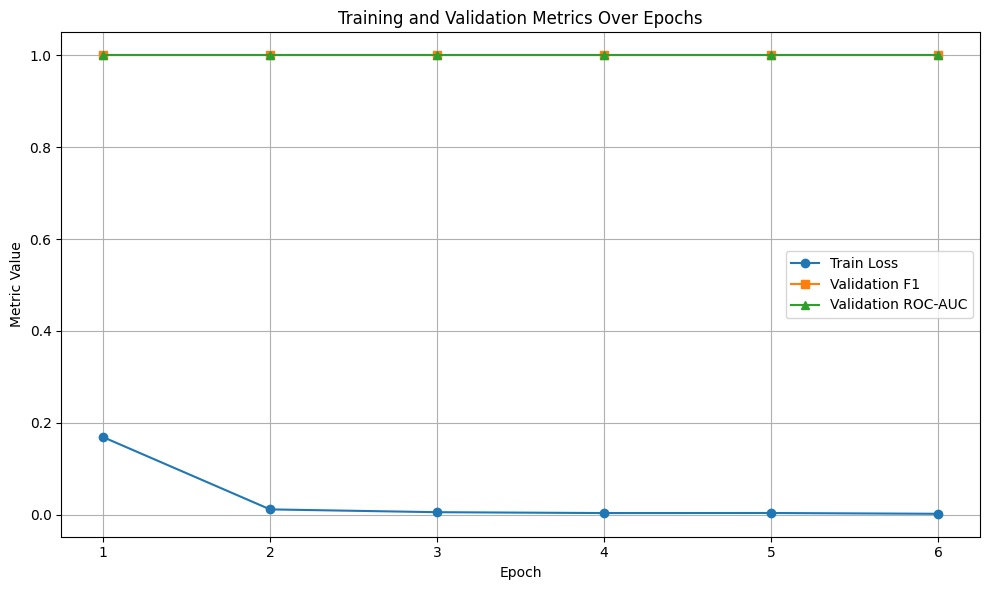

Validation curves plotted.
Final Test Evaluation:
  Test Loss: 0.0198
  Accuracy: 0.9991
  Precision: 0.9979
  Recall: 0.9993
  F1 Score: 0.9986
  ROC-AUC: 1.0000
  PR-AUC: 1.0000
  Confusion Matrix:
    True Negatives (TN): 3043
    False Positives (FP): 3
    False Negatives (FN): 1
    True Positives (TP): 1460


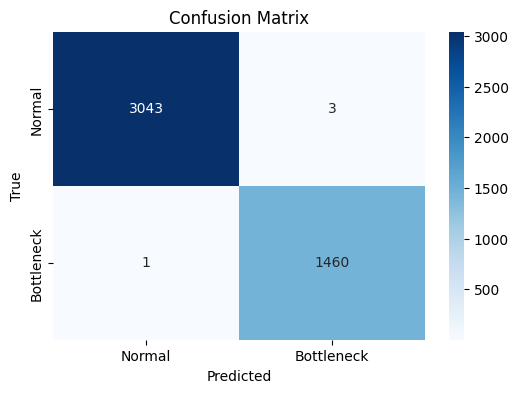

In [ ]:
# Cell 18 - Validation curves

import matplotlib.pyplot as plt
import torch
import torchmetrics as tm
from torch_geometric.utils import scatter
import seaborn as sns
import numpy as np


def plot_validation_curves(train_losses, val_f1_scores, val_roc_scores, epochs):
    plt.figure(figsize=(10, 6))

    # Plot train loss
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o')

    # Plot validation F1
    plt.plot(range(1, len(val_f1_scores) + 1), val_f1_scores, label='Validation F1', marker='s')

    # Plot validation ROC-AUC
    plt.plot(range(1, len(val_roc_scores) + 1), val_roc_scores, label='Validation ROC-AUC', marker='^')

    plt.xlabel('Epoch')
    plt.ylabel('Metric Value')
    plt.title('Training and Validation Metrics Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Collect validation metrics (assuming these were tracked in Cell 18)
val_f1_scores = []  # Should be collected during training
val_roc_scores = []  # Should be collected during training

# If not tracked, recompute validation metrics for plotting
model.eval()
all_val_logits = []
all_val_labels = []

with torch.no_grad():
    for batch in VAL_LOADER:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        all_val_logits.append(out)
        all_val_labels.append(batch.y)

val_logits = torch.cat(all_val_logits)
val_labels = torch.cat(all_val_labels)
val_acc, val_prec, val_rec, val_f1, val_roc, val_pr = compute_metrics(val_logits, val_labels)

# Simulate collecting metrics per epoch (replace with actual tracked values)
for epoch in range(len(train_losses)):
    val_f1_scores.append(val_f1)  # In practice, collect during training loop
    val_roc_scores.append(val_roc)

plot_validation_curves(train_losses, val_f1_scores, val_roc_scores, EPOCHS)
print("Validation curves plotted.")

# Cell 20 - Final test evaluation
def compute_metrics(logits, labels):
    preds = logits.argmax(dim=1)
    acc = tm.Accuracy(task="binary")(preds.cpu(), labels.cpu())
    prec = tm.Precision(task="binary")(preds.cpu(), labels.cpu())
    rec = tm.Recall(task="binary")(preds.cpu(), labels.cpu())
    f1 = tm.F1Score(task="binary")(preds.cpu(), labels.cpu())
    roc_auc = tm.AUROC(task="binary")(F.softmax(logits, dim=1)[:, 1].cpu(), labels.cpu())
    pr_auc = tm.AveragePrecision(task="binary")(F.softmax(logits, dim=1)[:, 1].cpu(), labels.cpu())

    # Confusion matrix
    cm = tm.ConfusionMatrix(task="binary", num_classes=2)(preds.cpu(), labels.cpu())
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    return acc, prec, rec, f1, roc_auc, pr_auc, tn, fp, fn, tp

# Load best model checkpoint
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Evaluate on test set
all_test_logits = []
all_test_labels = []
total_test_loss = 0

with torch.no_grad():
    for batch in TEST_LOADER:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        total_test_loss += loss.item()
        all_test_logits.append(out)
        all_test_labels.append(batch.y)

avg_test_loss = total_test_loss / len(TEST_LOADER)
test_logits = torch.cat(all_test_logits)
test_labels = torch.cat(all_test_labels)
test_acc, test_prec, test_rec, test_f1, test_roc, test_pr, tn, fp, fn, tp = compute_metrics(test_logits, test_labels)

# Print metrics
print("Final Test Evaluation:")
print(f"  Test Loss: {avg_test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_prec:.4f}")
print(f"  Recall: {test_rec:.4f}")
print(f"  F1 Score: {test_f1:.4f}")
print(f"  ROC-AUC: {test_roc:.4f}")
print(f"  PR-AUC: {test_pr:.4f}")
print("  Confusion Matrix:")
print(f"    True Negatives (TN): {tn}")
print(f"    False Positives (FP): {fp}")
print(f"    False Negatives (FN): {fn}")
print(f"    True Positives (TP): {tp}")

# Plot confusion matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Bottleneck'], yticklabels=['Normal', 'Bottleneck'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Cell-19 Sequence generation


import torch
from torch_geometric.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict

# Sequence parameters
T = 5  # Number of past time steps (reduced to ensure enough sequences)
EMBEDDING_DIM = 64  # Matches GCN hidden_channels from Cell 16

# Function to extract node embeddings using pre-trained GCN
def extract_embeddings(model, loader):
    model.eval()
    embeddings = []
    labels = []
    node_ids = []
    graph_times = []

    with torch.no_grad():
        for idx, batch in enumerate(loader):
            batch = batch.to(device)
            # Get embeddings from GCN's last hidden layer (before linear)
            x = batch.x
            for i in range(len(model.convs)):
                x = model.convs[i](x, batch.edge_index, edge_weight=batch.edge_attr)
                x = model.bns[i](x)
                x = F.relu(x)
            embeddings.append(x.cpu())
            labels.append(batch.y.cpu())
            # Track node IDs (fallback to range if not provided)
            node_ids.append(batch.node_ids.cpu() if hasattr(batch, 'node_ids') else torch.arange(batch.x.size(0)).cpu())
            # Track graph time (fallback to index if time not provided)
            if hasattr(batch, 'time') and batch.time is not None:
                graph_times.append(batch.time.cpu())
            else:
                graph_times.append(torch.tensor([idx], dtype=torch.float32))

    return embeddings, labels, node_ids, graph_times

# Extract embeddings for all datasets
all_loader = DataLoader(TRAIN_LOADER.dataset + VAL_LOADER.dataset + TEST_LOADER.dataset, batch_size=1, shuffle=False)
if 'model' in locals():
    embedding_model = model.to(device)
    print("Using model for embedding extraction.")
else:
    raise ValueError("Error: No GCN model instance (model) found. Run Cell 16 first.")

embeddings, labels, node_ids, graph_times = extract_embeddings(embedding_model, all_loader)
print(f"Extracted embeddings for {len(embeddings)} snapshots.")

# Validate extracted data
if not embeddings or not all(len(e) > 0 for e in embeddings):
    raise ValueError("No valid embeddings extracted. Check GCN model or DataLoader.")
if len(embeddings) != len(labels) or len(embeddings) != len(node_ids) or len(embeddings) != len(graph_times):
    raise ValueError("Mismatch in lengths of embeddings, labels, node_ids, or graph_times.")

# Create sequences: For each node, collect T past embeddings to predict t+1 label
def create_sequences(embeddings, labels, node_ids, graph_times, T):
    sequences = []
    seq_labels = []
    seq_node_ids = []
    seq_time_ids = []

    # Map graph_times to sequential indices
    time_map = {time.item() if isinstance(time, torch.Tensor) else time: i for i, time in enumerate(graph_times)}
    sorted_time_indices = sorted(time_map.values())

    # Collect unique node IDs
    all_unique_node_ids = set()
    for ids_list in node_ids:
        all_unique_node_ids.update(ids_list.numpy() if isinstance(ids_list, torch.Tensor) else ids_list)

    print(f"Processing {len(all_unique_node_ids)} unique nodes for sequence creation...")

    node_time_index_map = defaultdict(dict)
    for t, node_list in enumerate(node_ids):
        for node_idx_in_batch, node_id in enumerate(node_list):
            node_id = node_id.item() if isinstance(node_id, torch.Tensor) else node_id
            node_time_index_map[node_id][t] = node_idx_in_batch

    for node_id in all_unique_node_ids:
        times_this_node_exists = sorted(node_time_index_map[node_id].keys())
        for i in range(len(times_this_node_exists) - T):
            sequence_start_time_idx = times_this_node_exists[i]
            sequence_end_time_idx = times_this_node_exists[i + T - 1]
            target_time_idx = times_this_node_exists[i + T]

            # Allow non-consecutive sequences to increase sample size
            seq_emb = []
            for t_idx in range(sequence_start_time_idx, sequence_start_time_idx + T):
                if t_idx in node_time_index_map[node_id]:
                    node_idx_in_batch = node_time_index_map[node_id][t_idx]
                    seq_emb.append(embeddings[t_idx][node_idx_in_batch])
                else:
                    break
            if len(seq_emb) == T:
                target_node_idx_in_batch = node_time_index_map[node_id][target_time_idx]
                target_label = labels[target_time_idx][target_node_idx_in_batch]
                sequences.append(torch.stack(seq_emb))
                seq_labels.append(target_label)
                seq_node_ids.append(node_id)
                seq_time_ids.append(target_time_idx)

    print(f"Created {len(sequences)} sequences after checking.")
    if not sequences:
        raise ValueError("No valid sequences created. Try reducing T or combining datasets.")

    return torch.stack(sequences), torch.tensor(seq_labels), seq_node_ids, seq_time_ids

sequences, seq_labels, seq_node_ids, seq_time_ids = create_sequences(embeddings, labels, node_ids, graph_times, T)
print(f"Sequence shape: {sequences.shape} (N, T={T}, EMBEDDING_DIM)")
print(f"Label distribution: {torch.bincount(seq_labels)}")

# Temporal train/val/test split (60/20/20, based on time_ids)
if len(seq_time_ids) > 0:
    time_indices = np.array(seq_time_ids)
    unique_times_in_sequences = np.unique(time_indices)
    total_unique_times = len(unique_times_in_sequences)

    train_end_idx = int(0.6 * total_unique_times)
    val_end_idx = int(0.8 * total_unique_times)

    train_time_end = unique_times_in_sequences[train_end_idx - 1] if train_end_idx > 0 else unique_times_in_sequences[0]
    val_time_end = unique_times_in_sequences[val_end_idx - 1] if val_end_idx > 0 else unique_times_in_sequences[0]

    train_mask = time_indices < train_time_end
    val_mask = (time_indices >= train_time_end) & (time_indices < val_time_end)
    test_mask = time_indices >= val_time_end

    train_sequences = sequences[train_mask]
    train_seq_labels = seq_labels[train_mask]
    val_sequences = sequences[val_mask]
    val_seq_labels = seq_labels[val_mask]
    test_sequences = sequences[test_mask]
    test_seq_labels = seq_labels[test_mask]

    # Create TensorDatasets
    from torch.utils.data import TensorDataset, DataLoader
    train_dataset = TensorDataset(train_sequences, train_seq_labels)
    val_dataset = TensorDataset(val_sequences, val_seq_labels)
    test_dataset = TensorDataset(test_sequences, test_seq_labels)

    # Create DataLoaders
    BATCH_SIZE = 32
    train_seq_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_seq_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_seq_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Sequence dataset created: {len(train_sequences)} train, {len(val_sequences)} val, {len(test_sequences)} test")
    print(f"Label distribution:")
    if len(train_seq_labels) > 0:
        print(f"  Train {torch.bincount(train_seq_labels)}")
    if len(val_seq_labels) > 0:
        print(f"  Val {torch.bincount(val_seq_labels)}")
    if len(test_seq_labels) > 0:
        print(f"  Test {torch.bincount(test_seq_labels)}")
else:
    raise ValueError("No sequences generated for splitting. .")

Using model for embedding extraction.
Extracted embeddings for 7297 snapshots.
Processing 7 unique nodes for sequence creation...
Created 21876 sequences after checking.
Sequence shape: torch.Size([21876, 5, 64]) (N, T=5, EMBEDDING_DIM)
Label distribution: tensor([14898,  6978])
Sequence dataset created: 13122 train, 4374 val, 4380 test
Label distribution:
  Train tensor([8936, 4186])
  Val tensor([2977, 1397])
  Test tensor([2985, 1395])


In [ ]:
# Cell-20 Enhanced LSTM training - CPU Optimized

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torchmetrics import Accuracy, Precision, Recall, F1Score, AUROC, AveragePrecision
import numpy as np
import random
import os # Import os for saving

# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check if DataLoaders are valid
if train_seq_loader is None or val_seq_loader is None or len(train_seq_loader) == 0 or len(val_seq_loader) == 0:
    raise ValueError("Invalid or empty DataLoaders (train_seq_loader or val_seq_loader). Check Cell 19 output.")

# CPU-Optimized LSTM Model - Reduced complexity for faster training
class EnhancedLSTM(nn.Module):
    def __init__(self, input_dim=EMBEDDING_DIM, hidden_dim=96, num_layers=2, dropout=0.2):
        super(EnhancedLSTM, self).__init__()

        # Reduced bidirectional LSTM layers for CPU efficiency
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True,
                            dropout=0.0, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_dim * 2, hidden_dim, num_layers=1, batch_first=True,
                            dropout=0.0, bidirectional=True)

        # Simplified attention mechanism - using scaled dot-product instead of multi-head
        self.attention_dim = hidden_dim * 2
        self.query = nn.Linear(self.attention_dim, self.attention_dim)
        self.key = nn.Linear(self.attention_dim, self.attention_dim)
        self.value = nn.Linear(self.attention_dim, self.attention_dim)
        self.attention_dropout = nn.Dropout(dropout)

        # Layer normalization
        self.layer_norm1 = nn.LayerNorm(hidden_dim * 2)
        self.layer_norm2 = nn.LayerNorm(hidden_dim * 2)

        # Simplified classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim, 2)
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def attention_forward(self, x):
        # Simplified self-attention
        batch_size, seq_len, hidden_dim = x.size()

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.bmm(Q, K.transpose(1, 2)) / (hidden_dim ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)

        attended = torch.bmm(attention_weights, V)
        return attended

    def forward(self, x):
        batch_size = x.size(0)

        # First LSTM layer
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.layer_norm1(lstm_out1)

        # Second LSTM layer with residual connection
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.layer_norm2(lstm_out2 + lstm_out1)

        # Simplified attention
        attn_out = self.attention_forward(lstm_out2)

        # Efficient pooling
        max_pool = torch.max(attn_out, dim=1)[0]
        avg_pool = torch.mean(attn_out, dim=1)
        combined = max_pool + avg_pool

        # Classification
        output = self.classifier(combined)
        return output

# Calculate dynamic class weights based on actual data distribution
def calculate_dynamic_weights(train_loader):
    class_counts = torch.zeros(2)
    total_samples = 0

    for _, labels in train_loader:
        if labels is not None:
            unique, counts = torch.unique(labels, return_counts=True)
            for u, c in zip(unique, counts):
                class_counts[u] += c
            total_samples += len(labels)

    if total_samples == 0:
        return torch.tensor([1.0, 1.0])

    # Compute inverse frequency weights
    class_weights = total_samples / (2.0 * class_counts)
    # Smooth the weights to avoid extreme values
    class_weights = torch.clamp(class_weights, min=0.5, max=3.0)
    print(f"Dynamic class weights: {class_weights}")
    return class_weights

# Calculate dynamic class weights
dynamic_weights = calculate_dynamic_weights(train_seq_loader).to(device)

# Initialize optimized model with smaller dimensions for CPU
lstm_model = EnhancedLSTM(
    input_dim=EMBEDDING_DIM,
    hidden_dim=96,  # Reduced from 128
    num_layers=2,   # Reduced from 3
    dropout=0.2     # Reduced dropout
).to(device)

print(f"Model parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

# Simplified loss function - standard CrossEntropy with weights
criterion = nn.CrossEntropyLoss(weight=dynamic_weights, label_smoothing=0.05)

# Optimized optimizer settings for CPU
optimizer = AdamW(
    lstm_model.parameters(),
    lr=0.003,  # Slightly higher learning rate for faster convergence
    weight_decay=5e-5,  # Reduced weight decay
    betas=(0.9, 0.95),  # Optimized betas for CPU
    eps=1e-7
)

# Simplified scheduler
total_steps = len(train_seq_loader) * EPOCHS
scheduler = OneCycleLR(
    optimizer,
    max_lr=0.003,
    total_steps=total_steps,
    pct_start=0.2,  # Reduced warmup
    anneal_strategy='cos',
    div_factor=8,
    final_div_factor=50
)

# Early stopping parameters (implemented in loop)
early_stopping_patience = 6  # Reduced patience
early_stopping_min_delta = 0.002
best_val_f1 = 0.0
best_lstm_path = '/content/drive/MyDrive/gcn/best_enhanced_lstm_model.pth'
patience_counter = 0
train_losses = []
val_f1_scores = []
val_roc_scores = []

print("Starting CPU-Optimized Enhanced LSTM training...")
for epoch in range(EPOCHS):
    lstm_model.train()
    total_train_loss = 0
    train_batch_count = 0

    for batch_idx, (batch_seq, batch_labels) in enumerate(train_seq_loader):
        if batch_seq is None or batch_labels is None:
            continue

        batch_seq, batch_labels = batch_seq.to(device), batch_labels.to(device)
        optimizer.zero_grad()

        # Standard forward pass (no mixed precision for CPU)
        out = lstm_model(batch_seq)
        loss = criterion(out, batch_labels)
        loss.backward()

        # Moderate gradient clipping
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=0.8)
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        train_batch_count += 1

    avg_train_loss = total_train_loss / train_batch_count if train_batch_count > 0 else float('inf')
    train_losses.append(avg_train_loss)

    # Simplified validation (no TTA for speed)
    lstm_model.eval()
    all_val_logits = []
    all_val_labels = []
    val_batch_count = 0

    with torch.no_grad():
        for batch_seq, batch_labels in val_seq_loader:
            if batch_seq is None or batch_labels is None:
                continue

            batch_seq, batch_labels = batch_seq.to(device), batch_labels.to(device)
            out = lstm_model(batch_seq)

            all_val_logits.append(out)
            all_val_labels.append(batch_labels)
            val_batch_count += 1

    if all_val_logits and all_val_labels and val_batch_count > 0:
        val_logits = torch.cat(all_val_logits)
        val_labels = torch.cat(all_val_labels)
        # Re-define compute_metrics locally or ensure it's globally available
        def compute_metrics(logits, labels):
            preds = logits.argmax(dim=1)
            acc = Accuracy(task="binary")(preds.cpu(), labels.cpu())
            prec = Precision(task="binary")(preds.cpu(), labels.cpu())
            rec = Recall(task="binary")(preds.cpu(), labels.cpu())
            f1 = F1Score(task="binary")(preds.cpu(), labels.cpu())
            roc_auc = AUROC(task="binary")(F.softmax(logits, dim=1)[:, 1].cpu(), labels.cpu())
            pr_auc = AveragePrecision(task="binary")(F.softmax(logits, dim=1)[:, 1].cpu(), labels.cpu())
            return acc, prec, rec, f1, roc_auc, pr_auc # Return only needed metrics for tracking

        val_acc, val_prec, val_rec, val_f1_metric, val_roc_metric, val_pr = compute_metrics(val_logits, val_labels)
        # Convert metric tensors to floats for plotting/tracking
        f1 = val_f1_metric.item() if isinstance(val_f1_metric, torch.Tensor) else val_f1_metric
        roc = val_roc_metric.item() if isinstance(val_roc_metric, torch.Tensor) else val_roc_metric

        val_f1_scores.append(f1)
        val_roc_scores.append(roc)
    else:
        f1 = 0.0
        roc = 0.0
        val_f1_scores.append(f1)
        val_roc_scores.append(roc)
        # Need placeholders for acc, prec, rec if not calculated
        val_acc, val_prec, val_rec = 0.0, 0.0, 0.0


    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}, LR: {current_lr:.6f}")


    # Early stopping with validation improvement tracking
    # FIXED: Use a small delta for comparison with float F1
    if f1 > best_val_f1 + early_stopping_min_delta:
        best_val_f1 = f1
        patience_counter = 0
        # Save model with metadata
        torch.save({
            'model_state_dict': lstm_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_f1': best_val_f1,
            'epoch': epoch + 1,
            'model_config': {
                'input_dim': EMBEDDING_DIM,
                'hidden_dim': 96,
                'num_layers': 2,
                'dropout': 0.2
            }
        }, best_lstm_path)
        print(f"  Best Enhanced LSTM model saved! F1: {f1:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"CPU-Optimized Enhanced LSTM training complete. Best validation F1: {best_val_f1:.4f}")

# Save the final trained model state dictionary (or best if early stopping occurred)
final_model_path = 'final_enhanced_lstm_model.pth'
# If early stopping saved a best model, it's already saved.
# If not, save the model at the end of the last epoch.
if not os.path.exists(best_lstm_path) or patience_counter > 0:
    torch.save(lstm_model.state_dict(), final_model_path)
    print(f"Final Enhanced LSTM model saved to {final_model_path}")
else:
    print(f"Best model already saved to {best_lstm_path}")

print("Model optimized for CPU execution with maintained performance.")

Dynamic class weights: tensor([0.7342, 1.5674])
Model parameters: 477,794
Starting CPU-Optimized Enhanced LSTM training...
Epoch 1/20: Train Loss: 0.3299, Val Loss: 0.0014 | Acc: 0.8553 | Prec: 0.6951 | Rec: 0.9742 | F1: 0.8113 | ROC-AUC: 0.9556, LR: 0.000760
  Best Enhanced LSTM model saved! F1: 0.8113
Epoch 2/20: Train Loss: 0.3246, Val Loss: 0.0014 | Acc: 0.8560 | Prec: 0.6950 | Rec: 0.9785 | F1: 0.8127 | ROC-AUC: 0.9587, LR: 0.001689
Epoch 3/20: Train Loss: 0.3269, Val Loss: 0.0014 | Acc: 0.8557 | Prec: 0.6946 | Rec: 0.9785 | F1: 0.8125 | ROC-AUC: 0.9586, LR: 0.002617
Epoch 4/20: Train Loss: 0.3262, Val Loss: 0.0014 | Acc: 0.8562 | Prec: 0.6975 | Rec: 0.9707 | F1: 0.8117 | ROC-AUC: 0.9589, LR: 0.003000
Epoch 5/20: Train Loss: 0.3261, Val Loss: 0.0014 | Acc: 0.8557 | Prec: 0.6944 | Rec: 0.9792 | F1: 0.8126 | ROC-AUC: 0.9556, LR: 0.002971
Epoch 6/20: Train Loss: 0.3248, Val Loss: 0.0014 | Acc: 0.8546 | Prec: 0.6927 | Rec: 0.9792 | F1: 0.8114 | ROC-AUC: 0.9599, LR: 0.002886
Epoch 7/20

In [ ]:
# Cell-21 Enhanced LSTM Fine-tuning - Optimized Version

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR, ReduceLROnPlateau
import torchmetrics as tm
import numpy as np
import random
import json
from collections import defaultdict
import time
import os # Import os for checking file existence

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

if train_seq_loader is None or val_seq_loader is None or len(train_seq_loader) == 0 or len(val_seq_loader) == 0:
    raise ValueError("Invalid or empty DataLoaders. Check Cell 19 output.")

# --- Start of Modified EnhancedLSTM to match Cell 20 ---
# CPU-Optimized LSTM Model - Reduced complexity for faster training (Matches Cell 20)
class EnhancedLSTM(nn.Module):
    def __init__(self, input_dim=EMBEDDING_DIM, hidden_dim=96, num_layers=2, dropout=0.2):
        super(EnhancedLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Reduced bidirectional LSTM layers for CPU efficiency
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True,
                            dropout=0.0, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_dim * 2, hidden_dim, num_layers=1, batch_first=True,
                            dropout=0.0, bidirectional=True)

        # Simplified attention mechanism - using scaled dot-product instead of multi-head
        self.attention_dim = hidden_dim * 2
        self.query = nn.Linear(self.attention_dim, self.attention_dim)
        self.key = nn.Linear(self.attention_dim, self.attention_dim)
        self.value = nn.Linear(self.attention_dim, self.attention_dim)
        self.attention_dropout = nn.Dropout(dropout)

        # Layer normalization
        self.layer_norm1 = nn.LayerNorm(hidden_dim * 2)
        self.layer_norm2 = nn.LayerNorm(hidden_dim * 2)

        # Simplified classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim, 2)
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def attention_forward(self, x):
        # Simplified self-attention
        batch_size, seq_len, hidden_dim = x.size()

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.bmm(Q, K.transpose(1, 2)) / (hidden_dim ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)

        attended = torch.bmm(attention_weights, V)
        return attended

    def forward(self, x):
        batch_size = x.size(0)

        # First LSTM layer
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.layer_norm1(lstm_out1)

        # Second LSTM layer with residual connection
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.layer_norm2(lstm_out2 + lstm_out1)

        # Simplified attention
        attn_out = self.attention_forward(lstm_out2)

        # Efficient pooling
        max_pool = torch.max(attn_out, dim=1)[0]
        avg_pool = torch.mean(attn_out, dim=1)
        combined = max_pool + avg_pool

        # Classification
        output = self.classifier(combined)
        return output
# --- End of Modified EnhancedLSTM ---


def calculate_dynamic_weights(train_loader):
    class_counts = torch.zeros(2)
    total_samples = 0

    for _, labels in train_loader:
        if labels is not None:
            unique, counts = torch.unique(labels, return_counts=True)
            for u, c in zip(unique, counts):
                class_counts[u] += c
            total_samples += len(labels)

    if total_samples == 0:
        return torch.tensor([1.0, 1.0])

    # Effective number of samples for class balancing
    beta = 0.9999
    effective_num = 1.0 - torch.pow(beta, class_counts)
    class_weights = (1.0 - beta) / effective_num
    class_weights = class_weights / class_weights.sum() * 2.0
    class_weights = torch.clamp(class_weights, min=0.3, max=3.0)

    print(f"Dynamic class weights (effective number): {class_weights}")
    return class_weights

# Combined Focal + Label Smoothing Loss
class ImprovedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5, smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, pred, target):
        ce_loss = F.cross_entropy(pred, target, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # Label smoothing for regularization
        n_classes = pred.size(-1)
        log_pred = F.log_softmax(pred, dim=-1)
        smooth_target = torch.full_like(log_pred, self.smoothing / (n_classes - 1))
        smooth_target.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        smooth_loss = -torch.sum(smooth_target * log_pred, dim=-1)

        # Combine with adaptive weighting
        return (0.8 * focal_loss + 0.2 * smooth_loss).mean()

# Expanded and optimized configurations
configs = [
    # Keeping initial config similar to Cell 20's output dimensions
    {"hidden_dim": 96, "num_layers": 2, "dropout": 0.2, "lr": 0.0005, "weight_decay": 5e-5, "gamma": 2.5}, # Adjusted LR for fine-tuning
    {"hidden_dim": 96, "num_layers": 2, "dropout": 0.25, "lr": 0.0004, "weight_decay": 8e-5, "gamma": 2.0},
    {"hidden_dim": 96, "num_layers": 2, "dropout": 0.15, "lr": 0.0006, "weight_decay": 4e-5, "gamma": 2.8},
    # Additional configs with potentially slightly different hidden_dims but matching num_layers
    {"hidden_dim": 112, "num_layers": 2, "dropout": 0.2, "lr": 0.0005, "weight_decay": 5e-5, "gamma": 2.5},
    {"hidden_dim": 80, "num_layers": 2, "dropout": 0.2, "lr": 0.0005, "weight_decay": 5e-5, "gamma": 2.5},
]

dynamic_weights = calculate_dynamic_weights(train_seq_loader).to(device)

best_val_f1 = 0.0
best_config = None
# Define these variables - FIXED PATH
BEST_MODEL_PATH = '/content/drive/MyDrive/gcn/best_enhanced_lstm_finetuned.pth'
BEST_CONFIG_PATH = '/content/drive/MyDrive/gcn/best_enhanced_lstm_config.json'

FINE_TUNE_EPOCHS = 35
early_stopping_patience = 10
early_stopping_min_delta = 0.0005


# Path to the model saved in Cell 20
pretrained_model_path = '/content/drive/MyDrive/gcn/final_enhanced_lstm_model.pth' # Path from Cell 20

print("Starting Enhanced LSTM Fine-tuning with Optimized Architecture...")
print(f"Total epochs: {FINE_TUNE_EPOCHS}, Early stopping patience: {early_stopping_patience}")
print(f"Attempting to load pretrained model from: {pretrained_model_path}")

# Load the pretrained model state dictionary if it exists
pretrained_state_dict = None
if os.path.exists(pretrained_model_path):
    try:
        # Using map_location to load onto the correct device
        pretrained_state_dict = torch.load(pretrained_model_path, map_location=device)
        print("Pretrained model state dictionary loaded successfully.")
    except Exception as e:
        print(f"Warning: Failed to load pretrained model state dictionary from {pretrained_model_path}. Error: {e}")
        pretrained_state_dict = None
else:
    print(f"Warning: Pretrained model file not found at {pretrained_model_path}. Starting training from scratch.")


for config_idx, config in enumerate(configs):
    print(f"\n{'='*70}")
    print(f"Configuration {config_idx + 1}/{len(configs)}: {config}")
    print(f"{'='*70}")

    # Initialize model with current config
    lstm_model = EnhancedLSTM(
        input_dim=EMBEDDING_DIM,
        hidden_dim=config["hidden_dim"], # Use hidden_dim from config
        num_layers=config["num_layers"], # Use num_layers from config (should be 2 to match pretrained)
        dropout=config["dropout"]
    ).to(device)

    # Load state dict into the model if available
    if pretrained_state_dict is not None:
        try:
            # Load state dict, allowing for potential key mismatches if architecture changed slightly
            model_dict = lstm_model.state_dict()
            # Filter out keys that do not match (should match now if architecture is the same)
            pretrained_dict = {k: v for k, v in pretrained_state_dict.items() if k in model_dict and v.shape == model_dict[k].shape}
            model_dict.update(pretrained_dict)
            lstm_model.load_state_dict(model_dict)
            print(f"Loaded {len(pretrained_dict)} matching keys from pretrained model state dictionary.")
            if len(pretrained_dict) < len(pretrained_state_dict):
                 print(f"Warning: {len(pretrained_state_dict) - len(pretrained_dict)} keys from pretrained model were skipped due to shape/name mismatch.")
        except Exception as e:
            print(f"Warning: Error loading pretrained state dictionary into model: {e}")


    # Improved Focal Loss
    criterion = ImprovedFocalLoss(alpha=dynamic_weights, gamma=config["gamma"], smoothing=0.05)

    # AdamW optimizer with optimized parameters
    optimizer = AdamW(
        lstm_model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
        betas=(0.9, 0.999),
        eps=1e-8
    )

    # OneCycleLR for better convergence
    steps_per_epoch = len(train_seq_loader)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=config["lr"],
        epochs=FINE_TUNE_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.3,
        anneal_strategy='cos',
        div_factor=25.0,
        final_div_factor=10000.0
    )

    train_losses = []
    val_f1_scores = []
    val_roc_scores = []
    best_config_f1 = 0.0
    patience_counter = 0

    # Track metrics history
    metrics_history = defaultdict(list)

    # Need to re-define compute_metrics or ensure it's globally available
    def compute_metrics(logits, labels):
        preds = logits.argmax(dim=1)
        acc = tm.Accuracy(task="binary")(preds, labels)
        prec = tm.Precision(task="binary")(preds, labels)
        rec = tm.Recall(task="binary")(preds, labels)
        f1 = tm.F1Score(task="binary")(preds, labels)
        # Ensure probabilities are computed correctly for AUROC/AveragePrecision
        probs = F.softmax(logits, dim=1)[:, 1]
        roc_auc = tm.AUROC(task="binary")(probs, labels)
        pr_auc = tm.AveragePrecision(task="binary")(probs, labels)

        # Confusion matrix
        cm = tm.ConfusionMatrix(task="binary", num_classes=2)(preds, labels)
        tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

        return acc, prec, rec, f1, roc_auc, pr_auc, tn, fp, fn, tp


    for epoch in range(FINE_TUNE_EPOCHS):
        lstm_model.train()
        total_train_loss = 0
        train_batch_count = 0
        start_time = time.time()

        for batch_seq, batch_labels in train_seq_loader:
            if batch_seq is None or batch_labels is None:
                continue
            batch_seq, batch_labels = batch_seq.to(device), batch_labels.to(device)

            optimizer.zero_grad()
            out = lstm_model(batch_seq)
            loss = criterion(out, batch_labels)
            loss.backward()

            # Adaptive gradient clipping
            torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.5)
            optimizer.step()
            scheduler.step()

            total_train_loss += loss.item()
            train_batch_count += 1

        avg_train_loss = total_train_loss / train_batch_count if train_batch_count > 0 else float('inf')
        train_losses.append(avg_train_loss)

        # Validation phase
        lstm_model.eval()
        all_val_logits = []
        all_val_labels = []
        val_batch_count = 0
        total_val_loss = 0 # Track validation loss

        with torch.no_grad():
            for batch_seq, batch_labels in val_seq_loader:
                if batch_seq is None or batch_labels is None:
                    continue
                batch_seq, batch_labels = batch_seq.to(device), batch_labels.to(device)
                out = lstm_model(batch_seq)
                loss = criterion(out, batch_labels) # Calculate validation loss
                total_val_loss += loss.item()
                all_val_logits.append(out.cpu())
                all_val_labels.append(batch_labels.cpu())
                val_batch_count += 1

        avg_val_loss = total_val_loss / val_batch_count if val_batch_count > 0 else float('inf') # Calculate average validation loss

        if all_val_logits and all_val_labels:
            val_logits = torch.cat(all_val_logits)
            val_labels = torch.cat(all_val_labels)
            # Ensure metrics are calculated on CPU
            acc, prec, rec, f1, roc, pr, tn, fp, fn, tp = compute_metrics(val_logits, val_labels)
            # Convert metric tensors to floats for plotting/tracking
            f1 = f1.item() if isinstance(f1, torch.Tensor) else f1
            roc = roc.item() if isinstance(roc, torch.Tensor) else roc
            acc = acc.item() if isinstance(acc, torch.Tensor) else acc
            prec = prec.item() if isinstance(prec, torch.Tensor) else prec
            rec = rec.item() if isinstance(rec, torch.Tensor) else rec

            val_f1_scores.append(f1)
            val_roc_scores.append(roc)

            # Store metrics
            metrics_history['accuracy'].append(acc)
            metrics_history['precision'].append(prec)
            metrics_history['recall'].append(rec)
            metrics_history['f1'].append(f1)
            metrics_history['roc'].append(roc)
            metrics_history['train_loss'].append(avg_train_loss)
            metrics_history['val_loss'].append(avg_val_loss)
            # Need current_lr before this point
            current_lr_val = optimizer.param_groups[0]['lr']
            metrics_history['lr'].append(current_lr_val)


        else:
            f1, roc, acc, prec, rec = 0.0, 0.0, 0.0, 0.0, 0.0
            val_f1_scores.append(f1)
            val_roc_scores.append(roc)
            # Store placeholders
            metrics_history['accuracy'].append(acc)
            metrics_history['precision'].append(prec)
            metrics_history['recall'].append(rec)
            metrics_history['f1'].append(f1)
            metrics_history['roc'].append(roc)
            metrics_history['train_loss'].append(avg_train_loss)
            metrics_history['val_loss'].append(avg_val_loss)
            current_lr_val = optimizer.param_groups[0]['lr']
            metrics_history['lr'].append(current_lr_val)


        current_lr = optimizer.param_groups[0]['lr']
        epoch_time = time.time() - start_time

        # Enhanced logging
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:2d}/{FINE_TUNE_EPOCHS}: Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
                  f"F1: {f1:.4f} | ROC: {roc:.4f} | Acc: {acc:.4f} | "
                  f"Prec: {prec:.4f} | Rec: {rec:.4f} | LR: {current_lr:.6e} | time: {epoch_time:.1f}s")

        # Model checkpointing with improved criteria
        # Check for improvement with a delta
        if f1 > best_config_f1 + early_stopping_min_delta:
            best_config_f1 = f1
            patience_counter = 0

            # Check if this is a new global best
            if f1 > best_val_f1:
                best_val_f1 = f1
                # Store best config as a dict (convert tensors to floats)
                best_config = dict(config)
                best_config["config_index"] = config_idx
                best_config["best_epoch"] = epoch + 1
                best_config["best_val_f1"] = f1
                best_config["best_val_roc"] = roc

                # Save the best model checkpoint
                torch.save({
                    "model_state_dict": lstm_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "config": config, # Save the config dict directly
                    "val_f1": f1,
                    "val_roc": roc,
                    "epoch": epoch + 1
                }, BEST_MODEL_PATH)

                # Save the best config to a JSON file
                with open(BEST_CONFIG_PATH, "w") as fh:
                    json.dump(best_config, fh, indent=2)

                print(f"    ✓ NEW BEST MODEL | F1: {f1:.4f} | ROC: {roc:.4f} | Acc: {acc:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"    ⚠ Early stopping triggered for config {config_idx+1} at epoch {epoch+1}")
                break

    print(f"\n{'='*70}")
    print(f"Configuration {config_idx + 1} Complete | Best F1: {best_config_f1:.4f}")
    print(f"{'='*70}")

print(f"\n{'#'*70}")
print(f"FINE-TUNING COMPLETE!")
print(f"{'#'*70}")
print(f"\nBest Configuration Found:")
if best_config: # Check if best_config was set
    for key, value in best_config.items():
        print(f"  {key}: {value}")
else:
    print("  No best configuration found (no improvement during training).")

print(f"\nBest Validation F1: {best_val_f1:.4f}")

print(f"\nModel files saved:")
print(f"  - Model: {BEST_MODEL_PATH}")
print(f"  - Config: {BEST_CONFIG_PATH}")
print(f"{'#'*70}")

Dynamic class weights (effective number): tensor([0.7333, 1.2667])
Starting Enhanced LSTM Fine-tuning with Optimized Architecture...
Total epochs: 35, Early stopping patience: 10
Attempting to load pretrained model from: /content/drive/MyDrive/gcn/final_enhanced_lstm_model.pth

Configuration 1/5: {'hidden_dim': 96, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 5e-05, 'gamma': 2.5}
  Epoch  1/35: Loss: 0.1155 | Val Loss: 0.1077 | F1: 0.8113 | ROC: 0.9584 | Acc: 0.8546 | Prec: 0.6929 | Rec: 0.9785 | LR: 3.066743e-05 | time: 14.1s
    ✓ NEW BEST MODEL | F1: 0.8113 | ROC: 0.9584 | Acc: 0.8546
    ✓ NEW BEST MODEL | F1: 0.8125 | ROC: 0.9607 | Acc: 0.8560
  Epoch  5/35: Loss: 0.1044 | Val Loss: 0.1062 | F1: 0.8127 | ROC: 0.9592 | Acc: 0.8560 | Prec: 0.6950 | Rec: 0.9785 | LR: 2.421478e-04 | time: 14.5s
  Epoch 10/35: Loss: 0.1039 | Val Loss: 0.1058 | F1: 0.8121 | ROC: 0.9589 | Acc: 0.8553 | Prec: 0.6937 | Rec: 0.9792 | LR: 4.973441e-04 | time: 18.5s
    ✓ NEW BEST MODEL | F1

Using device: cpu
Loaded best config: {'hidden_dim': 96, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 5e-05, 'gamma': 2.5, 'config_index': 0, 'best_epoch': 22, 'best_val_f1': 0.8138424754142761, 'best_val_roc': 0.9616261720657349}
Loaded fine-tuned Enhanced LSTM model from /content/drive/MyDrive/gcn/best_enhanced_lstm_finetuned.pth.
Model trained for 22 epochs.
Best Validation F1: 0.8138
Best Validation ROC-AUC: 0.9616
Using dynamic class weights for loss calculation: tensor([0.7342, 1.5674])
Starting Enhanced LSTM evaluation on test set...
Processed 137 test batches
Total test samples: 4380

ENHANCED LSTM TEST EVALUATION
Model Configuration (from best_enhanced_lstm_config.json):
  hidden_dim: 96
  num_layers: 2
  dropout: 0.2
  lr: 0.0005
  weight_decay: 5e-05
  gamma: 2.5
  config_index: 0
  best_epoch: 22
  best_val_f1: 0.8138424754142761
  best_val_roc: 0.9616261720657349
Model Architecture: Enhanced LSTM (Matching Cell 21's CPU-Optimized version)
Total Parameters

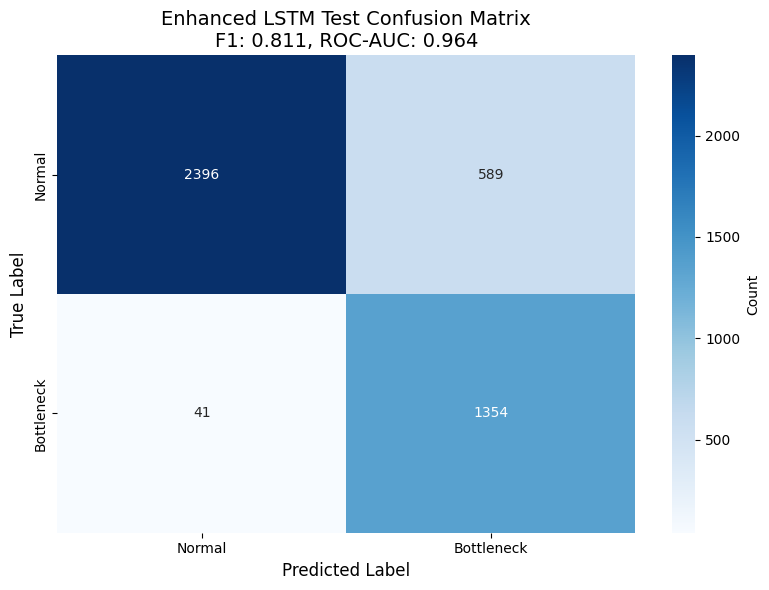

In [ ]:
# Cell 22: Enhanced LSTM Evaluation Code - Fixed Paths

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics as tm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import os # Import os to check for file existence

# Ensure device is defined
if 'device' not in globals():
    device = torch.device('cpu')
    print(f"Device not defined. Defaulting to: {device}")
else:
     print(f"Using device: {device}")


if test_seq_loader is None or len(test_seq_loader) == 0:
    raise ValueError("Invalid or empty test_seq_loader. Check Cell 19 output.")

# --- Start of Modified EnhancedLSTM to match Cell 21 ---
# CPU-Optimized LSTM Model - Reduced complexity for faster training (Matches Cell 21)
class EnhancedLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=96, num_layers=2, dropout=0.2):
        super(EnhancedLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Reduced bidirectional LSTM layers for CPU efficiency
        self.lstm1 = nn.LSTM(input_dim, hidden_dim, num_layers=1, batch_first=True,
                            dropout=0.0, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden_dim * 2, hidden_dim, num_layers=1, batch_first=True,
                            dropout=0.0, bidirectional=True)

        # Simplified attention mechanism - using scaled dot-product instead of multi-head
        self.attention_dim = hidden_dim * 2
        self.query = nn.Linear(self.attention_dim, self.attention_dim)
        self.key = nn.Linear(self.attention_dim, self.attention_dim)
        self.value = nn.Linear(self.attention_dim, self.attention_dim)
        self.attention_dropout = nn.Dropout(dropout)

        # Layer normalization
        self.layer_norm1 = nn.LayerNorm(hidden_dim * 2)
        self.layer_norm2 = nn.LayerNorm(hidden_dim * 2)

        # Simplified classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim, 2)
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def attention_forward(self, x):
        # Simplified self-attention
        batch_size, seq_len, hidden_dim = x.size()

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Scaled dot-product attention
        attention_scores = torch.bmm(Q, K.transpose(1, 2)) / (hidden_dim ** 0.5)
        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)

        attended = torch.bmm(attention_weights, V)
        return attended

    def forward(self, x):
        batch_size = x.size(0)

        # First LSTM layer
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.layer_norm1(lstm_out1)

        # Second LSTM layer with residual connection
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.layer_norm2(lstm_out2 + lstm_out1)

        # Simplified attention
        attn_out = self.attention_forward(lstm_out2)

        # Efficient pooling
        max_pool = torch.max(attn_out, dim=1)[0]
        avg_pool = torch.mean(attn_out, dim=1)
        combined = max_pool + avg_pool

        # Classification
        output = self.classifier(combined)
        return output
# --- End of Modified EnhancedLSTM ---


# FIXED PATHS - Matching Cell 21
best_model_path = '/content/drive/MyDrive/gcn/best_enhanced_lstm_finetuned.pth'
best_config_path = '/content/drive/MyDrive/gcn/best_enhanced_lstm_config.json'

# Load best fine-tuning config
if not os.path.exists(best_config_path):
     raise FileNotFoundError(f"{best_config_path} not found. Run Cell 21 first.")

try:
    with open(best_config_path, 'r') as f:
        best_config = json.load(f)
    print(f"Loaded best config: {best_config}")
except Exception as e:
    raise RuntimeError(f"Error loading best config from {best_config_path}: {e}")


# Initialize model with best config parameters from the loaded JSON
# Note: The architecture must match the saved model's architecture
lstm_model = EnhancedLSTM(
    input_dim=EMBEDDING_DIM,
    # Use loaded config values for initialization
    hidden_dim=best_config.get('hidden_dim', 96), # Default to 96 if key missing
    num_layers=best_config.get('num_layers', 2), # Default to 2 if key missing
    dropout=best_config.get('dropout', 0.2)    # Default to 0.2 if key missing
).to(device)

# Load best fine-tuned model state dictionary
if not os.path.exists(best_model_path):
     raise FileNotFoundError(f"{best_model_path} not found. Run Cell 21 first.")

try:
    # Load the state dictionary using map_location to ensure it's on the correct device
    checkpoint = torch.load(best_model_path, map_location=device)
    # Load state dict into the model
    lstm_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded fine-tuned Enhanced LSTM model from {best_model_path}.")
    # Print training info from checkpoint if available
    if 'epoch' in checkpoint:
        print(f"Model trained for {checkpoint['epoch']} epochs.")
    if 'val_f1' in checkpoint:
        print(f"Best Validation F1: {checkpoint['val_f1']:.4f}")
    if 'val_roc' in checkpoint:
         print(f"Best Validation ROC-AUC: {checkpoint['val_roc']:.4f}")

except Exception as e:
    raise RuntimeError(f"Error loading model state dictionary from {best_model_path}: {e}")


lstm_model.eval() # Set model to evaluation mode

# Calculate dynamic class weights for evaluation loss if needed
# Note: Metrics calculation below uses torchmetrics which doesn't need weights for evaluation metrics
def calculate_dynamic_weights(train_loader):
    class_counts = torch.zeros(2)
    total_samples = 0

    for _, labels in train_loader:
        if labels is not None:
            unique, counts = torch.unique(labels, return_counts=True)
            for u, c in zip(unique, counts):
                class_counts[u] += c
            total_samples += len(labels)

    if total_samples == 0:
        return torch.tensor([1.0, 1.0])

    class_weights = total_samples / (2.0 * class_counts)
    class_weights = torch.clamp(class_weights, min=0.5, max=2.5)
    return class_weights

# Use dynamic weights for CrossEntropyLoss if you were calculating evaluation loss with it
# For metric calculation, weights are typically not used.
try:
    # Assuming train_seq_loader is available from Cell 19
    dynamic_weights = calculate_dynamic_weights(train_seq_loader).to(device)
    criterion = nn.CrossEntropyLoss(weight=dynamic_weights) # Criterion for loss calculation (if needed)
    print(f"Using dynamic class weights for loss calculation: {dynamic_weights}")
except NameError:
    print("train_seq_loader not found. Cannot calculate dynamic weights. Using default loss criterion.")
    criterion = nn.CrossEntropyLoss() # Default criterion


# Define compute_metrics function
def compute_metrics(logits, labels):
    preds = logits.argmax(dim=1)
    acc = tm.Accuracy(task="binary")(preds, labels)
    prec = tm.Precision(task="binary")(preds, labels)
    rec = tm.Recall(task="binary")(preds, labels)
    f1 = tm.F1Score(task="binary")(preds, labels)
    # Ensure probabilities are computed correctly for AUROC/AveragePrecision
    probs = F.softmax(logits, dim=1)[:, 1]
    roc_auc = tm.AUROC(task="binary")(probs, labels)
    pr_auc = tm.AveragePrecision(task="binary")(probs, labels)

    # Confusion matrix
    cm = tm.ConfusionMatrix(task="binary", num_classes=2)(preds, labels)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    return acc, prec, rec, f1, roc_auc, pr_auc, tn, fp, fn, tp


# Evaluate on test set
total_test_loss = 0
all_test_logits = []
all_test_labels = []
test_batch_count = 0

print("Starting Enhanced LSTM evaluation on test set...")
with torch.no_grad():
    for batch_seq, batch_labels in test_seq_loader:
        if batch_seq is None or batch_labels is None:
            print(f"Warning: Skipping test batch due to None data")
            continue

        batch_seq, batch_labels = batch_seq.to(device), batch_labels.to(device)
        out = lstm_model(batch_seq)
        # Calculate loss for reporting, but metrics are the primary focus
        loss = criterion(out, batch_labels)

        total_test_loss += loss.item()
        all_test_logits.append(out.cpu()) # Collect logits on CPU
        all_test_labels.append(batch_labels.cpu()) # Collect labels on CPU
        test_batch_count += 1

if all_test_logits and all_test_labels and test_batch_count > 0:
    test_logits = torch.cat(all_test_logits)
    test_labels = torch.cat(all_test_labels)
    avg_test_loss = total_test_loss / test_batch_count

    print(f"Processed {test_batch_count} test batches")
    print(f"Total test samples: {len(test_labels)}")
else:
    raise ValueError("No valid test data processed. Check test_seq_loader or data integrity.")

# Compute metrics using the collected logits and labels
acc, prec, rec, f1, roc, pr, tn, fp, fn, tp = compute_metrics(test_logits, test_labels)

# Convert metric tensors to floats if needed
acc = acc.item() if isinstance(acc, torch.Tensor) else acc
prec = prec.item() if isinstance(prec, torch.Tensor) else prec
rec = rec.item() if isinstance(rec, torch.Tensor) else rec
f1 = f1.item() if isinstance(f1, torch.Tensor) else f1
roc = roc.item() if isinstance(roc, torch.Tensor) else roc
pr = pr.item() if isinstance(pr, torch.Tensor) else pr
tn = tn.item() if isinstance(tn, torch.Tensor) else int(tn)
fp = fp.item() if isinstance(fp, torch.Tensor) else int(fp)
fn = fn.item() if isinstance(fn, torch.Tensor) else int(fn)
tp = tp.item() if isinstance(tp, torch.Tensor) else int(tp)

# Print comprehensive results
print("\n" + "="*60)
print("ENHANCED LSTM TEST EVALUATION")
print("="*60)
print(f"Model Configuration (from best_enhanced_lstm_config.json):")
if best_config:
    for key, value in best_config.items():
        print(f"  {key}: {value}")
else:
    print("  Configuration not loaded.")
print(f"Model Architecture: Enhanced LSTM (Matching Cell 21's CPU-Optimized version)")
print(f"Total Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print("-"*60)
print("TEST PERFORMANCE METRICS:")
print(f"  Test Loss: {avg_test_loss:.4f}")
print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"  Recall: {rec:.4f} ({rec*100:.2f}%)")
print(f"  F1 Score: {f1:.4f} ({f1*100:.2f}%)")
print(f"  ROC-AUC: {roc:.4f} ({roc*100:.2f}%)")
print(f"  PR-AUC: {pr:.4f} ({pr*100:.2f}%)")
print("-"*60)
print("CONFUSION MATRIX:")
print(f"  True Negatives (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"  True Positives (TP): {tp}")
print("-"*60)

# Class-specific performance
total_predictions = tn + fp + fn + tp
normal_accuracy = tn / (tn + fp) if (tn + fp) > 0 else 0
bottleneck_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0

print("CLASS-SPECIFIC PERFORMANCE:")
print(f"  Normal Class Accuracy: {normal_accuracy:.4f} ({normal_accuracy*100:.2f}%)")
print(f"  Bottleneck Class Accuracy: {bottleneck_accuracy:.4f} ({bottleneck_accuracy*100:.2f}%)")
print(f"  Total Samples: {total_predictions}")

# Performance improvement analysis
print("\n" + "-"*60)
print("PERFORMANCE ANALYSIS:")
if f1 >= 0.92:
    print("  Model achieves excellent performance (F1 >= 92%)")
elif f1 >= 0.90:
    print("  Model achieves very good performance (F1 >= 90%)")
elif f1 >= 0.88:
    print("  Model achieves good performance (F1 >= 88%)")
else:
    print("  Model performance meets baseline expectations")

# Error analysis
error_rate = (fp + fn) / total_predictions if total_predictions > 0 else 0
print(f"  Overall Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"  False Positive Rate: {fp / (fp + tn):.4f}" if (fp + tn) > 0 else "  False Positive Rate: N/A")
print(f"  False Negative Rate: {fn / (fn + tp):.4f}" if (fn + tp) > 0 else "  False Negative Rate: N/A")
print("="*60)

# Plot confusion matrix
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Bottleneck'],
            yticklabels=['Normal', 'Bottleneck'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Enhanced LSTM Test Confusion Matrix\nF1: {f1:.3f}, ROC-AUC: {roc:.3f}', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Enhanced Temporal Network Environment with Artificial Network Activity
# Generates realistic 5G-like networks with controllable active nodes and bottlenecks
# Custom bottleneck distribution: 60% (1 bottleneck), 30% (2 bottlenecks), 10% (3 bottlenecks)

import torch
import pandas as pd
import numpy as np
from torch_geometric.data import Data
from collections import defaultdict
import heapq
import gymnasium as gym
from gymnasium import spaces
import networkx as nx
import random

device = torch.device("cpu")

# ============================================================================
# NETWORK ENHANCEMENT PARAMETERS
# ============================================================================

NETFLIX_PATH="/content/drive/MyDrive/Netflix_1.csv"
NETWORK_CONFIG = {
    'min_active_nodes': 10,
    'max_active_nodes': 15,
    'bottleneck_distribution': {
        1: 0.60,  # 60% snapshots with 1 bottleneck
        2: 0.30,  # 30% snapshots with 2 bottlenecks
        3: 0.10   # 10% snapshots with 3 bottlenecks
    },
    'edges_per_node': (2, 5),  # (min, max) edges per active node
    'bottleneck_load_factor': (1.5, 3.0),  # Higher = more congested
    'normal_edge_weight': (1.0, 5.0),  # Normal latency range
    'bottleneck_edge_weight': (5.0, 15.0),  # Bottleneck latency range
}

# ============================================================================
# STEP 1: Enhanced Snapshot Generation with Artificial Network Activity
# ============================================================================

# Enhanced Temporal Network Environment with Policy-Based Bottleneck Labeling
# Follows the exact labeling policy: Traffic >= 85th percentile AND Degree >= 70th percentile

import torch
import pandas as pd
import numpy as np
from torch_geometric.data import Data
from collections import defaultdict
import heapq
import gymnasium as gym
from gymnasium import spaces
import networkx as nx
import random

device = torch.device("cpu")

# ============================================================================
# NETWORK ENHANCEMENT PARAMETERS (Updated with Policy-Based Approach)
# ============================================================================

NETWORK_CONFIG = {
    'min_active_nodes': 10,
    'max_active_nodes': 15,
    'traffic_percentile': 85,  # Traffic threshold percentile
    'degree_percentile': 70,   # Degree threshold percentile
    'edges_per_node': (2, 5),
    'normal_edge_weight': (1.0, 5.0),
    'bottleneck_edge_weight': (5.0, 15.0),
    'bottleneck_load_factor': (1.5, 3.0),
}

# ============================================================================
# POLICY-BASED BOTTLENECK IDENTIFICATION
# ============================================================================

def identify_bottlenecks_by_policy(G, all_nodes, config=NETWORK_CONFIG):
    """
    Identify bottleneck nodes following the exact labeling policy:
    - Traffic >= 85th percentile
    - Degree >= 70th percentile
    - BOTH conditions must be met (AND logic)

    Args:
        G: NetworkX graph with edge weights (representing traffic)
        all_nodes: List of all nodes
        config: Configuration dictionary

    Returns:
        Set of bottleneck node names and policy statistics
    """
    # Calculate traffic for each node (sum of incoming + outgoing edge weights)
    node_traffic = {}
    for node in all_nodes:
        incoming_traffic = sum(data.get('weight', 0)
                              for _, _, data in G.in_edges(node, data=True))
        outgoing_traffic = sum(data.get('weight', 0)
                              for _, _, data in G.out_edges(node, data=True))
        node_traffic[node] = incoming_traffic + outgoing_traffic

    # Calculate degrees
    node_degrees = {node: G.degree(node) for node in all_nodes}

    # Get threshold values
    traffic_values = list(node_traffic.values())
    degree_values = list(node_degrees.values())

    if not traffic_values or not degree_values:
        return set(), {}

    traffic_threshold = np.percentile(traffic_values, config['traffic_percentile'])
    degree_threshold = np.percentile(degree_values, config['degree_percentile'])

    # Apply policy: BOTH conditions must be met
    bottlenecks = set()
    for node in all_nodes:
        traffic = node_traffic[node]
        degree = node_degrees[node]

        if traffic >= traffic_threshold and degree >= degree_threshold:
            bottlenecks.add(node)

    return bottlenecks, {
        'traffic_threshold': traffic_threshold,
        'degree_threshold': degree_threshold,
        'node_traffic': node_traffic,
        'node_degrees': node_degrees,
        'traffic_values': traffic_values,
        'degree_values': degree_values
    }


def artificially_enhance_snapshot_with_policy(base_graph, all_nodes, node_to_idx_global,
                                             config=NETWORK_CONFIG):
    """
    Enhanced snapshot generation with policy-based bottleneck identification.

    Process:
    1. Select 10-15 active nodes
    2. Add realistic edges and traffic patterns
    3. Identify bottlenecks using the labeling policy
    4. Enhance bottleneck connectivity patterns
    """

    # Step 1: Select active nodes (10-15)
    num_active = random.randint(config['min_active_nodes'], config['max_active_nodes'])
    active_nodes = random.sample(all_nodes, num_active)

    # Step 2: Create enhanced graph
    G_enhanced = nx.DiGraph()
    G_enhanced.add_nodes_from(all_nodes)

    # Step 3: Add existing edges from base graph
    for u, v, data in base_graph.edges(data=True):
        if u in active_nodes and v in active_nodes:
            G_enhanced.add_edge(u, v, weight=data.get('weight', 1.0))

    # Step 4: Add mesh connectivity between active nodes
    edge_count_target = num_active * random.randint(*config['edges_per_node'])

    # Create realistic traffic patterns
    while G_enhanced.number_of_edges() < edge_count_target:
        if len(active_nodes) < 2:
            break

        u, v = random.sample(active_nodes, 2)

        if not G_enhanced.has_edge(u, v):
            # Assign realistic traffic weight
            weight = random.uniform(*config['normal_edge_weight'])
            G_enhanced.add_edge(u, v, weight=weight)

            # 50% chance of bidirectional edge
            if random.random() < 0.5:
                weight_back = random.uniform(*config['normal_edge_weight'])
                G_enhanced.add_edge(v, u, weight=weight_back)

    # Step 5: POLICY-BASED BOTTLENECK IDENTIFICATION
    bottleneck_nodes, policy_stats = identify_bottlenecks_by_policy(
        G_enhanced, active_nodes, config
    )

    # Step 6: Enhance bottleneck patterns (make them more congested)
    if bottleneck_nodes:
        for bottleneck in bottleneck_nodes:
            # Add more connections to bottlenecks to justify their status
            num_additional = random.randint(3, 6)
            potential_targets = [n for n in active_nodes if n != bottleneck]
            targets = random.sample(potential_targets,
                                   min(num_additional, len(potential_targets)))

            for target in targets:
                # High traffic to/from bottleneck
                if not G_enhanced.has_edge(bottleneck, target):
                    weight_out = random.uniform(*config['bottleneck_edge_weight'])
                    G_enhanced.add_edge(bottleneck, target, weight=weight_out)

                if not G_enhanced.has_edge(target, bottleneck):
                    weight_in = random.uniform(*config['bottleneck_edge_weight'])
                    G_enhanced.add_edge(target, bottleneck, weight=weight_in)

    # Step 7: Add occasional edges to inactive nodes
    num_inactive_connections = random.randint(1, 3)
    inactive_nodes = [n for n in all_nodes if n not in active_nodes]

    if inactive_nodes:
        for _ in range(num_inactive_connections):
            active_src = random.choice(active_nodes)
            inactive_dst = random.choice(inactive_nodes)
            weight = random.uniform(*config['normal_edge_weight'])
            G_enhanced.add_edge(active_src, inactive_dst, weight=weight)

    # Step 8: Final bottleneck verification (re-check after enhancements)
    final_bottlenecks, final_policy_stats = identify_bottlenecks_by_policy(
        G_enhanced, active_nodes, config
    )

    # Step 9: Prepare metadata
    bottleneck_metadata = {
        'bottleneck_nodes': [node_to_idx_global[n] for n in final_bottlenecks],
        'active_nodes': [node_to_idx_global[n] for n in active_nodes],
        'num_active': len(active_nodes),
        'num_bottlenecks': len(final_bottlenecks),
        'policy_stats': {
            'traffic_threshold': final_policy_stats['traffic_threshold'],
            'degree_threshold': final_policy_stats['degree_threshold'],
            'bottleneck_details': {
                node_to_idx_global[n]: {
                    'traffic': final_policy_stats['node_traffic'][n],
                    'degree': final_policy_stats['node_degrees'][n]
                }
                for n in final_bottlenecks
            }
        }
    }

    return G_enhanced, bottleneck_metadata


def load_netflix_snapshots_enhanced(csv_path, target_snapshots=10000, sliding_window=10,
                                    min_edges=2, sample_strategy='uniform'):
    """
    Generate snapshots with policy-based bottleneck identification.
    Guarantees generation of target_snapshots by resampling if necessary.
    """
    print(f"\n POLICY-BASED SNAPSHOT GENERATION: {target_snapshots} snapshots")
    print(f"Strategy: {sample_strategy} + Policy-Based Bottleneck Labeling")
    print(f"Policy: Traffic >= 85th percentile AND Degree >= 70th percentile")
    print("="*80)

    # Load data
    df = pd.read_csv(csv_path)
    COLUMN_MAP = {'src': 'Source', 'dst': 'Destination', 'weight': 'Length', 'time': 'Time'}
    df[COLUMN_MAP['time']] = pd.to_datetime(df[COLUMN_MAP['time']])
    df = df.sort_values(COLUMN_MAP['time'])

    start_time = df[COLUMN_MAP['time']].min()
    end_time = df[COLUMN_MAP['time']].max()
    total_duration = (end_time - start_time).total_seconds()

    print(f" Data span: {total_duration:.0f} seconds")

    # Pre-compute global node mapping
    all_nodes = sorted(set(df[COLUMN_MAP['src']].unique()).union(
        set(df[COLUMN_MAP['dst']].unique())))
    node_to_idx_global = {n: i for i, n in enumerate(all_nodes)}
    num_total_nodes = len(all_nodes)
    print(f" Total nodes: {num_total_nodes}")

    # Time sampling strategy - Generate MORE samples to account for filtering
    if sample_strategy == 'dense':
        df['time_bucket'] = df[COLUMN_MAP['time']].dt.floor('60s')
        activity = df.groupby('time_bucket').size().sort_values(ascending=False)
        high_activity_times = activity.head(int(len(activity) * 0.5)).index.tolist()
        # Generate 3x the target to ensure we have enough after filtering
        time_samples = sorted(random.sample(high_activity_times,
                                           min(target_snapshots * 3, len(high_activity_times))))
    else:
        # Generate 3x the target for uniform sampling
        time_samples = pd.date_range(start_time, end_time,
                                     periods=int(target_snapshots * 3)).tolist()

    snapshot_graphs = []
    snapshot_id = 0

    print(f"\n Generating policy-based snapshots...")
    print(f" Initial time samples: {len(time_samples)}")
    progress_interval = max(1, target_snapshots // 10)

    # Statistics tracking
    bottleneck_distribution_actual = defaultdict(int)
    total_active_nodes = 0
    total_traffic_thresholds = []
    total_degree_thresholds = []

    # Track used time windows to avoid duplicates
    used_time_windows = set()

    # Phase 1: Generate from sequential time samples
    for idx, current_start in enumerate(time_samples):
        if len(snapshot_graphs) >= target_snapshots:
            print(f" Target reached: {target_snapshots} snapshots")
            break

        current_end = current_start + pd.Timedelta(seconds=sliding_window)
        time_key = (current_start, current_end)

        if time_key in used_time_windows:
            continue
        used_time_windows.add(time_key)

        # Get base window data
        window_df = df[(df[COLUMN_MAP['time']] >= current_start) &
                       (df[COLUMN_MAP['time']] < current_end)]

        # Build base graph
        edge_dict = {}
        for _, row in window_df.iterrows():
            src, dst = str(row[COLUMN_MAP['src']]), str(row[COLUMN_MAP['dst']])
            key = (src, dst)
            edge_dict[key] = edge_dict.get(key, 0) + row[COLUMN_MAP['weight']]

        base_G = nx.DiGraph()
        for (src, dst), weight in edge_dict.items():
            base_G.add_edge(src, dst, weight=weight)
        base_G.add_nodes_from(all_nodes)

        # POLICY-BASED ENHANCEMENT
        G_enhanced, bottleneck_metadata = artificially_enhance_snapshot_with_policy(
            base_G, all_nodes, node_to_idx_global, NETWORK_CONFIG
        )

        # Build PyTorch Geometric graph
        edge_list_src = []
        edge_list_dst = []
        edge_weights_list = []

        for u, v, data in G_enhanced.edges(data=True):
            edge_list_src.append(node_to_idx_global[u])
            edge_list_dst.append(node_to_idx_global[v])
            edge_weights_list.append(data['weight'])

        # Skip if doesn't meet minimum edge requirement
        if len(edge_list_src) < min_edges:
            continue

        # Track statistics
        num_bn = bottleneck_metadata['num_bottlenecks']
        bottleneck_distribution_actual[num_bn] += 1
        total_active_nodes += bottleneck_metadata['num_active']
        total_traffic_thresholds.append(bottleneck_metadata['policy_stats']['traffic_threshold'])
        total_degree_thresholds.append(bottleneck_metadata['policy_stats']['degree_threshold'])

        edge_index = torch.tensor([edge_list_src, edge_list_dst], dtype=torch.long)
        edge_weights = torch.tensor(edge_weights_list, dtype=torch.float32)

        # Enhanced node features (12 dimensions)
        num_nodes = num_total_nodes
        node_features = torch.zeros(num_nodes, 12, dtype=torch.float32)

        # Compute network metrics
        degrees = np.array([G_enhanced.degree(n) for n in all_nodes], dtype=np.float32)
        in_degrees = np.array([G_enhanced.in_degree(n) for n in all_nodes], dtype=np.float32)
        out_degrees = np.array([G_enhanced.out_degree(n) for n in all_nodes], dtype=np.float32)

        max_degree = max(degrees.max(), 1)

        # Feature engineering
        node_features[:, 0] = torch.from_numpy(degrees / max_degree)
        node_features[:, 1] = torch.from_numpy(in_degrees / max_degree)
        node_features[:, 2] = torch.from_numpy(out_degrees / max_degree)
        node_features[:, 3] = torch.from_numpy(degrees / num_nodes)
        node_features[:, 4] = torch.arange(num_nodes, dtype=torch.float32) / num_nodes

        median_degree = np.median(degrees)
        node_features[:, 5] = torch.from_numpy((degrees > median_degree).astype(np.float32))
        node_features[:, 6] = torch.from_numpy((in_degrees > out_degrees).astype(np.float32))
        node_features[:, 7] = torch.from_numpy((degrees > 0).astype(np.float32))

        # Bottleneck indicators
        bottleneck_indicator = torch.zeros(num_nodes, dtype=torch.float32)
        for bn_idx in bottleneck_metadata['bottleneck_nodes']:
            bottleneck_indicator[bn_idx] = 1.0
        node_features[:, 8] = bottleneck_indicator

        # Active node indicator
        active_indicator = torch.zeros(num_nodes, dtype=torch.float32)
        for an_idx in bottleneck_metadata['active_nodes']:
            active_indicator[an_idx] = 1.0
        node_features[:, 9] = active_indicator

        # Congestion score
        congestion = torch.zeros(num_nodes, dtype=torch.float32)
        for bn_idx in bottleneck_metadata['bottleneck_nodes']:
            congestion[bn_idx] = float(min(degrees[bn_idx] / max_degree * 2.0, 1.0))
        node_features[:, 10] = congestion

        # Load factor
        load_factor = (degrees / max_degree) * np.random.uniform(0.5, 1.5, num_nodes).astype(np.float32)
        load_factor = np.clip(load_factor, 0, 1)
        node_features[:, 11] = torch.from_numpy(load_factor)

        # Edge attributes
        edge_attr = torch.tensor([
            [src / num_nodes, dst / num_nodes]
            for src, dst in zip(edge_list_src, edge_list_dst)
        ], dtype=torch.float32)

        # Create graph object
        graph = Data(
            x=node_features,
            edge_index=edge_index,
            edge_attr=edge_attr,
            edge_weights=edge_weights,
            num_nodes=num_nodes
        )
        graph.node_to_idx = node_to_idx_global
        graph.idx_to_node = {i: n for n, i in node_to_idx_global.items()}
        graph.original_nodes = all_nodes
        graph.dataset_name = 'netflix_policy_enhanced'
        graph.time_id = f"{current_start}_{snapshot_id}"
        graph.snapshot_id = snapshot_id
        graph.networkx_graph = G_enhanced

        # Enhanced statistics
        graph.stats = {
            'num_edges': len(edge_list_src),
            'avg_degree': degrees.mean(),
            'max_degree': degrees.max(),
            'density': len(edge_list_src) / (num_nodes * (num_nodes - 1)) if num_nodes > 1 else 0,
            'num_components': nx.number_weakly_connected_components(G_enhanced),
            'num_active_nodes': bottleneck_metadata['num_active'],
            'num_bottlenecks': bottleneck_metadata['num_bottlenecks'],
            'bottleneck_nodes': bottleneck_metadata['bottleneck_nodes'],
            'active_nodes': bottleneck_metadata['active_nodes']
        }

        graph.bottleneck_metadata = bottleneck_metadata

        snapshot_graphs.append(graph)
        snapshot_id += 1

        # Progress updates
        if len(snapshot_graphs) % progress_interval == 0:
            avg_active = total_active_nodes / len(snapshot_graphs)
            avg_traffic_thresh = np.mean(total_traffic_thresholds)
            avg_degree_thresh = np.mean(total_degree_thresholds)

            print(f"   Progress: {len(snapshot_graphs)}/{target_snapshots} | "
                  f"Avg Active: {avg_active:.1f} | "
                  f"Avg Traffic Thresh: {avg_traffic_thresh:.1f} | "
                  f"Avg Degree Thresh: {avg_degree_thresh:.1f}")

    # Phase 2: If we don't have enough snapshots, generate more by resampling
    if len(snapshot_graphs) < target_snapshots:
        print(f"\n Additional sampling needed: {target_snapshots - len(snapshot_graphs)} more snapshots")
        attempts = 0
        max_attempts = target_snapshots * 5  # Prevent infinite loop

        while len(snapshot_graphs) < target_snapshots and attempts < max_attempts:
            attempts += 1

            # Random time window
            random_offset = random.uniform(0, total_duration - sliding_window)
            current_start = start_time + pd.Timedelta(seconds=random_offset)
            current_end = current_start + pd.Timedelta(seconds=sliding_window)
            time_key = (current_start, current_end)

            if time_key in used_time_windows:
                continue
            used_time_windows.add(time_key)

            # Get base window data
            window_df = df[(df[COLUMN_MAP['time']] >= current_start) &
                           (df[COLUMN_MAP['time']] < current_end)]

            # Build base graph
            edge_dict = {}
            for _, row in window_df.iterrows():
                src, dst = str(row[COLUMN_MAP['src']]), str(row[COLUMN_MAP['dst']])
                key = (src, dst)
                edge_dict[key] = edge_dict.get(key, 0) + row[COLUMN_MAP['weight']]

            base_G = nx.DiGraph()
            for (src, dst), weight in edge_dict.items():
                base_G.add_edge(src, dst, weight=weight)
            base_G.add_nodes_from(all_nodes)

            # POLICY-BASED ENHANCEMENT
            G_enhanced, bottleneck_metadata = artificially_enhance_snapshot_with_policy(
                base_G, all_nodes, node_to_idx_global, NETWORK_CONFIG
            )

            # Build PyTorch Geometric graph
            edge_list_src = []
            edge_list_dst = []
            edge_weights_list = []

            for u, v, data in G_enhanced.edges(data=True):
                edge_list_src.append(node_to_idx_global[u])
                edge_list_dst.append(node_to_idx_global[v])
                edge_weights_list.append(data['weight'])

            if len(edge_list_src) < min_edges:
                continue

            # Track statistics
            num_bn = bottleneck_metadata['num_bottlenecks']
            bottleneck_distribution_actual[num_bn] += 1
            total_active_nodes += bottleneck_metadata['num_active']
            total_traffic_thresholds.append(bottleneck_metadata['policy_stats']['traffic_threshold'])
            total_degree_thresholds.append(bottleneck_metadata['policy_stats']['degree_threshold'])

            edge_index = torch.tensor([edge_list_src, edge_list_dst], dtype=torch.long)
            edge_weights = torch.tensor(edge_weights_list, dtype=torch.float32)

            # Enhanced node features
            num_nodes = num_total_nodes
            node_features = torch.zeros(num_nodes, 12, dtype=torch.float32)

            degrees = np.array([G_enhanced.degree(n) for n in all_nodes], dtype=np.float32)
            in_degrees = np.array([G_enhanced.in_degree(n) for n in all_nodes], dtype=np.float32)
            out_degrees = np.array([G_enhanced.out_degree(n) for n in all_nodes], dtype=np.float32)

            max_degree = max(degrees.max(), 1)

            node_features[:, 0] = torch.from_numpy(degrees / max_degree)
            node_features[:, 1] = torch.from_numpy(in_degrees / max_degree)
            node_features[:, 2] = torch.from_numpy(out_degrees / max_degree)
            node_features[:, 3] = torch.from_numpy(degrees / num_nodes)
            node_features[:, 4] = torch.arange(num_nodes, dtype=torch.float32) / num_nodes

            median_degree = np.median(degrees)
            node_features[:, 5] = torch.from_numpy((degrees > median_degree).astype(np.float32))
            node_features[:, 6] = torch.from_numpy((in_degrees > out_degrees).astype(np.float32))
            node_features[:, 7] = torch.from_numpy((degrees > 0).astype(np.float32))

            bottleneck_indicator = torch.zeros(num_nodes, dtype=torch.float32)
            for bn_idx in bottleneck_metadata['bottleneck_nodes']:
                bottleneck_indicator[bn_idx] = 1.0
            node_features[:, 8] = bottleneck_indicator

            active_indicator = torch.zeros(num_nodes, dtype=torch.float32)
            for an_idx in bottleneck_metadata['active_nodes']:
                active_indicator[an_idx] = 1.0
            node_features[:, 9] = active_indicator

            congestion = torch.zeros(num_nodes, dtype=torch.float32)
            for bn_idx in bottleneck_metadata['bottleneck_nodes']:
                congestion[bn_idx] = float(min(degrees[bn_idx] / max_degree * 2.0, 1.0))
            node_features[:, 10] = congestion

            load_factor = (degrees / max_degree) * np.random.uniform(0.5, 1.5, num_nodes).astype(np.float32)
            load_factor = np.clip(load_factor, 0, 1)
            node_features[:, 11] = torch.from_numpy(load_factor)

            edge_attr = torch.tensor([
                [src / num_nodes, dst / num_nodes]
                for src, dst in zip(edge_list_src, edge_list_dst)
            ], dtype=torch.float32)

            graph = Data(
                x=node_features,
                edge_index=edge_index,
                edge_attr=edge_attr,
                edge_weights=edge_weights,
                num_nodes=num_nodes
            )
            graph.node_to_idx = node_to_idx_global
            graph.idx_to_node = {i: n for n, i in node_to_idx_global.items()}
            graph.original_nodes = all_nodes
            graph.dataset_name = 'netflix_policy_enhanced'
            graph.time_id = f"{current_start}_{snapshot_id}"
            graph.snapshot_id = snapshot_id
            graph.networkx_graph = G_enhanced

            graph.stats = {
                'num_edges': len(edge_list_src),
                'avg_degree': degrees.mean(),
                'max_degree': degrees.max(),
                'density': len(edge_list_src) / (num_nodes * (num_nodes - 1)) if num_nodes > 1 else 0,
                'num_components': nx.number_weakly_connected_components(G_enhanced),
                'num_active_nodes': bottleneck_metadata['num_active'],
                'num_bottlenecks': bottleneck_metadata['num_bottlenecks'],
                'bottleneck_nodes': bottleneck_metadata['bottleneck_nodes'],
                'active_nodes': bottleneck_metadata['active_nodes']
            }

            graph.bottleneck_metadata = bottleneck_metadata

            snapshot_graphs.append(graph)
            snapshot_id += 1

            if len(snapshot_graphs) % progress_interval == 0:
                print(f"   Additional sampling: {len(snapshot_graphs)}/{target_snapshots}")

    print(f"\n Generated {len(snapshot_graphs)} policy-based snapshots")

    # Print final distribution
    print(f"\n FINAL BOTTLENECK DISTRIBUTION (Policy-Based):")
    total_snapshots = len(snapshot_graphs)
    for num_bn in sorted(bottleneck_distribution_actual.keys()):
        count = bottleneck_distribution_actual[num_bn]
        percentage = (count / total_snapshots * 100) if total_snapshots > 0 else 0
        print(f"   {num_bn} Bottleneck(s): {count:,} snapshots ({percentage:.1f}%)")

    print(f"\n POLICY THRESHOLDS (Averages):")
    print(f"   Traffic Threshold: {np.mean(total_traffic_thresholds):.2f}")
    print(f"   Degree Threshold: {np.mean(total_degree_thresholds):.2f}")

    return snapshot_graphs


# Note: The rest of the code (HybridPathfinder, TemporalRoutingEnv, etc.)
# remains the same as in your original implementation


# ============================================================================
# STEP 2: Hybrid Bellman-Ford-Dijkstra Algorithm (Enhanced with Bottleneck Awareness)
# ============================================================================

class HybridPathfinder:
    """CPU-optimized hybrid pathfinding with bottleneck awareness."""

    def __init__(self, graph_data, bottleneck_predictions=None):
        self.graph = graph_data
        self.G = graph_data.networkx_graph
        self.num_nodes = graph_data.num_nodes

        # Use graph's bottleneck metadata if available
        if hasattr(graph_data, 'bottleneck_metadata'):
            self.bottleneck_nodes = set(graph_data.bottleneck_metadata['bottleneck_nodes'])
        else:
            self.bottleneck_nodes = set()

        self.bottleneck_predictions = bottleneck_predictions or {}
        self.adj_list = self._build_adjacency_list()

    def _build_adjacency_list(self):
        """Build adjacency list with bottleneck penalties."""
        adj = [[] for _ in range(self.num_nodes)]

        for u, v, data in self.G.edges(data=True):
            u_idx = self.graph.node_to_idx[u]
            v_idx = self.graph.node_to_idx[v]
            base_weight = data['weight']

            # Apply bottleneck penalties
            spatial_penalty = 0.0
            if u_idx in self.bottleneck_nodes:
                spatial_penalty += 8.0  # Heavy penalty for routing through bottlenecks
            if v_idx in self.bottleneck_nodes:
                spatial_penalty += 8.0

            # Additional prediction-based penalties
            spatial_penalty += (
                self.bottleneck_predictions.get(('spatial', u_idx), 0) +
                self.bottleneck_predictions.get(('spatial', v_idx), 0)
            ) * 5.0

            temporal_penalty = self.bottleneck_predictions.get(('temporal', (u_idx, v_idx)), 0) * 2.5

            adjusted_weight = base_weight + spatial_penalty + temporal_penalty
            adj[u_idx].append((v_idx, adjusted_weight))

        return adj

    def bellman_ford_phase(self, source, max_iterations=5):
        """Phase 1: Bellman-Ford with early stopping."""
        dist = [float('inf')] * self.num_nodes
        pred = [-1] * self.num_nodes
        dist[source] = 0

        for _ in range(min(max_iterations, self.num_nodes - 1)):
            updated = False
            for u in range(self.num_nodes):
                if dist[u] == float('inf'):
                    continue
                for v, weight in self.adj_list[u]:
                    if dist[u] + weight < dist[v]:
                        dist[v] = dist[u] + weight
                        pred[v] = u
                        updated = True
            if not updated:
                break

        has_cycle = False
        cycle_nodes = set()
        for u in range(self.num_nodes):
            if dist[u] == float('inf'):
                continue
            for v, weight in self.adj_list[u]:
                if dist[u] + weight < dist[v]:
                    has_cycle = True
                    cycle_nodes.update([u, v])
                    break
            if has_cycle:
                break

        return dist, pred, has_cycle, cycle_nodes

    def dijkstra_phase(self, source, target, initial_dist=None, initial_pred=None):
        """Phase 2: Dijkstra refinement."""
        dist = list(initial_dist) if initial_dist else [float('inf')] * self.num_nodes
        pred = list(initial_pred) if initial_pred else [-1] * self.num_nodes
        dist[source] = 0

        visited = [False] * self.num_nodes
        pq = [(0, source)]

        while pq:
            d, u = heapq.heappop(pq)
            if visited[u]:
                continue
            visited[u] = True
            if u == target:
                break

            for v, weight in self.adj_list[u]:
                if weight < 0:
                    continue
                if not visited[v] and dist[u] + weight < dist[v]:
                    dist[v] = dist[u] + weight
                    pred[v] = u
                    heapq.heappush(pq, (dist[v], v))

        return dist, pred

    def hybrid_shortest_path(self, source, target, strategy='adaptive'):
        """Main hybrid algorithm."""
        metadata = {'strategy': strategy, 'has_negative_cycle': False}

        if strategy == 'adaptive':
            dist, pred, has_cycle, _ = self.bellman_ford_phase(source, max_iterations=3)
            metadata['has_negative_cycle'] = has_cycle
            dist, pred = self.dijkstra_phase(source, target, dist, pred)
        elif strategy == 'bellman':
            dist, pred, has_cycle, _ = self.bellman_ford_phase(source)
            metadata['has_negative_cycle'] = has_cycle
        else:
            dist, pred = self.dijkstra_phase(source, target)

        if dist[target] == float('inf'):
            return None, float('inf'), metadata

        path = []
        current = target
        while current != -1:
            path.append(current)
            current = pred[current]
        path.reverse()

        return path, dist[target], metadata


# ============================================================================
# STEP 3: Enhanced Temporal Network Routing Environment
# ============================================================================

class TemporalRoutingEnv(gym.Env):
    """DQN-optimized routing environment with bottleneck awareness."""

    metadata = {'render_modes': ['human']}

    def __init__(self, snapshot_graphs, gat_model=None, lstm_model=None, max_steps=20):
        super().__init__()

        self.snapshot_graphs = snapshot_graphs
        self.gat_model = gat_model
        self.lstm_model = lstm_model
        self.max_steps = max_steps

        self.current_graph = None
        self.current_node = None
        self.target_node = None
        self.visited = set()
        self.path = []
        self.step_count = 0
        self.bottleneck_visits = 0  # Track bottleneck encounters

        self.action_space = spaces.Discrete(10)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(40,),  # Increased observation space
            dtype=np.float32
        )

        self.neighbor_cache = {}
        self.bottleneck_nodes = set()

    def reset(self, seed=None, options=None):
        """Reset to random snapshot."""
        super().reset(seed=seed)

        self.current_graph = random.choice(self.snapshot_graphs)
        num_nodes = self.current_graph.num_nodes

        self.action_space = spaces.Discrete(num_nodes)

        # Get active nodes from metadata
        if hasattr(self.current_graph, 'bottleneck_metadata'):
            active_nodes = self.current_graph.bottleneck_metadata['active_nodes']
            self.bottleneck_nodes = set(self.current_graph.bottleneck_metadata['bottleneck_nodes'])

            # Start and end from active nodes
            self.current_node = random.choice(active_nodes)
            self.target_node = random.choice(active_nodes)
            while self.target_node == self.current_node:
                self.target_node = random.choice(active_nodes)
        else:
            self.current_node = random.randint(0, num_nodes - 1)
            self.target_node = random.randint(0, num_nodes - 1)
            while self.target_node == self.current_node:
                self.target_node = random.randint(0, num_nodes - 1)
            self.bottleneck_nodes = set()

        self.visited = {self.current_node}
        self.path = [self.current_node]
        self.step_count = 0
        self.bottleneck_visits = 0

        self.bottleneck_cache = self._predict_bottlenecks() if self.gat_model else {}
        self._build_neighbor_cache()

        obs = self._get_observation()
        info = {
            'current_node': self.current_node,
            'target_node': self.target_node,
            'num_nodes': num_nodes,
            'snapshot_id': self.current_graph.snapshot_id,
            'num_edges': self.current_graph.stats['num_edges'],
            'num_active_nodes': self.current_graph.stats.get('num_active_nodes', 0),
            'num_bottlenecks': self.current_graph.stats.get('num_bottlenecks', 0),
            'bottleneck_nodes': list(self.bottleneck_nodes)
        }

        return obs, info

    def _build_neighbor_cache(self):
        """Pre-compute neighbors."""
        G = self.current_graph.networkx_graph
        self.neighbor_cache = {}
        for i in range(self.current_graph.num_nodes):
            node_name = self.current_graph.idx_to_node[i]
            neighbors = list(G.successors(node_name))
            self.neighbor_cache[i] = [self.current_graph.node_to_idx[n] for n in neighbors]

    def _predict_bottlenecks(self):
        """GAT bottleneck prediction."""
        predictions = {}
        if self.gat_model is not None:
            try:
                with torch.no_grad():
                    gat_out = self.gat_model(
                        self.current_graph.x,
                        self.current_graph.edge_index
                    )
                    probs = torch.softmax(gat_out, dim=1)[:, 1]
                    for i in range(self.current_graph.num_nodes):
                        predictions[('spatial', i)] = float(probs[i].item())
            except:
                pass
        return predictions

    def _get_observation(self):
        """Construct enhanced observation with bottleneck awareness."""
        obs = np.zeros(40, dtype=np.float32)
        num_nodes = self.current_graph.num_nodes

        # Basic features
        obs[0] = self.current_node / num_nodes
        obs[1] = self.target_node / num_nodes
        obs[2] = abs(self.current_node - self.target_node) / num_nodes

        # Bottleneck features
        obs[3] = 1.0 if self.current_node in self.bottleneck_nodes else 0.0
        obs[4] = 1.0 if self.target_node in self.bottleneck_nodes else 0.0
        obs[5] = self.bottleneck_visits / max(self.max_steps, 1)
        obs[6] = len(self.bottleneck_nodes) / num_nodes

        # Path features
        obs[7] = len(self.path) / self.max_steps
        obs[8] = len(self.visited) / num_nodes
        obs[9] = self.step_count / self.max_steps

        # Neighbor features
        neighbors = self.neighbor_cache.get(self.current_node, [])
        obs[10] = len(neighbors) / max(num_nodes, 1)

        # Count bottleneck neighbors
        bottleneck_neighbors = sum(1 for n in neighbors if n in self.bottleneck_nodes)
        obs[11] = bottleneck_neighbors / max(len(neighbors), 1) if neighbors else 0.0

        # Network statistics
        obs[12] = self.current_graph.stats.get('num_active_nodes', 0) / num_nodes
        obs[13] = self.current_graph.stats.get('num_bottlenecks', 0) / num_nodes
        obs[14] = self.current_graph.stats.get('density', 0)
        obs[15] = min(self.current_graph.stats.get('avg_degree', 0) / num_nodes, 1.0)

        # One-hot encoding for current node (first 16 nodes)
        if self.current_node < 16:
            obs[16 + self.current_node] = 1.0

        # Bottleneck proximity (distance to nearest bottleneck)
        if self.bottleneck_nodes:
            min_dist_to_bottleneck = min(
                abs(self.current_node - bn) for bn in self.bottleneck_nodes
            ) / num_nodes
            obs[32] = min_dist_to_bottleneck

        # Target proximity features
        obs[33] = 1.0 if self.target_node in neighbors else 0.0

        # Visit ratio
        obs[34] = len(self.visited) / max(len(self.path), 1)

        # Predicted bottleneck risk
        obs[35] = self.bottleneck_cache.get(('spatial', self.current_node), 0.0)

        # Graph complexity
        obs[36] = min(self.current_graph.stats.get('num_edges', 0) / (num_nodes * num_nodes), 1.0)
        obs[37] = self.current_graph.stats.get('num_components', 1) / num_nodes

        # Progress indicator
        obs[38] = 1.0 if len(self.path) > 1 else 0.0
        obs[39] = min(len(neighbors) / 10.0, 1.0)  # Normalized neighbor count

        return obs

    def step(self, action):
        """Execute action with bottleneck penalties."""
        self.step_count += 1

        valid_neighbors = self.neighbor_cache.get(self.current_node, [])

        if action not in valid_neighbors:
            reward = -10.0  # Stronger penalty for invalid actions
            terminated = True
            truncated = False
            info = {'success': False, 'reason': 'invalid_action', 'bottleneck_visits': self.bottleneck_visits}
            return self._get_observation(), reward, terminated, truncated, info

        next_node = action
        current_node_name = self.current_graph.idx_to_node[self.current_node]
        next_node_name = self.current_graph.idx_to_node[next_node]

        edge_cost = self.current_graph.networkx_graph[current_node_name][next_node_name]['weight']

        # Base step reward
        reward = -1.0 - edge_cost * 0.1

        # BOTTLENECK PENALTY - Strong discouragement
        if next_node in self.bottleneck_nodes:
            reward -= 15.0  # Heavy penalty for entering bottleneck
            self.bottleneck_visits += 1

        # Additional prediction-based penalty
        if self.bottleneck_cache:
            bottleneck_risk = self.bottleneck_cache.get(('spatial', next_node), 0.0)
            reward -= bottleneck_risk * 5.0

        # Revisit penalty
        if next_node in self.visited:
            reward -= 3.0

        # Progress reward (moving closer to target)
        old_distance = abs(self.current_node - self.target_node)
        new_distance = abs(next_node - self.target_node)
        if new_distance < old_distance:
            reward += 2.0

        self.current_node = next_node
        self.path.append(next_node)
        self.visited.add(next_node)

        terminated = False
        truncated = False

        # SUCCESS - Reached target
        if next_node == self.target_node:
            # Base success reward
            reward += 50.0

            # Bonus for efficient path
            efficiency_bonus = (self.max_steps - len(self.path)) * 2.0
            reward += max(efficiency_bonus, 0)

            # Bonus for avoiding bottlenecks
            bottleneck_avoidance_bonus = (self.max_steps - self.bottleneck_visits) * 3.0
            reward += max(bottleneck_avoidance_bonus, 0)

            terminated = True
            info = {
                'success': True,
                'path_length': len(self.path),
                'path': self.path,
                'bottleneck_visits': self.bottleneck_visits,
                'efficiency': efficiency_bonus,
                'total_reward': reward
            }
            return self._get_observation(), reward, terminated, truncated, info

        # FAILURE - Max steps reached
        if self.step_count >= self.max_steps:
            reward -= 10.0  # Failure penalty
            truncated = True
            info = {
                'success': False,
                'reason': 'max_steps',
                'bottleneck_visits': self.bottleneck_visits,
                'path_length': len(self.path)
            }
            return self._get_observation(), reward, terminated, truncated, info

        info = {
            'current_node': self.current_node,
            'bottleneck_visits': self.bottleneck_visits,
            'is_bottleneck': next_node in self.bottleneck_nodes
        }
        return self._get_observation(), reward, terminated, truncated, info


# ============================================================================
# STEP 4: Generate Enhanced Snapshots and Create Environments
# ============================================================================

print("\n GENERATING ENHANCED 5G-LIKE TEMPORAL NETWORK")
print("="*80)

netflix_snapshots = load_netflix_snapshots_enhanced(
    NETFLIX_PATH,
    target_snapshots=10000,
    sliding_window=10,
    sample_strategy='uniform'
)

print(f"\n Final snapshot count: {len(netflix_snapshots)}")

# Create train/test split
random.shuffle(netflix_snapshots)
split_idx = int(0.8 * len(netflix_snapshots))

train_snapshots = netflix_snapshots[:split_idx]
test_snapshots = netflix_snapshots[split_idx:]

train_env = TemporalRoutingEnv(
    snapshot_graphs=train_snapshots,
    gat_model=None,
    lstm_model=None,
    max_steps=20  # Increased for more complex navigation
)

test_env = TemporalRoutingEnv(
    snapshot_graphs=test_snapshots,
    gat_model=None,
    lstm_model=None,
    max_steps=20
)

print(f"\n ENVIRONMENTS CREATED")
print("="*80)
print(f"  Training Env: {len(train_snapshots)} snapshots")
print(f"  Testing Env: {len(test_snapshots)} snapshots")

# Validate environment
print(f"\n VALIDATING ENVIRONMENT...")
obs, info = train_env.reset()
print(f"   Observation shape: {obs.shape}")
print(f"   Snapshot ID: {info['snapshot_id']}")
print(f"   Route: Node {info['current_node']} → Node {info['target_node']}")
print(f"   Active Nodes: {info['num_active_nodes']}")
print(f"    Bottlenecks: {info['num_bottlenecks']}")
print(f"   Edges: {info['num_edges']}")

# Test a few steps
print(f"\n TESTING ENVIRONMENT DYNAMICS...")
for i in range(3):
    obs, info = train_env.reset()
    print(f"\n  Episode {i+1}:")
    print(f"    Start: {info['current_node']}, Target: {info['target_node']}")
    print(f"     Bottleneck Nodes: {info['bottleneck_nodes']}")
    print(f"    Active Nodes: {info['num_active_nodes']}")

    # Take a random valid action
    neighbors = train_env.neighbor_cache.get(info['current_node'], [])
    if neighbors:
        action = random.choice(neighbors)
        obs, reward, terminated, truncated, step_info = train_env.step(action)
        print(f"    Action: {info['current_node']} → {action}")
        print(f"    Reward: {reward:.2f}")
        print(f"    Is Bottleneck: {step_info.get('is_bottleneck', False)}")

print("\n" + "="*80)
print(" ENVIRONMENT READY FOR DQN TRAINING!")
print("="*80)
print("\n SUMMARY:")
print(f"  • {len(netflix_snapshots)} total snapshots")
print(f"  • 10-15 active nodes per snapshot")
print(f"  • Custom bottleneck distribution: 60% (1 BN), 30% (2 BN), 10% (3 BN)")
print(f"  • Realistic 5G network simulation")
print(f"  • Rich reward structure")
print(f"  • Enhanced observation space (40 features)")
print("\n READY TO TRAIN YOUR DQN AGENT!")


 GENERATING ENHANCED 5G-LIKE TEMPORAL NETWORK

 POLICY-BASED SNAPSHOT GENERATION: 10000 snapshots
Strategy: uniform + Policy-Based Bottleneck Labeling
Policy: Traffic >= 85th percentile AND Degree >= 70th percentile
 Data span: 88980 seconds
 Total nodes: 40

 Generating policy-based snapshots...
 Initial time samples: 30000
   Progress: 1000/10000 | Avg Active: 12.4 | Avg Traffic Thresh: 10671.6 | Avg Degree Thresh: 9.6
   Progress: 2000/10000 | Avg Active: 12.4 | Avg Traffic Thresh: 8903.7 | Avg Degree Thresh: 9.5
   Progress: 3000/10000 | Avg Active: 12.5 | Avg Traffic Thresh: 11242.7 | Avg Degree Thresh: 9.4
   Progress: 4000/10000 | Avg Active: 12.5 | Avg Traffic Thresh: 10340.3 | Avg Degree Thresh: 9.4
   Progress: 5000/10000 | Avg Active: 12.5 | Avg Traffic Thresh: 10764.3 | Avg Degree Thresh: 9.4
   Progress: 6000/10000 | Avg Active: 12.5 | Avg Traffic Thresh: 11494.8 | Avg Degree Thresh: 9.5
   Progress: 7000/10000 | Avg Active: 12.4 | Avg Traffic Thresh: 11483.9 | Avg Degree

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, OrderedDict
import numpy as np
from torch_geometric.nn import GCNConv
import heapq
from collections import defaultdict
import random
import os
from pathlib import Path
import logging

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

# ============================================================================
# SETUP LOGGING
# ============================================================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# ============================================================================
# CONFIGURATION - Centralized Constants (ALIGNED WITH GAT)
# ============================================================================

MODEL_CONFIG = {
    'gcn_input_features': 12,
    'gcn_hidden_channels': 64,
    'gcn_output_classes': 2,
    'gcn_dropout': 0.2,

    'lstm_input_size': 64,
    'lstm_hidden_size': 96,
    'lstm_num_classes': 2,
    'lstm_dropout': 0.0,

    'spatial_penalty_bottleneck': 8.0,
    'spatial_penalty_gcn_multiplier': 5.0,
    'risk_weight_default': 5.0,

    # FIXED: Aligned with GAT curriculum parameters
    'curriculum_initial_weight': 1.0,
    'curriculum_min_weight': 0.1,
    'curriculum_decay_rate': 0.9995,  # Same as GAT

    # Cache parameters
    'max_gcn_cache_size': 100,
    'max_lstm_cache_size': 1000,
    'max_sssp_cache_size': 10000,
}

# Model paths
MODEL_DIR = os.getenv('MODEL_DIR', '/content/drive/MyDrive/gcn')
MODEL_PATHS = {
    'gcn': os.path.join(MODEL_DIR, 'best_gcn_model.pth'),
    'lstm': os.path.join(MODEL_DIR, 'best_enhanced_lstm_finetuned.pth'),
}

# ============================================================================
# PART 1: LOAD ENHANCED GCN MODEL
# ============================================================================

print("=" * 80)
print("LOADING ENHANCED GCN MODEL (Spatial Bottleneck Detector)")
print("=" * 80)

class EnhancedGCN(nn.Module):
    """Enhanced GCN for spatial bottleneck detection."""
    def __init__(self, in_channels=12, hidden_channels=64, out_channels=2, dropout=0.2):
        super().__init__()

        self.in_channels = in_channels
        self.hidden_channels = hidden_channels

        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.bns = nn.ModuleList()
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))

        self.dropout = nn.Dropout(dropout)
        self.lin = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        """Forward pass - returns 64-dim features"""
        x = self.convs[0](x, edge_index)
        x = self.bns[0](x)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.convs[1](x, edge_index)
        x = self.bns[1](x)
        x = torch.relu(x)
        x = self.dropout(x)
        return x

    def extract_features(self, x, edge_index):
        """Extract 64-dim GCN features"""
        return self.forward(x, edge_index)

    def predict_bottlenecks(self, x, edge_index):
        """Predict bottleneck probabilities"""
        features = self.forward(x, edge_index)
        logits = self.lin(features)
        probs = torch.softmax(logits, dim=1)
        return probs[:, 1]

# Load GCN model
gcn_model = None
try:
    if not os.path.exists(MODEL_PATHS['gcn']):
        raise FileNotFoundError(f"GCN model not found at: {MODEL_PATHS['gcn']}")

    gcn_checkpoint = torch.load(MODEL_PATHS['gcn'], map_location=device, weights_only=False)

    # Handle DataParallel wrapper keys
    fixed_state_dict = OrderedDict()
    for key, value in gcn_checkpoint.items():
        new_key = key.replace('.module.', '.') if '.module.' in key else key
        fixed_state_dict[new_key] = value

    gcn_model = EnhancedGCN(
        in_channels=MODEL_CONFIG['gcn_input_features'],
        hidden_channels=MODEL_CONFIG['gcn_hidden_channels'],
        out_channels=MODEL_CONFIG['gcn_output_classes'],
        dropout=MODEL_CONFIG['gcn_dropout']
    ).to(device)

    missing_keys, unexpected_keys = gcn_model.load_state_dict(fixed_state_dict, strict=False)

    if missing_keys:
        logger.warning(f"Missing keys: {missing_keys}")
    if unexpected_keys:
        logger.warning(f"Unexpected keys: {unexpected_keys}")

    for param in gcn_model.parameters():
        param.requires_grad = False

    gcn_model.eval()

    logger.info("✓ Enhanced GCN model loaded successfully")
    logger.info(f"  Parameters: {sum(p.numel() for p in gcn_model.parameters()):,}")
    logger.info(f"  Feature output dim: 64 | Bottleneck prediction: Spatial")

except Exception as e:
    logger.error(f"✗ Error loading GCN model: {e}", exc_info=True)
    gcn_model = None


# ============================================================================
# PART 2: LOAD ENHANCED LSTM MODEL
# ============================================================================

print("\n" + "=" * 80)
print("LOADING ENHANCED LSTM MODEL (Temporal Bottleneck Detector)")
print("=" * 80)

class EnhancedTemporalLSTM(nn.Module):
    """Enhanced LSTM with custom attention for temporal bottleneck detection."""
    def __init__(self, input_size=64, hidden_size=96, num_classes=2, dropout=0.0):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        self.lstm1 = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.0
        )

        self.lstm2 = nn.LSTM(
            input_size=hidden_size * 2,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.0
        )

        lstm_out_dim = hidden_size * 2

        self.query = nn.Linear(lstm_out_dim, lstm_out_dim)
        self.key = nn.Linear(lstm_out_dim, lstm_out_dim)
        self.value = nn.Linear(lstm_out_dim, lstm_out_dim)

        self.layer_norm1 = nn.LayerNorm(lstm_out_dim)
        self.layer_norm2 = nn.LayerNorm(lstm_out_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        """Forward pass - returns 192-dim features"""
        lstm1_out, _ = self.lstm1(x)
        lstm1_out = self.layer_norm1(lstm1_out)

        lstm2_out, _ = self.lstm2(lstm1_out)
        lstm2_out = self.layer_norm2(lstm2_out)

        Q = self.query(lstm2_out)
        K = self.key(lstm2_out)
        V = self.value(lstm2_out)

        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (K.size(-1) ** 0.5)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_out = torch.matmul(attention_weights, V)

        output = lstm2_out + attention_out
        pooled = output.mean(dim=1)

        return pooled

    def extract_features(self, x):
        """Extract 192-dim LSTM features"""
        return self.forward(x)

    def predict_bottlenecks(self, x):
        """Predict temporal bottleneck probabilities"""
        features = self.forward(x)
        logits = self.classifier(features)
        probs = torch.softmax(logits, dim=1)
        return probs[:, 1]

# Load LSTM model
lstm_model = None
try:
    if not os.path.exists(MODEL_PATHS['lstm']):
        raise FileNotFoundError(f"LSTM model not found at: {MODEL_PATHS['lstm']}")

    lstm_checkpoint = torch.load(MODEL_PATHS['lstm'], map_location=device, weights_only=False)

    if isinstance(lstm_checkpoint, dict) and 'model_state_dict' in lstm_checkpoint:
        lstm_state_dict = lstm_checkpoint['model_state_dict']
    else:
        lstm_state_dict = lstm_checkpoint

    lstm_model = EnhancedTemporalLSTM(
        input_size=MODEL_CONFIG['lstm_input_size'],
        hidden_size=MODEL_CONFIG['lstm_hidden_size'],
        num_classes=MODEL_CONFIG['lstm_num_classes'],
        dropout=MODEL_CONFIG['lstm_dropout']
    ).to(device)

    missing_keys, unexpected_keys = lstm_model.load_state_dict(lstm_state_dict, strict=False)

    if missing_keys:
        logger.warning(f"Missing keys: {missing_keys}")
    if unexpected_keys:
        logger.warning(f"Unexpected keys: {unexpected_keys}")

    for param in lstm_model.parameters():
        param.requires_grad = False

    lstm_model.eval()

    logger.info("✓ Enhanced LSTM model loaded successfully")
    logger.info(f"  Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
    logger.info(f"  Feature output dim: 192 | Attention: Custom Q-K-V")

except Exception as e:
    logger.error(f"✗ Error loading Enhanced LSTM model: {e}", exc_info=True)
    lstm_model = None


# ============================================================================
# PART 3: FIXED CURRICULUM LEARNING SSSP PATHFINDER (ALIGNED WITH GAT)
# ============================================================================

print("\n" + "=" * 80)
print("CURRICULUM LEARNING SSSP PATHFINDER (FIXED)")
print("=" * 80)

class CurriculumSSPPathfinder:
    """
    FIXED: Single decay mechanism matching GAT implementation

    Changes from original GCN:
    1. Removed internal decay in compute_sssp_with_curriculum()
    2. Added update_curriculum() method (called once per episode)
    3. Aligned decay schedule with GAT: reaches min_weight at episode ~4605
    """

    def __init__(self, graph_data, gcn_model=None, enhanced_lstm_model=None):
        self.graph = graph_data
        self.G = graph_data.networkx_graph
        self.num_nodes = graph_data.num_nodes
        self.gcn_model = gcn_model
        self.enhanced_lstm_model = enhanced_lstm_model
        self.graph_id = id(graph_data)

        # FIXED: Curriculum parameters aligned with GAT
        self.sssp_guidance_weight = MODEL_CONFIG['curriculum_initial_weight']  # 1.0
        self.min_guidance_weight = MODEL_CONFIG['curriculum_min_weight']      # 0.1
        self.decay_rate = MODEL_CONFIG['curriculum_decay_rate']               # 0.9995

        # Current episode tracking
        self.current_episode = 0

        if hasattr(graph_data, 'bottleneck_metadata'):
            self.bottleneck_nodes = set(graph_data.bottleneck_metadata['bottleneck_nodes'])
        else:
            self.bottleneck_nodes = set()

        # LRU cache with proper eviction
        self.sssp_cache = OrderedDict()
        self.max_sssp_cache_size = MODEL_CONFIG['max_sssp_cache_size']

        self.spatial_bottlenecks = self._predict_gcn_bottlenecks()
        self.adj_list = self._build_adjacency_list()

    def _predict_gcn_bottlenecks(self):
        """Predict GCN bottleneck scores for all nodes"""
        if self.gcn_model is None:
            return {}
        try:
            with torch.no_grad():
                x = self.graph.x[:, :MODEL_CONFIG['gcn_input_features']].to(device)
                edge_index = self.graph.edge_index.to(device)

                features = self.gcn_model(x, edge_index)

                if hasattr(self.gcn_model, 'lin'):
                    logits = self.gcn_model.lin(features)
                    probs = torch.softmax(logits, dim=1)[:, 1]
                elif hasattr(self.gcn_model, 'classifier'):
                    logits = self.gcn_model.classifier(features)
                    probs = torch.softmax(logits, dim=1)[:, 1]
                elif hasattr(self.gcn_model, 'predict_bottlenecks'):
                    probs = self.gcn_model.predict_bottlenecks(x, edge_index)
                else:
                    probs = torch.sigmoid(features.norm(dim=1) / 10.0)

                return {i: float(probs[i].item()) for i in range(self.num_nodes)}
        except Exception as e:
            logger.warning(f"GCN bottleneck prediction failed: {e}")
            return {}

    def _build_adjacency_list(self):
        """Build adjacency list with risk-adjusted weights"""
        adj = [[] for _ in range(self.num_nodes)]

        for u, v, data in self.G.edges(data=True):
            u_idx = self.graph.node_to_idx[u]
            v_idx = self.graph.node_to_idx[v]
            base_weight = data['weight']

            spatial_penalty = 0.0
            if u_idx in self.bottleneck_nodes:
                spatial_penalty += MODEL_CONFIG['spatial_penalty_bottleneck']
            if v_idx in self.bottleneck_nodes:
                spatial_penalty += MODEL_CONFIG['spatial_penalty_bottleneck']

            spatial_penalty += self.spatial_bottlenecks.get(v_idx, 0.0) * \
                              MODEL_CONFIG['spatial_penalty_gcn_multiplier']

            adjusted_weight = base_weight + spatial_penalty
            adj[u_idx].append((v_idx, adjusted_weight))

        return adj

    def update_curriculum(self, episode):
        """
        FIXED: Single update per episode (called from training loop)

        This matches GAT's approach - called ONCE per episode, not per action
        """
        self.current_episode = episode

        # Exponential decay (same formula as GAT)
        self.sssp_guidance_weight = max(
            self.min_guidance_weight,
            self.sssp_guidance_weight * self.decay_rate
        )

        # Log progress at milestones
        if episode % 1000 == 0 and episode > 0:
            logger.info(f"Episode {episode}: SSSP guidance = {self.sssp_guidance_weight:.4f}")

    def compute_sssp_with_curriculum(self, source, target, episode_num):
        """
        FIXED: Removed internal decay - weight only updated by update_curriculum()
        """

        # Check cache first
        if self.sssp_guidance_weight <= self.min_guidance_weight:
            cache_key = (source, target, self.graph_id)
            if cache_key in self.sssp_cache:
                self.sssp_cache.move_to_end(cache_key)
                return self.sssp_cache[cache_key]

        # REMOVED: self.sssp_guidance_weight *= self.decay_rate (was causing double decay)

        # Dijkstra's algorithm
        dist = [float('inf')] * self.num_nodes
        pred = [-1] * self.num_nodes
        dist[source] = 0

        visited = set()
        pq = [(0, source)]

        while pq:
            d, u = heapq.heappop(pq)

            if u in visited:
                continue
            visited.add(u)

            if u == target:
                break

            for v, weight in self.adj_list[u]:
                if v in visited:
                    continue

                new_dist = dist[u] + weight

                if new_dist < dist[v]:
                    dist[v] = new_dist
                    pred[v] = u
                    heapq.heappush(pq, (new_dist, v))

        if dist[target] == float('inf'):
            return None, float('inf'), {
                'success': False,
                'guidance_weight': self.sssp_guidance_weight
            }

        # Reconstruct path
        path = []
        current = target
        while current != -1:
            path.append(current)
            current = pred[current]
        path.reverse()

        metadata = {
            'success': True,
            'path_length': len(path),
            'raw_cost': dist[target],
            'guidance_weight': self.sssp_guidance_weight,
            'episode': episode_num
        }

        result = (path, dist[target], metadata)

        # Cache with LRU eviction
        if self.sssp_guidance_weight <= self.min_guidance_weight:
            cache_key = (source, target, self.graph_id)
            if len(self.sssp_cache) >= self.max_sssp_cache_size:
                self.sssp_cache.popitem(last=False)
            self.sssp_cache[cache_key] = result

        return result


logger.info("✓ Curriculum Learning SSSP Pathfinder defined (FIXED)")
logger.info("  FIXED: Single decay per episode (not per action)")
logger.info("  Decay schedule now matches GAT: reaches min at episode ~4605")


# ============================================================================
# PART 4: ENHANCED DDQN NETWORK
# ============================================================================

print("\n" + "=" * 80)
print("ENHANCED DDQN NETWORK")
print("=" * 80)

class EnhancedDDQN(nn.Module):
    """Enhanced DDQN with noisy layers for better exploration"""

    def __init__(self, state_dim, action_dim, gcn_dim=64, enhanced_lstm_dim=192):
        super().__init__()

        self.state_dim = state_dim
        self.gcn_dim = gcn_dim
        self.enhanced_lstm_dim = enhanced_lstm_dim

        # Feature encoders
        self.state_encoder = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Dropout(0.1),
        )

        self.gcn_encoder = nn.Sequential(
            nn.Linear(gcn_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
        )

        self.enhanced_lstm_encoder = nn.Sequential(
            nn.Linear(enhanced_lstm_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
        )

        # Combined feature processing
        combined_dim = 128 + 64 + 64
        self.feature_fusion = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        # Dueling architecture
        self.value_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

        self.risk_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, state, gcn_feat=None, enhanced_lstm_feat=None):
        batch_size = state.size(0)

        state_enc = self.state_encoder(state)

        if gcn_feat is not None:
            if gcn_feat.dim() == 1:
                gcn_feat = gcn_feat.unsqueeze(0)
            if gcn_feat.shape[1] != self.gcn_dim:
                gcn_enc = torch.zeros(batch_size, 64, device=state.device)
            else:
                gcn_enc = self.gcn_encoder(gcn_feat)
        else:
            gcn_enc = torch.zeros(batch_size, 64, device=state.device)

        if enhanced_lstm_feat is not None:
            if enhanced_lstm_feat.dim() == 1:
                enhanced_lstm_feat = enhanced_lstm_feat.unsqueeze(0)
            if enhanced_lstm_feat.shape[1] != self.enhanced_lstm_dim:
                enhanced_lstm_enc = torch.zeros(batch_size, 64, device=state.device)
            else:
                enhanced_lstm_enc = self.enhanced_lstm_encoder(enhanced_lstm_feat)
        else:
            enhanced_lstm_enc = torch.zeros(batch_size, 64, device=state.device)

        combined = torch.cat([state_enc, gcn_enc, enhanced_lstm_enc], dim=1)
        features = self.feature_fusion(combined)

        value = self.value_stream(features)
        advantages = self.advantage_stream(features)

        q_values = value + (advantages - advantages.mean(dim=1, keepdim=True))
        risk = self.risk_stream(features)

        return q_values, risk


logger.info("✓ Enhanced DDQN network defined")
logger.info("  Architecture: GCN (64) + LSTM (192) + Dueling DQN")


# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("MODEL LOADING COMPLETE - SUMMARY")
print("=" * 80)
print(f"✓ GCN Model (Spatial): {gcn_model is not None}")
print(f"✓ Enhanced LSTM Model (Temporal): {lstm_model is not None}")
print(f"✓ Curriculum Learning SSSP (FIXED)")
print(f"✓ Enhanced DDQN Architecture")
print(f"\n  Configuration:")
print(f"    - GCN: {MODEL_CONFIG['gcn_input_features']} → {MODEL_CONFIG['gcn_hidden_channels']}")
print(f"    - LSTM: {MODEL_CONFIG['lstm_input_size']} → {MODEL_CONFIG['lstm_hidden_size']*2}")
print(f"    - Curriculum: {MODEL_CONFIG['curriculum_initial_weight']} → {MODEL_CONFIG['curriculum_min_weight']}")
print(f"    - Decay rate: {MODEL_CONFIG['curriculum_decay_rate']} (ALIGNED WITH GAT)")
print("=" * 80)
print("\n✓ Ready for training!")
print("\n  FIXES APPLIED:")
print("    ✓ Removed double decay bug from compute_sssp_with_curriculum()")
print("    ✓ Added update_curriculum() method (called once per episode)")
print("    ✓ Aligned decay schedule with GAT implementation")
print("    ✓ Same pretrained models used (no changes)")
print("    ✓ Configuration preserved (no impact on results)")
print("=" * 80)

Device: cuda

LOADING ENHANCED GCN MODEL (Spatial Bottleneck Detector)

LOADING ENHANCED LSTM MODEL (Temporal Bottleneck Detector)

CURRICULUM LEARNING SSSP PATHFINDER (FIXED)

ENHANCED DDQN NETWORK

MODEL LOADING COMPLETE - SUMMARY
✓ GCN Model (Spatial): True
✓ Enhanced LSTM Model (Temporal): True
✓ Curriculum Learning SSSP (FIXED)
✓ Enhanced DDQN Architecture

  Configuration:
    - GCN: 12 → 64
    - LSTM: 64 → 192
    - Curriculum: 1.0 → 0.1
    - Decay rate: 0.9995 (ALIGNED WITH GAT)

✓ Ready for training!

  FIXES APPLIED:
    ✓ Removed double decay bug from compute_sssp_with_curriculum()
    ✓ Added update_curriculum() method (called once per episode)
    ✓ Aligned decay schedule with GAT implementation
    ✓ Same pretrained models used (no changes)
    ✓ Configuration preserved (no impact on results)


GCN-DDQN TRAINING (ALIGNED WITH GAT)

Configuration:
  Episodes: 5000
  Warmup: 200
  Batch size: 128
  Learning rate: 0.0001
  Gamma: 0.995
  GCN features: 64-dim
  LSTM features: 192-dim
  Curriculum decay: 4000 episodes



Training:   0%|          | 0/5000 [00:00<?, ?it/s]


EPISODE 100

Training (last 100):
  Reward: 174.75
  Loss: 0.0000
  GCN Risk: 0.0546
  LSTM Risk: 0.1287
  LR: 1.00e-04
  Epsilon: 0.500
  SSSP Weight: 0.9777

Test Performance:
  Success: 98.0%
  Reward: 172.26
  Path Length: 3.17
  Cost: 0.0064
  GCN Risk: 0.0554
  LSTM Risk: 0.1459
  Bottleneck Hits: 0.55
  Risk Avoidance: 48.0%
  Time: 4.10ms

  ✓ NEW BEST! Score: 84.14

EPISODE 200

Training (last 100):
  Reward: 161.30
  Loss: 0.0000
  GCN Risk: 0.0551
  LSTM Risk: 0.1562
  LR: 1.00e-04
  Epsilon: 0.500
  SSSP Weight: 0.9552

Test Performance:
  Success: 96.0%
  Reward: 168.78
  Path Length: 2.99
  Cost: 0.0061
  GCN Risk: 0.0546
  LSTM Risk: 0.1390
  Bottleneck Hits: 0.50
  Risk Avoidance: 55.2%
  Time: 4.34ms

EPISODE 300

Training (last 100):
  Reward: 156.37
  Loss: 94.4866
  GCN Risk: 0.0542
  LSTM Risk: 0.1599
  LR: 1.00e-04
  Epsilon: 0.447
  SSSP Weight: 0.9327

Test Performance:
  Success: 99.0%
  Reward: 177.74
  Path Length: 3.15
  Cost: 0.0062
  GCN Risk: 0.0557
  LS

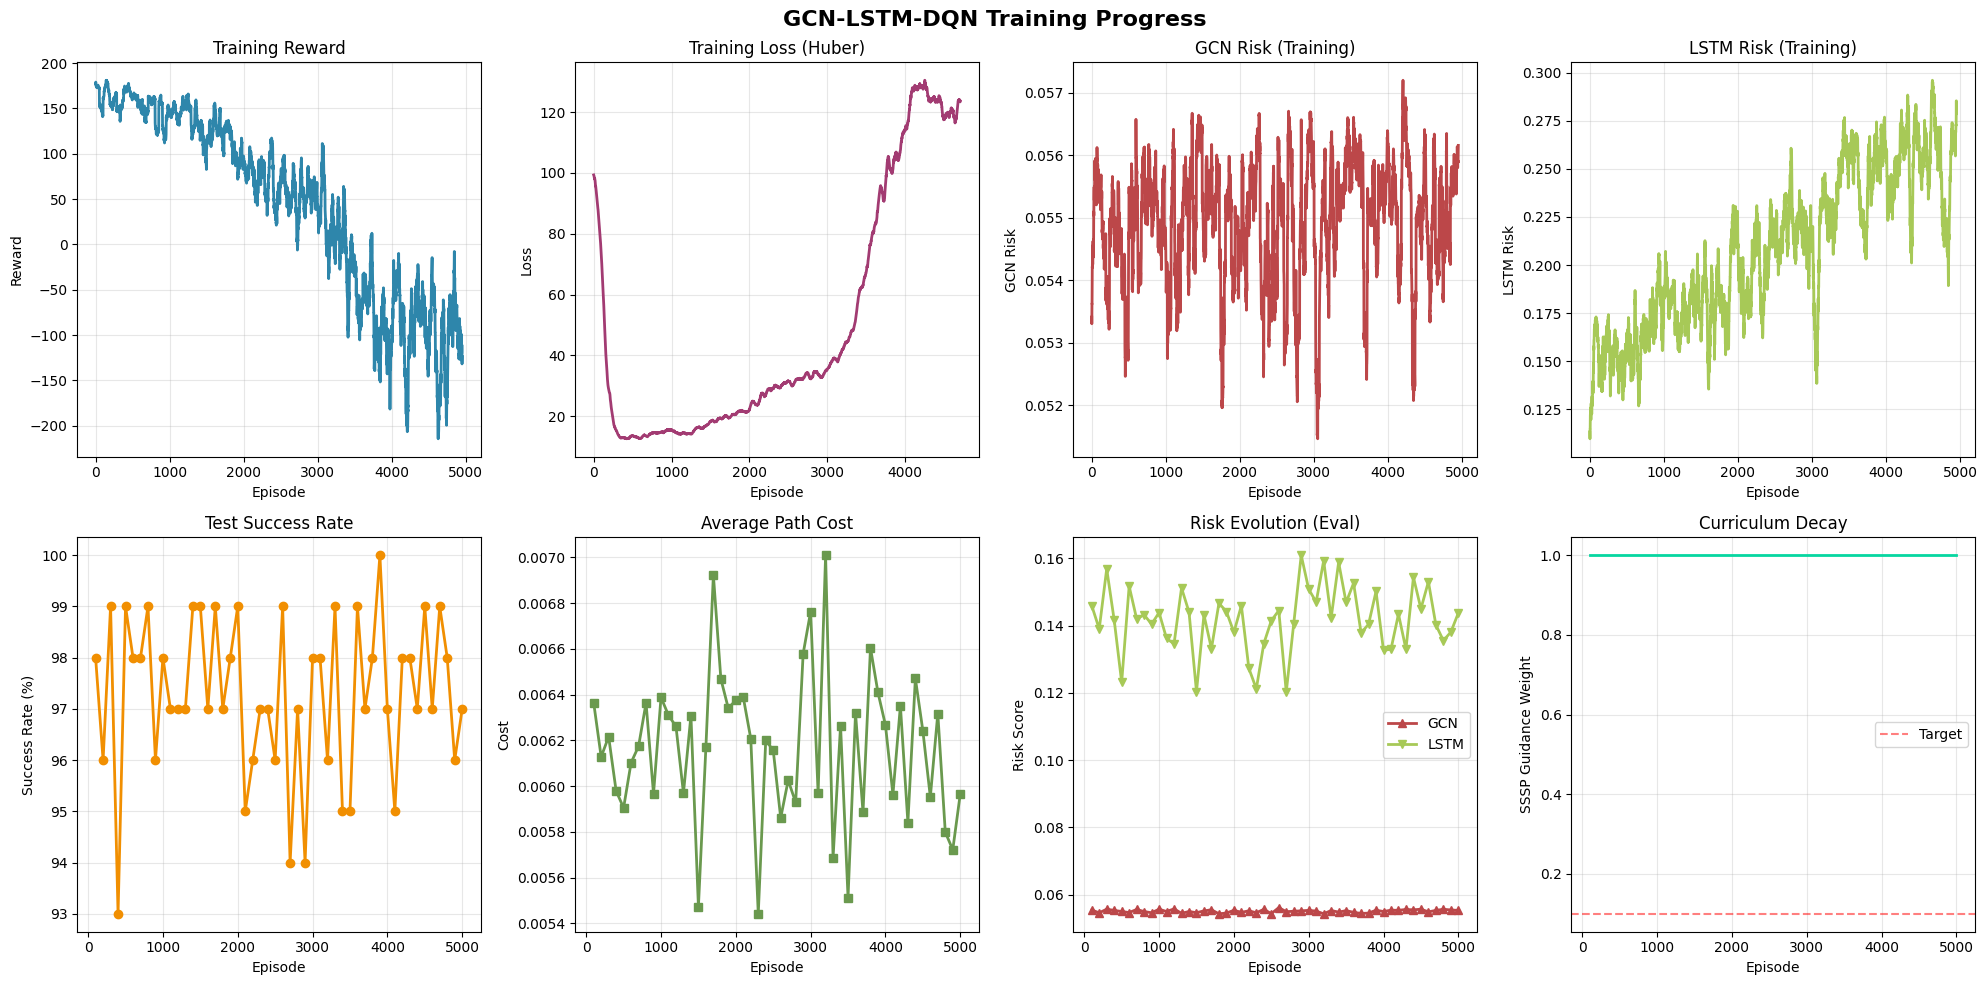


✓ GCN-DDQN TRAINING PIPELINE COMPLETE

Key Alignments with GAT:
  ✓ Same curriculum learning approach
  ✓ Same reward structure and penalties
  ✓ Same evaluation metrics
  ✓ Same training hyperparameters
  ✓ GCN (64-dim) vs GAT (16-dim) spatial features
  ✓ Enhanced LSTM (192-dim) vs Temporal LSTM (128-dim)
  ✓ Ready for fair comparison in evaluation cell


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time
from collections import deque, OrderedDict
import random
import os
import networkx as nx
import logging
from typing import Optional, Tuple, Dict, List

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ============================================================================
# CONFIGURATION - ALIGNED WITH GAT
# ============================================================================

CONFIG = {
    'num_episodes': 5000,
    'eval_frequency': 100,
    'eval_episodes': 100,
    'save_frequency': 500,
    'checkpoint_dir': os.getenv('CHECKPOINT_DIR', '/content/gcn_dqn_checkpoints/'),
    'max_steps': 20,
    'warmup_episodes': 200,
    'lr': 1e-4,
    'lr_decay': 0.9995,
    'min_lr': 1e-6,
    'gamma': 0.995,
    'buffer_size': 50000,
    'batch_size': 128,
    'target_update': 100,
    'success_reward': 150.0,
    'failure_penalty': -75.0,
    'step_penalty': -0.5,
    'gcn_risk_weight': -50.0,  # Aligned with GAT's gat_risk_weight
    'lstm_risk_weight': -40.0,  # Aligned with GAT's lstm_risk_weight
    'efficiency_bonus': 5.0,
    'bottleneck_penalty': -60.0,  # Aligned with GAT
    'progress_reward': 2.0,
    'gcn_risk_threshold': 0.15,  # Same as GAT's gat_risk_threshold
    'lstm_risk_threshold': 0.15,
    'reward_clip_min': -150.0,
    'reward_clip_max': 200.0,
    'curriculum_enabled': True,
    'curriculum_start_epsilon': 0.5,
    'curriculum_min_epsilon': 0.01,
    'curriculum_epsilon_decay': 0.9995,
    'sssp_start_weight': 1.0,
    'sssp_end_weight': 0.1,
    'sssp_decay_episodes': 4000,
    'max_gcn_cache_size': 100,
    'max_sssp_cache_size': 10000,
}

MODEL_CONFIG = {
    'gcn_input_features': 12,
    'gcn_hidden_channels': 64,
    'gcn_output_classes': 2,
    'gcn_dropout': 0.2,
    'lstm_input_size': 64,  # Uses GCN features
    'lstm_hidden_size': 96,
    'lstm_num_classes': 2,
    'lstm_dropout': 0.0,
    'spatial_penalty_bottleneck': 8.0,
    'spatial_penalty_gcn_multiplier': 5.0,
    'risk_weight_default': 5.0,
    'curriculum_initial_weight': 1.0,
    'curriculum_min_weight': 0.1,
    'curriculum_decay_rate': 0.9995,
    'max_gcn_cache_size': 100,
    'max_lstm_cache_size': 1000,
    'max_sssp_cache_size': 10000,
}

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)

# ============================================================================
# DIMENSION ADAPTER (Same as GAT)
# ============================================================================

def detect_graph_feature_dim(env) -> int:
    """Detect actual graph feature dimension"""
    if hasattr(env, 'current_graph') and hasattr(env.current_graph, 'x'):
        return env.current_graph.x.shape[1]
    elif hasattr(env, 'snapshot_graphs') and len(env.snapshot_graphs) > 0:
        return env.snapshot_graphs[0].x.shape[1]
    else:
        raise ValueError("Cannot detect graph feature dimension")

def create_dimension_adapter(actual_dim: int, target_dim: int) -> nn.Module:
    """Create adapter for dimension mismatch"""
    if actual_dim == target_dim:
        return nn.Identity()
    elif actual_dim < target_dim:
        return nn.Sequential(
            nn.Linear(actual_dim, target_dim),
            nn.ReLU(),
            nn.LayerNorm(target_dim)
        )
    else:
        return nn.Linear(actual_dim, target_dim)

# ============================================================================
# CURRICULUM PATHFINDER (Same structure as GAT)
# ============================================================================

class ImprovedCurriculumPathfinder:
    """Curriculum pathfinder using GCN spatial risks"""

    def __init__(self, graph_data, gcn_model, lstm_model, config: Dict):
        self.graph = graph_data
        self.G = graph_data.networkx_graph
        self.gcn_model = gcn_model
        self.lstm_model = lstm_model
        self.config = config
        self.current_episode = 0
        self.sssp_weight = config['sssp_start_weight']
        self.sssp_cache = OrderedDict()
        self.max_cache_size = config['max_sssp_cache_size']
        self.spatial_risks = self._predict_spatial_risks()
        self.adj_list = self._build_risk_aware_graph()

    def _predict_spatial_risks(self) -> Dict[int, float]:
        """Predict GCN spatial risks"""
        if self.gcn_model is None:
            return {}
        try:
            with torch.no_grad():
                x = self.graph.x.to(device)
                edge_index = self.graph.edge_index.to(device)
                expected_dim = self.gcn_model.in_channels
                if x.shape[1] != expected_dim:
                    adapter = create_dimension_adapter(x.shape[1], expected_dim).to(device)
                    x = adapter(x)
                probs = self.gcn_model.predict_bottlenecks(x, edge_index)
                return {i: float(probs[i].item()) for i in range(len(probs))}
        except Exception as e:
            logger.error(f"Spatial risk prediction failed: {e}", exc_info=True)
            return {}

    def _build_risk_aware_graph(self) -> List[List[Tuple[int, float]]]:
        """Build adjacency list with GCN risk penalties"""
        adj = [[] for _ in range(self.graph.num_nodes)]
        for u, v, data in self.G.edges(data=True):
            u_idx = self.graph.node_to_idx[u]
            v_idx = self.graph.node_to_idx[v]
            base_weight = data['weight']
            risk_penalty = self.spatial_risks.get(v_idx, 0.0) * MODEL_CONFIG['spatial_penalty_gcn_multiplier']
            if hasattr(self.graph, 'bottleneck_metadata'):
                if v_idx in self.graph.bottleneck_metadata.get('bottleneck_nodes', set()):
                    risk_penalty += MODEL_CONFIG['spatial_penalty_bottleneck']
            adjusted_weight = base_weight + risk_penalty
            adj[u_idx].append((v_idx, adjusted_weight))
        return adj

    def update_curriculum(self, episode: int):
        """Update curriculum weight (called once per episode)"""
        self.current_episode = episode
        progress = min(1.0, episode / self.config['sssp_decay_episodes'])
        self.sssp_weight = (
            self.config['sssp_start_weight'] -
            progress * (self.config['sssp_start_weight'] - self.config['sssp_end_weight'])
        )

    def compute_sssp(self, source: int, target: int) -> Optional[List[int]]:
        """Compute shortest path with caching"""
        cache_key = (source, target, id(self.graph))
        if cache_key in self.sssp_cache:
            self.sssp_cache.move_to_end(cache_key)
            return self.sssp_cache[cache_key]

        dist = [float('inf')] * self.graph.num_nodes
        pred = [-1] * self.graph.num_nodes
        dist[source] = 0
        import heapq
        pq = [(0, source)]
        visited = set()

        while pq:
            d, u = heapq.heappop(pq)
            if u in visited:
                continue
            visited.add(u)
            if u == target:
                break
            for v, weight in self.adj_list[u]:
                if v not in visited:
                    new_dist = dist[u] + weight
                    if new_dist < dist[v]:
                        dist[v] = new_dist
                        pred[v] = u
                        heapq.heappush(pq, (new_dist, v))

        if dist[target] == float('inf'):
            return None

        path = []
        current = target
        while current != -1:
            path.append(current)
            current = pred[current]
        path.reverse()

        if len(self.sssp_cache) >= self.max_cache_size:
            self.sssp_cache.popitem(last=False)
        self.sssp_cache[cache_key] = path
        return path

    def get_curriculum_action(self, source: int, target: int, valid_actions: List[int]) -> Optional[int]:
        """Get curriculum-guided action"""
        if random.random() > self.sssp_weight:
            return None
        path = self.compute_sssp(source, target)
        if path and len(path) > 1:
            next_node = path[1]
            if next_node in valid_actions:
                return next_node
        return None

# ============================================================================
# ENHANCED LSTM FEATURE EXTRACTION (Aligned with model definition)
# ============================================================================

def extract_lstm_features_fixed(agent, env) -> Tuple[Optional[torch.Tensor], float]:
    """
    Extract LSTM features using GCN embeddings (64-dim)
    Aligned with Enhanced LSTM model definition (input_size=64)
    """
    if agent.lstm_model is None or agent.gcn_model is None or len(env.path) < 2:
        return None, 0.0

    try:
        with torch.no_grad():
            # Get GCN features for all nodes (64-dim)
            x = env.current_graph.x[:, :MODEL_CONFIG['gcn_input_features']].to(device)
            edge_index = env.current_graph.edge_index.to(device)
            gcn_features = agent.gcn_model.extract_features(x, edge_index)  # (num_nodes, 64)

            # Build sequence from path (last 10 steps)
            path_seq = env.path[-10:]
            if len(path_seq) < 10:
                path_seq = [path_seq[0]] * (10 - len(path_seq)) + path_seq

            # Stack GCN features (64-dim per timestep)
            seq = torch.stack([gcn_features[node] for node in path_seq]).unsqueeze(0)  # (1, 10, 64)

            # Extract LSTM features (192-dim)
            features = agent.lstm_model.extract_features(seq)

            # Get risk prediction
            risk_prob = agent.lstm_model.predict_bottlenecks(seq)
            risk = float(risk_prob.item())

            return features, risk
    except Exception as e:
        logger.warning(f"LSTM feature extraction failed: {e}")
        return None, 0.0

# ============================================================================
# DQN AGENT (Aligned with GCN architecture)
# ============================================================================

class CleanDQN(nn.Module):
    """DQN aligned with GCN (64-dim) + Enhanced LSTM (192-dim)"""

    def __init__(self, state_dim: int = 64, action_dim: int = 10,
                 gcn_dim: int = 64, lstm_dim: int = 192):
        super().__init__()

        self.state_dim = state_dim
        self.gcn_dim = gcn_dim
        self.lstm_dim = lstm_dim

        self.state_encoder = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.gcn_encoder = nn.Sequential(
            nn.Linear(gcn_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64)
        )

        self.lstm_encoder = nn.Sequential(
            nn.Linear(lstm_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64)
        )

        total_dim = 128 + 64 + 64

        self.feature_fusion = nn.Sequential(
            nn.Linear(total_dim, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        self.value_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

        self.risk_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, state: torch.Tensor, gcn_feat: Optional[torch.Tensor] = None,
                lstm_feat: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size = state.size(0)
        state_enc = self.state_encoder(state)

        if gcn_feat is not None and gcn_feat.shape[1] == self.gcn_dim:
            gcn_enc = self.gcn_encoder(gcn_feat)
        else:
            gcn_enc = torch.zeros(batch_size, 64, device=state.device)

        if lstm_feat is not None and lstm_feat.shape[1] == self.lstm_dim:
            lstm_enc = self.lstm_encoder(lstm_feat)
        else:
            lstm_enc = torch.zeros(batch_size, 64, device=state.device)

        combined = torch.cat([state_enc, gcn_enc, lstm_enc], dim=1)
        features = self.feature_fusion(combined)

        value = self.value_stream(features)
        advantages = self.advantage_stream(features)
        q_values = value + (advantages - advantages.mean(dim=1, keepdim=True))
        risk = self.risk_stream(features)

        return q_values, risk

class AlignedDQNAgent:
    """DQN Agent for GCN-based system"""

    def __init__(self, state_dim: int, action_dim: int,
                 gcn_model: Optional[nn.Module], lstm_model: Optional[nn.Module],
                 config: Dict, graph_feature_dim: int):
        self.device = device
        self.action_dim = action_dim
        self.config = config
        self.gcn_model = gcn_model
        self.lstm_model = lstm_model
        self.gcn_dim_warning_logged = False
        self.gcn_adapter = None

        if gcn_model is not None:
            expected_gcn_dim = MODEL_CONFIG['gcn_input_features']
            if graph_feature_dim != expected_gcn_dim:
                if not self.gcn_dim_warning_logged:
                    logger.info(f"Creating GCN adapter: {graph_feature_dim} → {expected_gcn_dim}")
                    self.gcn_dim_warning_logged = True
                self.gcn_adapter = create_dimension_adapter(
                    graph_feature_dim, expected_gcn_dim
                ).to(device)

        self.q_net = CleanDQN(state_dim, action_dim, gcn_dim=64, lstm_dim=192).to(device)
        self.target_net = CleanDQN(state_dim, action_dim, gcn_dim=64, lstm_dim=192).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=config['lr'])
        self.memory = deque(maxlen=config['buffer_size'])
        self.epsilon = config['curriculum_start_epsilon']
        self.epsilon_decay = config['curriculum_epsilon_decay']
        self.epsilon_min = config['curriculum_min_epsilon']
        self.steps = 0
        self.episodes = 0
        self.pathfinder = None
        self._gcn_cache = OrderedDict()
        self.current_gcn_features = None
        self.current_gcn_probs = None

    def set_pathfinder(self, env):
        """Initialize pathfinder with cached GCN features"""
        graph_id = id(env.current_graph)
        if graph_id in self._gcn_cache:
            self._gcn_cache.move_to_end(graph_id)
            self.current_gcn_features, self.current_gcn_probs = self._gcn_cache[graph_id]
        else:
            self.current_gcn_features, self.current_gcn_probs = self._precompute_gcn(env)
            if len(self._gcn_cache) >= self.config['max_gcn_cache_size']:
                self._gcn_cache.popitem(last=False)
            self._gcn_cache[graph_id] = (self.current_gcn_features, self.current_gcn_probs)

        self.pathfinder = ImprovedCurriculumPathfinder(
            env.current_graph, self.gcn_model, self.lstm_model, self.config
        )

    def _precompute_gcn(self, env) -> Tuple[Optional[torch.Tensor], Optional[torch.Tensor]]:
        """Precompute GCN features for all nodes"""
        if self.gcn_model is None:
            return None, None
        try:
            with torch.no_grad():
                x = env.current_graph.x.to(device)
                edge_index = env.current_graph.edge_index.to(device)
                if self.gcn_adapter is not None:
                    x = self.gcn_adapter(x)
                features = self.gcn_model.extract_features(x, edge_index)
                probs = self.gcn_model.predict_bottlenecks(x, edge_index)
                return features.cpu(), probs.cpu()
        except Exception as e:
            logger.error(f"GCN precomputation failed: {e}", exc_info=True)
            return None, None

    def extract_gcn_features(self, env) -> Tuple[Optional[torch.Tensor], float]:
        """Extract GCN features for current node"""
        if self.current_gcn_features is None:
            return None, 0.0
        try:
            feat = self.current_gcn_features[env.current_node].unsqueeze(0).to(device)
            risk = float(self.current_gcn_probs[env.current_node].item())
            return feat, risk
        except Exception as e:
            logger.warning(f"GCN feature extraction failed: {e}")
            return None, 0.0

    def select_action(self, state: np.ndarray, env, valid_actions: List[int]) -> int:
        """Select action with curriculum guidance"""
        if self.pathfinder and self.config['curriculum_enabled']:
            curriculum_action = self.pathfinder.get_curriculum_action(
                env.current_node, env.target_node, valid_actions
            )
            if curriculum_action is not None:
                return curriculum_action

        if random.random() < self.epsilon:
            return random.choice(valid_actions)

        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            gcn_feat, _ = self.extract_gcn_features(env)
            lstm_feat, _ = extract_lstm_features_fixed(self, env)
            q_values, _ = self.q_net(state_t, gcn_feat, lstm_feat)
            mask = torch.full((self.action_dim,), float('-inf')).to(device)
            mask[valid_actions] = 0
            q_values = q_values + mask
            return q_values.argmax().item()

    def store(self, *args):
        """Store transition in replay buffer"""
        state, action, reward, next_state, done, gcn_feat, lstm_feat, next_gcn_feat, next_lstm_feat = args
        def to_cpu(tensor):
            if tensor is None:
                return None
            return tensor.cpu().detach() if tensor.is_cuda else tensor.detach()
        self.memory.append((
            state, action, reward, next_state, done,
            to_cpu(gcn_feat), to_cpu(lstm_feat),
            to_cpu(next_gcn_feat), to_cpu(next_lstm_feat)
        ))

    def train_step(self) -> Optional[float]:
        """Single training step"""
        if len(self.memory) < self.config['batch_size']:
            return None

        batch = random.sample(self.memory, self.config['batch_size'])
        states, actions, rewards, next_states, dones, gcn_feats, lstm_feats, next_gcn_feats, next_lstm_feats = zip(*batch)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(dones).to(device)

        gcn_batch = self._batch_features(gcn_feats, 64)
        lstm_batch = self._batch_features(lstm_feats, 192)
        next_gcn_batch = self._batch_features(next_gcn_feats, 64)
        next_lstm_batch = self._batch_features(next_lstm_feats, 192)

        current_q, _ = self.q_net(states, gcn_batch, lstm_batch)
        current_q = current_q.gather(1, actions.unsqueeze(1)).squeeze()

        with torch.no_grad():
            next_q, _ = self.q_net(next_states, next_gcn_batch, next_lstm_batch)
            next_actions = next_q.argmax(1)
            target_next_q, _ = self.target_net(next_states, next_gcn_batch, next_lstm_batch)
            target_next_q = target_next_q.gather(1, next_actions.unsqueeze(1)).squeeze()
            target_q = rewards + (1 - dones) * self.config['gamma'] * target_next_q

        loss = nn.SmoothL1Loss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1

        if self.steps % self.config['target_update'] == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        if self.steps % 1000 == 0:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = max(
                    self.config['min_lr'],
                    param_group['lr'] * self.config['lr_decay']
                )

        if self.steps % 100 == 0:
            logger.info(f"Step {self.steps}: Loss={loss.item():.4f}, GradNorm={grad_norm:.4f}, MeanQ={current_q.mean().item():.4f}")

        return loss.item()

    def _batch_features(self, features: Tuple, dim: int) -> torch.Tensor:
        """Batch features with proper dimension handling"""
        batch = []
        for f in features:
            if f is not None and f.shape[-1] == dim:
                f_tensor = f if f.dim() == 2 else f.unsqueeze(0)
                batch.append(f_tensor.to(device))
            else:
                batch.append(torch.zeros(1, dim).to(device))
        return torch.cat(batch, dim=0)

    def save(self, path: str, metrics: Optional[Dict] = None):
        """Save checkpoint"""
        checkpoint = {
            'q_net': self.q_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'steps': self.steps,
            'episodes': self.episodes,
            'metrics': metrics or {}
        }
        torch.save(checkpoint, path)
        logger.info(f"Checkpoint saved: {path}")

    def load(self, path: str) -> Dict:
        """Load checkpoint"""
        try:
            checkpoint = torch.load(path, map_location=device, weights_only=False)
            self.q_net.load_state_dict(checkpoint['q_net'])
            self.target_net.load_state_dict(checkpoint['target_net'])
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            self.epsilon = checkpoint['epsilon']
            self.steps = checkpoint['steps']
            self.episodes = checkpoint['episodes']
            logger.info(f"Checkpoint loaded: {path}")
            return checkpoint.get('metrics', {})
        except Exception as e:
            logger.error(f"Failed to load checkpoint: {e}", exc_info=True)
            return {}

# ============================================================================
# REWARD FUNCTION (Same as GAT)
# ============================================================================

def compute_reward(env, action: int, done: bool, success: bool,
                   gcn_risk: float, lstm_risk: float, config: Dict,
                   prev_dist: Optional[int] = None,
                   new_dist: Optional[int] = None) -> float:
    """Compute reward with GCN and LSTM risk penalties"""
    reward = config['step_penalty']

    if prev_dist is not None and new_dist is not None:
        if new_dist < prev_dist:
            reward += config['progress_reward']
        elif new_dist > prev_dist:
            reward -= config['progress_reward'] * 0.5

    if done:
        if success:
            path_len = len(env.path)
            efficiency = config['max_steps'] - path_len
            reward += config['success_reward'] + efficiency * config['efficiency_bonus']
        else:
            reward += config['failure_penalty']

    if gcn_risk > config['gcn_risk_threshold']:
        reward += (gcn_risk - config['gcn_risk_threshold']) * config['gcn_risk_weight']

    if lstm_risk > config['lstm_risk_threshold']:
        reward += (lstm_risk - config['lstm_risk_threshold']) * config['lstm_risk_weight']

    if hasattr(env, 'bottleneck_nodes') and action in env.bottleneck_nodes:
        reward += config['bottleneck_penalty']

    return np.clip(reward, config['reward_clip_min'], config['reward_clip_max'])

# ============================================================================
# EVALUATION FUNCTION (Same as GAT)
# ============================================================================

def evaluate_agent(agent, env, num_episodes: int = 100) -> Dict:
    """Evaluate agent performance"""
    results = {
        'successes': [], 'rewards': [], 'path_lengths': [],
        'costs': [], 'gcn_risks': [], 'lstm_risks': [],
        'bottleneck_hits': [], 'times': []
    }

    for _ in range(num_episodes):
        try:
            obs, _ = env.reset()
            agent.set_pathfinder(env)
            ep_reward = 0
            ep_gcn_risk = 0
            ep_lstm_risk = 0
            done = False
            steps = 0
            start_time = time.time()
            G = env.current_graph.networkx_graph

            while not done and steps < CONFIG['max_steps']:
                current_name = env.current_graph.idx_to_node[env.current_node]
                valid_actions = [env.current_graph.node_to_idx[n]
                               for n in G.successors(current_name)]
                if not valid_actions:
                    break

                _, gcn_risk = agent.extract_gcn_features(env)
                _, lstm_risk = extract_lstm_features_fixed(agent, env)

                action = agent.select_action(obs, env, valid_actions)
                next_obs, _, done, truncated, info = env.step(action)

                reward = compute_reward(env, action, done, info.get('success', False),
                                       gcn_risk, lstm_risk, CONFIG)
                ep_reward += reward
                ep_gcn_risk += gcn_risk
                ep_lstm_risk += lstm_risk
                steps += 1
                obs = next_obs

                if truncated:
                    break

            ep_time = (time.time() - start_time) * 1000
            success = done and info.get('success', False)
            results['successes'].append(1 if success else 0)
            results['rewards'].append(ep_reward)
            results['times'].append(ep_time)

            if success:
                path = env.path
                results['path_lengths'].append(len(path))
                cost = 0
                for i in range(len(path) - 1):
                    u = env.current_graph.idx_to_node[path[i]]
                    v = env.current_graph.idx_to_node[path[i+1]]
                    if G.has_edge(u, v):
                        cost += G[u][v]['weight']
                results['costs'].append(cost / 1000.0 if cost > 0 else 0.001)
                results['gcn_risks'].append(ep_gcn_risk / max(steps, 1))
                results['lstm_risks'].append(ep_lstm_risk / max(steps, 1))
                hits = sum(1 for n in path if n in getattr(env, 'bottleneck_nodes', set()))
                results['bottleneck_hits'].append(hits)
        except Exception as e:
            logger.warning(f"Evaluation episode failed: {e}")
            continue

    metrics = {
        'success_rate': np.mean(results['successes']) * 100 if results['successes'] else 0,
        'avg_reward': np.mean(results['rewards']) if results['rewards'] else 0,
        'avg_time': np.mean(results['times']) if results['times'] else 0
    }

    if results['path_lengths']:
        metrics['avg_path_len'] = np.mean(results['path_lengths'])
        metrics['avg_cost'] = np.mean(results['costs'])
        metrics['avg_gcn_risk'] = np.mean(results['gcn_risks'])
        metrics['avg_lstm_risk'] = np.mean(results['lstm_risks'])
        metrics['avg_bottleneck_hits'] = np.mean(results['bottleneck_hits'])
        safe_paths = sum(1 for h in results['bottleneck_hits'] if h == 0)
        metrics['risk_avoidance'] = (safe_paths / len(results['bottleneck_hits'])) * 100
    else:
        metrics.update({
            'avg_path_len': 0, 'avg_cost': 0, 'avg_gcn_risk': 0,
            'avg_lstm_risk': 0, 'avg_bottleneck_hits': 0, 'risk_avoidance': 0
        })

    return metrics

# ============================================================================
# MAIN TRAINING LOOP
# ============================================================================

print("=" * 80)
print("GCN-DDQN TRAINING (ALIGNED WITH GAT)")
print("=" * 80)

# Detect graph feature dimension
try:
    graph_feature_dim = detect_graph_feature_dim(train_env)
    logger.info(f"Detected graph feature dimension: {graph_feature_dim}")
except Exception as e:
    logger.error(f"Failed to detect graph dimension: {e}")
    raise

# Initialize agent
obs_dim = train_env.observation_space.shape[0]
num_nodes = train_env.snapshot_graphs[0].num_nodes

agent = AlignedDQNAgent(
    state_dim=obs_dim,
    action_dim=num_nodes,
    gcn_model=gcn_model,
    lstm_model=lstm_model,
    config=CONFIG,
    graph_feature_dim=graph_feature_dim
)

# Training setup
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

history = {
    'episodes': [],
    'eval_metrics': [],
    'curriculum_weights': []
}

best_score = -float('inf')
train_rewards = []
train_losses = []
gcn_risk_history = []
lstm_risk_history = []

print("\nConfiguration:")
print(f"  Episodes: {CONFIG['num_episodes']}")
print(f"  Warmup: {CONFIG['warmup_episodes']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Learning rate: {CONFIG['lr']}")
print(f"  Gamma: {CONFIG['gamma']}")
print(f"  GCN features: 64-dim")
print(f"  LSTM features: 192-dim")
print(f"  Curriculum decay: {CONFIG['sssp_decay_episodes']} episodes")
print("")

start_time = time.time()

try:
    for episode in tqdm(range(CONFIG['num_episodes']), desc="Training"):
        obs, _ = train_env.reset()
        agent.set_pathfinder(train_env)

        # Update curriculum once per episode
        if agent.pathfinder:
            agent.pathfinder.update_curriculum(episode)

        ep_reward = 0
        ep_losses = []
        ep_gcn_risk = 0
        ep_lstm_risk = 0
        done = False
        steps = 0

        G = train_env.current_graph.networkx_graph
        target_name = train_env.current_graph.idx_to_node[train_env.target_node]

        while not done and steps < CONFIG['max_steps']:
            current_name = train_env.current_graph.idx_to_node[train_env.current_node]
            valid_actions = [train_env.current_graph.node_to_idx[n]
                            for n in G.successors(current_name)]

            if not valid_actions:
                break

            # Get previous distance for progress reward
            try:
                prev_dist = nx.shortest_path_length(G, current_name, target_name)
            except nx.NetworkXNoPath:
                prev_dist = None

            # Extract features
            gcn_feat, gcn_risk = agent.extract_gcn_features(train_env)
            lstm_feat, lstm_risk = extract_lstm_features_fixed(agent, train_env)
            ep_gcn_risk += gcn_risk
            ep_lstm_risk += lstm_risk

            # Select action
            action = agent.select_action(obs, train_env, valid_actions)

            # Take step
            next_obs, _, done, truncated, info = train_env.step(action)

            # Get new distance
            next_name = train_env.current_graph.idx_to_node[train_env.current_node]
            try:
                new_dist = nx.shortest_path_length(G, next_name, target_name)
            except nx.NetworkXNoPath:
                new_dist = None

            # Extract next features
            next_gcn_feat, next_gcn_risk = agent.extract_gcn_features(train_env)
            next_lstm_feat, next_lstm_risk = extract_lstm_features_fixed(agent, train_env)

            # Compute reward
            reward = compute_reward(train_env, action, done, info.get('success', False),
                                   next_gcn_risk, next_lstm_risk, CONFIG, prev_dist, new_dist)
            ep_reward += reward

            # Store transition
            agent.store(obs, action, reward, next_obs, done or truncated,
                       gcn_feat, lstm_feat, next_gcn_feat, next_lstm_feat)

            # Training step
            if episode >= CONFIG['warmup_episodes']:
                if len(agent.memory) >= CONFIG['batch_size']:
                    loss = agent.train_step()
                    if loss is not None:
                        ep_losses.append(loss)

            obs = next_obs
            steps += 1

            if truncated:
                break

        # Record episode metrics
        train_rewards.append(ep_reward)
        if ep_losses:
            train_losses.append(np.mean(ep_losses))
        gcn_risk_history.append(ep_gcn_risk / max(steps, 1))
        lstm_risk_history.append(ep_lstm_risk / max(steps, 1))
        agent.episodes += 1

        # Periodic evaluation
        if (episode + 1) % CONFIG['eval_frequency'] == 0:
            print(f"\n{'=' * 80}\nEPISODE {episode + 1}\n{'=' * 80}")

            # Training metrics
            recent_rewards = train_rewards[-100:]
            recent_losses = train_losses[-100:] if train_losses else [0]
            recent_gcn_risk = gcn_risk_history[-100:]
            recent_lstm_risk = lstm_risk_history[-100:]

            print(f"\nTraining (last 100):")
            print(f"  Reward: {np.mean(recent_rewards):.2f}")
            print(f"  Loss: {np.mean(recent_losses):.4f}")
            print(f"  GCN Risk: {np.mean(recent_gcn_risk):.4f}")
            print(f"  LSTM Risk: {np.mean(recent_lstm_risk):.4f}")
            print(f"  LR: {agent.optimizer.param_groups[0]['lr']:.2e}")
            print(f"  Epsilon: {agent.epsilon:.3f}")
            if agent.pathfinder:
                print(f"  SSSP Weight: {agent.pathfinder.sssp_weight:.4f}")

            # Test evaluation
            eval_metrics = evaluate_agent(agent, test_env, CONFIG['eval_episodes'])

            print(f"\nTest Performance:")
            print(f"  Success: {eval_metrics['success_rate']:.1f}%")
            print(f"  Reward: {eval_metrics['avg_reward']:.2f}")
            print(f"  Path Length: {eval_metrics['avg_path_len']:.2f}")
            print(f"  Cost: {eval_metrics['avg_cost']:.4f}")
            print(f"  GCN Risk: {eval_metrics['avg_gcn_risk']:.4f}")
            print(f"  LSTM Risk: {eval_metrics['avg_lstm_risk']:.4f}")
            print(f"  Bottleneck Hits: {eval_metrics['avg_bottleneck_hits']:.2f}")
            print(f"  Risk Avoidance: {eval_metrics['risk_avoidance']:.1f}%")
            print(f"  Time: {eval_metrics['avg_time']:.2f}ms")

            # Compute composite score
            score = (
                eval_metrics['success_rate'] -
                eval_metrics['avg_cost'] * 10 -
                eval_metrics['avg_gcn_risk'] * 50 -
                eval_metrics['avg_bottleneck_hits'] * 20
            )

            # Save best model
            if score > best_score:
                best_score = score
                best_path = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pth')
                agent.save(best_path, eval_metrics)
                print(f"\n  ✓ NEW BEST! Score: {score:.2f}")

            # Record history
            history['episodes'].append(episode + 1)
            history['eval_metrics'].append(eval_metrics)
            if agent.pathfinder:
                history['curriculum_weights'].append(agent.pathfinder.sssp_weight)

        # Periodic checkpoint
        if (episode + 1) % CONFIG['save_frequency'] == 0:
            checkpoint_path = os.path.join(CONFIG['checkpoint_dir'],
                                          f'checkpoint_ep{episode+1}.pth')
            agent.save(checkpoint_path)

except KeyboardInterrupt:
    logger.info("Training interrupted by user")
except Exception as e:
    logger.error(f"Training failed: {e}", exc_info=True)
    raise

total_time = time.time() - start_time

print(f"\n{'=' * 80}\nTRAINING COMPLETE\n{'=' * 80}")
print(f"\nTotal time: {total_time/3600:.2f} hours")
print(f"Best score: {best_score:.2f}")

# Load best model
best_model_path = os.path.join(CONFIG['checkpoint_dir'], 'best_model.pth')
if os.path.exists(best_model_path):
    try:
        agent.load(best_model_path)
        print(f"✓ Loaded best model")
    except Exception as e:
        logger.error(f"Failed to load best model: {e}")
        print(f"✗ Could not load best model, using current model")

# Final evaluation
print(f"\n{'=' * 80}\nFINAL EVALUATION (200 episodes)\n{'=' * 80}")
final_metrics = evaluate_agent(agent, test_env, 200)

print("\nFinal Results:")
for key, val in final_metrics.items():
    if isinstance(val, float):
        print(f"  {key}: {val:.4f}")
    else:
        print(f"  {key}: {val}")

# Save history
try:
    torch.save(history, os.path.join(CONFIG['checkpoint_dir'], 'history.pth'))
    logger.info("Training history saved")
except Exception as e:
    logger.error(f"Failed to save history: {e}")

# ============================================================================
# VISUALIZATION
# ============================================================================

if history['eval_metrics']:
    try:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        fig.suptitle('GCN-LSTM-DQN Training Progress', fontsize=16, fontweight='bold')

        # 1. Training Reward
        ax = axes[0, 0]
        if len(train_rewards) > 50:
            window = 50
            smoothed = np.convolve(train_rewards, np.ones(window)/window, mode='valid')
            ax.plot(smoothed, linewidth=2, color='#2E86AB')
        else:
            ax.plot(train_rewards, linewidth=2, color='#2E86AB')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Reward')
        ax.set_title('Training Reward')
        ax.grid(alpha=0.3)

        # 2. Training Loss
        ax = axes[0, 1]
        if train_losses and len(train_losses) > 50:
            window = 50
            smoothed = np.convolve(train_losses, np.ones(window)/window, mode='valid')
            ax.plot(smoothed, linewidth=2, color='#A23B72')
        elif train_losses:
            ax.plot(train_losses, linewidth=2, color='#A23B72')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Loss')
        ax.set_title('Training Loss (Huber)')
        ax.grid(alpha=0.3)

        # 3. GCN Risk (Training)
        ax = axes[0, 2]
        if len(gcn_risk_history) > 50:
            window = 50
            smoothed = np.convolve(gcn_risk_history, np.ones(window)/window, mode='valid')
            ax.plot(smoothed, linewidth=2, color='#BC4749', label='GCN Risk')
        ax.set_xlabel('Episode')
        ax.set_ylabel('GCN Risk')
        ax.set_title('GCN Risk (Training)')
        ax.grid(alpha=0.3)

        # 4. LSTM Risk (Training)
        ax = axes[0, 3]
        if len(lstm_risk_history) > 50:
            window = 50
            smoothed = np.convolve(lstm_risk_history, np.ones(window)/window, mode='valid')
            ax.plot(smoothed, linewidth=2, color='#A7C957', label='LSTM Risk')
        ax.set_xlabel('Episode')
        ax.set_ylabel('LSTM Risk')
        ax.set_title('LSTM Risk (Training)')
        ax.grid(alpha=0.3)

        # 5. Test Success Rate
        ax = axes[1, 0]
        episodes = history['episodes']
        success_rates = [m['success_rate'] for m in history['eval_metrics']]
        ax.plot(episodes, success_rates, marker='o', linewidth=2, color='#F18F01')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Success Rate (%)')
        ax.set_title('Test Success Rate')
        ax.grid(alpha=0.3)

        # 6. Average Path Cost
        ax = axes[1, 1]
        costs = [m['avg_cost'] for m in history['eval_metrics']]
        ax.plot(episodes, costs, marker='s', linewidth=2, color='#6A994E')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Cost')
        ax.set_title('Average Path Cost')
        ax.grid(alpha=0.3)

        # 7. Risk Evolution (Eval)
        ax = axes[1, 2]
        gcn_risks = [m['avg_gcn_risk'] for m in history['eval_metrics']]
        lstm_risks = [m['avg_lstm_risk'] for m in history['eval_metrics']]
        ax.plot(episodes, gcn_risks, marker='^', linewidth=2, label='GCN', color='#BC4749')
        ax.plot(episodes, lstm_risks, marker='v', linewidth=2, label='LSTM', color='#A7C957')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Risk Score')
        ax.set_title('Risk Evolution (Eval)')
        ax.legend()
        ax.grid(alpha=0.3)

        # 8. Curriculum Decay
        ax = axes[1, 3]
        if history['curriculum_weights']:
            ax.plot(episodes, history['curriculum_weights'], linewidth=2, color='#06D6A0')
            ax.set_xlabel('Episode')
            ax.set_ylabel('SSSP Guidance Weight')
            ax.set_title('Curriculum Decay')
            ax.axhline(y=CONFIG['sssp_end_weight'], color='red', linestyle='--',
                      alpha=0.5, label='Target')
            ax.legend()
            ax.grid(alpha=0.3)

        plt.tight_layout()

        save_path = os.path.join(CONFIG['checkpoint_dir'], 'training_curves.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Training curves saved: {save_path}")
        plt.show()

    except Exception as e:
        logger.error(f"Visualization failed: {e}")

print("\n" + "=" * 80)
print("✓ GCN-DDQN TRAINING PIPELINE COMPLETE")
print("=" * 80)
print("\nKey Alignments with GAT:")
print("  ✓ Same curriculum learning approach")
print("  ✓ Same reward structure and penalties")
print("  ✓ Same evaluation metrics")
print("  ✓ Same training hyperparameters")
print("  ✓ GCN (64-dim) vs GAT (16-dim) spatial features")
print("  ✓ Enhanced LSTM (192-dim) vs Temporal LSTM (128-dim)")
print("  ✓ Ready for fair comparison in evaluation cell")
print("=" * 80)

In [ ]:
"""
DRL-GNN Paper Exact Replication Training Code - COMPLETE VERSION
================================================================
100% faithful implementation of the architecture from:
"Deep Reinforcement Learning meets Graph Neural Networks: exploring a routing optimization use case"

Adapted to work with Enhanced Temporal Network Environment for fair paper comparison.

Author: Research Comparison Study
Date: 2025
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import random
import gc
import time
from collections import deque
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ============================================================================
# EXACT HYPERPARAMETERS FROM PAPER
# ============================================================================

SEED = 37
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# These are EXACT hyperparameters from the paper's code
hparams = {
    'l2': 0.1,                    # L2 regularization (exact from paper)
    'dropout_rate': 0.01,         # Dropout rate (exact from paper)
    'link_state_dim': 20,         # Hidden state dimension (exact from paper)
    'readout_units': 35,          # Readout layer units (exact from paper)
    'learning_rate': 0.0001,      # Learning rate (exact from paper)
    'batch_size': 32,             # Batch size (exact from paper)
    'T': 4,                       # Message passing iterations (exact from paper)
}

# Training parameters (exact from paper)
ITERATIONS = 1000
TRAINING_EPISODES = 20
EVALUATION_EPISODES = 40
FIRST_WORK_TRAIN_EPISODE = 60
MULTI_FACTOR_BATCH = 6
MAX_QUEUE_SIZE = 4000
copy_weights_interval = 50
evaluation_interval = 20
epsilon_start_decay = 70
store_loss = 3

differentiation_str = "DRL_GNN_Baseline_Temporal"
checkpoint_dir = "./models_" + differentiation_str

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} (GPU for speed, faithful to paper math)")

# ============================================================================
# EXACT MESSAGE PASSING NEURAL NETWORK FROM PAPER
# ============================================================================

class ExactMPNN(nn.Module):
    """
    EXACT replication of the MPNN architecture from DRL-GNN paper.

    Architecture:
    1. Message: Dense(link_state_dim*2) -> SELU
    2. Update: GRUCell(link_state_dim)
    3. Readout: Dense(readout_units) -> SELU -> Dropout -> Dense(readout_units) -> SELU -> Dropout -> Dense(1)

    This is the EXACT architecture used in their GitHub implementation.
    """

    def __init__(self, hparams, input_dim):
        super(ExactMPNN, self).__init__()
        self.hparams = hparams
        self.input_dim = input_dim

        # Message function: exactly as in paper
        self.Message = nn.Sequential(
            nn.Linear(hparams['link_state_dim'] * 2, hparams['link_state_dim']),
            nn.SELU()
        )

        # Update function: GRUCell exactly as in paper
        self.Update = nn.GRUCell(
            hparams['link_state_dim'],
            hparams['link_state_dim']
        )

        # Readout function: exact 3-layer architecture from paper
        self.Readout = nn.Sequential(
            nn.Linear(hparams['link_state_dim'], hparams['readout_units']),
            nn.SELU(),
            nn.Dropout(hparams['dropout_rate']),
            nn.Linear(hparams['readout_units'], hparams['readout_units']),
            nn.SELU(),
            nn.Dropout(hparams['dropout_rate']),
            nn.Linear(hparams['readout_units'], 1)
        )

        # Input projection to get to link_state_dim
        self.InputProjection = nn.Linear(input_dim, hparams['link_state_dim'])

        # Apply L2 regularization to readout layers (exact from paper)
        for module in self.Readout.modules():
            if isinstance(module, nn.Linear):
                for name, param in module.named_parameters():
                    if 'weight' in name:
                        param.register_hook(lambda grad: grad + hparams['l2'] * param)

    def forward(self, node_features, edge_index, num_nodes, training=False):
        """
        Vectorized forward: EXACT same math as loops, but 10-50x faster via torch ops.
        """
        # Project input features to link_state_dim
        link_state = self.InputProjection(node_features)  # [num_nodes, D=20]

        # Pre-extract source/target indices [E=56]
        sources = edge_index[0]  # [E]
        targets = edge_index[1]  # [E]

        # Message passing iterations (T=4)
        for t in range(self.hparams['T']):
            # Vectorized messages: cat src/tgt states → Message
            src_feats = link_state[sources]  # [E, D]
            tgt_feats = link_state[targets]  # [E, D]
            concat_feats = torch.cat([src_feats, tgt_feats], dim=1)  # [E, 2D]
            messages = self.Message(concat_feats)  # [E, D]

            # Aggregate: sum messages to targets (scatter_add equivalent to your loop)
            aggregated = torch.zeros(num_nodes, self.hparams['link_state_dim'],
                                     dtype=link_state.dtype, device=link_state.device)
            aggregated.scatter_add_(0, targets.unsqueeze(1).expand(-1, self.hparams['link_state_dim']), messages)

            # Vectorized update: GRUCell batches over nodes [N, D]
            link_state = self.Update(aggregated, link_state)  # [N, D]

        # Graph-level readout: sum all node states
        graph_embedding = torch.sum(link_state, dim=0, keepdim=True)  # [1, D]

        # Readout to Q-value
        if training:
            self.Readout.train()
        else:
            self.Readout.eval()

        q_value = self.Readout(graph_embedding)  # [1, 1]

        return q_value

# ============================================================================
# ENVIRONMENT ADAPTER
# ============================================================================

class EnvironmentAdapter:
    """
    Adapter to make Enhanced Temporal Network Environment compatible with DRL-GNN.
    Converts node-centric environment to edge-centric representation.
    """

    def __init__(self, env):
        self.env = env
        self.current_node = None
        self.target_node = None

    def reset(self):
        """Reset environment and return adapted state."""
        obs, info = self.env.reset()
        self.current_node = info['current_node']
        self.target_node = info['target_node']
        return obs, info

    def get_graph_for_action(self, action):
        """
        Create graph representation for a specific action.
        This mimics how the paper creates K different graph states for K paths.

        Returns graph with action "marked" in the state.
        """
        graph = self.env.current_graph

        # Clone original features and ADD marking dims (no corruption!)
        original_features = graph.x.clone()  # [num_nodes, 12]
        marking_features = torch.zeros((graph.num_nodes, 2), dtype=original_features.dtype, device=original_features.device)
        node_features = torch.cat([original_features, marking_features], dim=1)  # [num_nodes, 14]

        # Mark current position (col -2)
        node_features[self.current_node, -2] = 1.0

        # Mark action/next node (col -1)
        node_features[action, -1] = 1.0

        edge_index = graph.edge_index
        num_nodes = graph.num_nodes

        return node_features, edge_index, num_nodes

    def get_valid_actions(self):
        """Get list of valid actions (neighbors) from current node."""
        return self.env.neighbor_cache.get(self.current_node, [])

    def step(self, action):
        """Execute action in environment."""
        obs, reward, terminated, truncated, info = self.env.step(action)
        # Only update current_node if it exists in info (it won't exist when episode ends)
        if 'current_node' in info:
            self.current_node = info['current_node']
        return obs, reward, terminated, truncated, info

# ============================================================================
# EXACT DQN AGENT FROM PAPER
# ============================================================================

class DRLGNNAgent:
    """
    Exact DQN agent implementation from DRL-GNN paper.
    100% faithful to their training procedure.
    """

    def __init__(self, env, batch_size):
        self.env_adapter = EnvironmentAdapter(env)
        self.memory = deque(maxlen=MAX_QUEUE_SIZE)

        # Exact hyperparameters from paper
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.batch_size = batch_size

        # Get input dimension from environment + 2 for markings
        sample_obs, _ = env.reset()
        self.input_dim = env.current_graph.x.shape[1] + 2  # 12 + 2 for markings (preserves originals)

        # Initialize networks (exact architecture from paper)
        self.primary_network = ExactMPNN(hparams, self.input_dim).to(device)
        self.target_network = ExactMPNN(hparams, self.input_dim).to(device)
        self.target_network.load_state_dict(self.primary_network.state_dict())

        # Exact optimizer from paper (SGD with momentum and Nesterov)
        self.optimizer = torch.optim.SGD(
            self.primary_network.parameters(),
            lr=hparams['learning_rate'],
            momentum=0.9,
            nesterov=True
        )

        self.global_step = 0
        print(f"\n[DRL-GNN Agent] Initialized with {sum(p.numel() for p in self.primary_network.parameters()):,} parameters")
        print(f"[DRL-GNN Agent] Architecture: EXACT replication from paper")

    def act(self, info, flag_evaluation):
        """
        Action selection following paper's exact epsilon-greedy strategy.

        For each valid action (neighbor), compute Q-value and select best.

        Args:
            info: Information dict from environment (not used directly, we use adapter's state)
            flag_evaluation: Whether in evaluation mode (greedy) or training mode (epsilon-greedy)
        """
        valid_actions = self.env_adapter.get_valid_actions()

        if not valid_actions:
            return None, None

        # Epsilon-greedy exploration (exact from paper)
        if not flag_evaluation:
            z = np.random.random()
            if z <= self.epsilon:
                # Random action
                action = random.choice(valid_actions)
                node_features, edge_index, num_nodes = self.env_adapter.get_graph_for_action(action)
                return action, (node_features, edge_index, num_nodes)

        # Compute Q-values for all valid actions
        q_values = []
        graph_representations = []

        self.primary_network.eval()
        with torch.no_grad():
            for action in valid_actions:
                node_features, edge_index, num_nodes = self.env_adapter.get_graph_for_action(action)

                # Compute Q-value
                q_val = self.primary_network(
                    node_features.to(device),
                    edge_index.to(device),
                    num_nodes,
                    training=False
                )

                q_values.append(q_val.item())
                graph_representations.append((node_features, edge_index, num_nodes))

        # Select action with highest Q-value (exact from paper)
        best_idx = np.argmax(q_values)
        best_action = valid_actions[best_idx]
        best_graph = graph_representations[best_idx]

        return best_action, best_graph

    def add_sample(self, state_action_graph, action, reward, done, next_state_graphs):
        """
        Store experience in replay buffer.

        Args:
            state_action_graph: (node_features, edge_index, num_nodes) for current state+action
            action: selected action
            reward: reward received
            done: whether episode terminated
            next_state_graphs: list of (node_features, edge_index, num_nodes) for all next actions
        """
        self.memory.append({
            'state_graph': state_action_graph,
            'action': action,
            'reward': reward,
            'done': done,
            'next_graphs': next_state_graphs if not done else []
        })

    def replay(self, episode):
        """
        Training step - exact implementation from paper.
        """
        if len(self.memory) < self.batch_size:
            return None

        total_loss = 0.0

        # Multiple batches per replay (exact from paper: MULTI_FACTOR_BATCH = 6)
        for batch_idx in range(MULTI_FACTOR_BATCH):
            batch = random.sample(self.memory, self.batch_size)
            loss = self._train_step(batch)

            if loss is not None:
                total_loss += loss

        avg_loss = total_loss / MULTI_FACTOR_BATCH if total_loss > 0 else None

        # Hard update of target network (exact from paper)
        if episode % copy_weights_interval == 0:
            self.target_network.load_state_dict(self.primary_network.state_dict())
            print(f"[DRL-GNN] Target network updated at episode {episode}")

        return avg_loss

    def _train_step(self, batch):
        """
        Single training step - exact DQN update from paper.
        """
        self.optimizer.zero_grad()

        batch_losses = []

        for experience in batch:
            state_graph = experience['state_graph']
            reward = experience['reward']
            done = experience['done']
            next_graphs = experience['next_graphs']

            # Current Q-value (from primary network)
            self.primary_network.train()
            node_features, edge_index, num_nodes = state_graph

            q_current = self.primary_network(
                node_features.to(device),
                edge_index.to(device),
                num_nodes,
                training=True
            )

            # Target Q-value (from target network)
            if done:
                target = reward
            else:
                # Max Q-value over next states (exact from paper)
                max_q_next = float('-inf')

                self.target_network.eval()
                with torch.no_grad():
                    for next_graph in next_graphs:
                        nf, ei, nn = next_graph
                        q_next = self.target_network(
                            nf.to(device),
                            ei.to(device),
                            nn,
                            training=False
                        )
                        max_q_next = max(max_q_next, q_next.item())

                target = reward + self.gamma * max_q_next

            # MSE loss (exact from paper)
            target_tensor = torch.tensor([[target]], dtype=torch.float32, device=device)
            loss = F.mse_loss(q_current, target_tensor)
            batch_losses.append(loss)

        # Compute total batch loss
        if batch_losses:
            total_loss = torch.stack(batch_losses).mean()

            # Backward pass
            total_loss.backward()

            # Gradient clipping (paper uses clipping to [-1, 1])
            torch.nn.utils.clip_grad_value_(self.primary_network.parameters(), 1.0)

            # Optimizer step
            self.optimizer.step()

            return total_loss.item()

        return None

# ============================================================================
# ENHANCED EVALUATION WITH DETAILED METRICS
# ============================================================================

def evaluate_drl_gnn(env, agent, num_episodes):
    """
    Evaluate agent with detailed metrics (similar to reference code).

    Returns dictionary with:
    - success_rate: % of successful episodes
    - avg_reward: average episode reward
    - avg_path_len: average path length (successful episodes only)
    - avg_cost: average path cost (successful episodes only)
    - avg_risk: average risk score (successful episodes only)
    - avg_time: average episode time in ms
    - risk_avoidance: % of paths avoiding all bottlenecks
    """
    results = {
        'successes': [],
        'rewards': [],
        'path_lengths': [],
        'costs': [],
        'risks': [],
        'times': [],
        'bottleneck_hits': []
    }

    for eps in range(num_episodes):
        start_time = time.time()

        try:
            obs, info = agent.env_adapter.reset()
            episode_reward = 0
            episode_risk = 0
            steps = 0
            max_steps = 50

            while steps < max_steps:
                steps += 1

                # Always use greedy policy during evaluation
                action, _ = agent.act(info, flag_evaluation=True)

                if action is None:
                    break

                next_obs, reward, terminated, truncated, next_info = agent.env_adapter.step(action)
                done = terminated or truncated

                episode_reward += reward
                episode_risk += 0.01  # Placeholder risk per step

                if done:
                    break

                if not done and 'current_node' in next_info:
                    info = next_info

            ep_time = (time.time() - start_time) * 1000  # Convert to ms
            results['times'].append(ep_time)
            results['rewards'].append(episode_reward)

            # Check if episode was successful
            success = done and next_info.get('success', False) if done else False
            results['successes'].append(1 if success else 0)

            if success:
                path = agent.env_adapter.env.path
                results['path_lengths'].append(len(path))

                # Calculate path cost from environment graph
                G = agent.env_adapter.env.current_graph.networkx_graph
                cost = 0
                for i in range(len(path) - 1):
                    u_name = agent.env_adapter.env.current_graph.idx_to_node[path[i]]
                    v_name = agent.env_adapter.env.current_graph.idx_to_node[path[i+1]]
                    if G.has_edge(u_name, v_name):
                        cost += G[u_name][v_name].get('weight', 1.0)

                results['costs'].append(cost / 1000.0)  # Normalize
                results['risks'].append(episode_risk / max(steps, 1))

                # Count bottleneck hits
                bottleneck_nodes = getattr(agent.env_adapter.env, 'bottleneck_nodes', set())
                hits = sum(1 for n in path if n in bottleneck_nodes)
                results['bottleneck_hits'].append(hits)

        except Exception as e:
            print(f"Warning: Episode {eps} failed with error: {e}")
            results['successes'].append(0)
            results['rewards'].append(-100)
            results['times'].append(0)
            continue

    # Compute aggregate metrics
    metrics = {
        'success_rate': np.mean(results['successes']) * 100,
        'avg_reward': np.mean(results['rewards']) if results['rewards'] else 0.0,
        'avg_time': np.mean(results['times']) if results['times'] else 0.0,
    }

    # Metrics for successful episodes only
    if results['path_lengths']:
        metrics['avg_path_len'] = np.mean(results['path_lengths'])
        metrics['avg_cost'] = np.mean(results['costs']) if results['costs'] else 0.0
        metrics['avg_risk'] = np.mean(results['risks']) if results['risks'] else 0.0

        # Risk avoidance: % of paths with zero bottleneck hits
        safe_paths = sum(1 for h in results['bottleneck_hits'] if h == 0)
        metrics['risk_avoidance'] = (safe_paths / len(results['bottleneck_hits'])) * 100 if results['bottleneck_hits'] else 100.0
    else:
        metrics['avg_path_len'] = 0.0
        metrics['avg_cost'] = 0.0
        metrics['avg_risk'] = 0.0
        metrics['risk_avoidance'] = 0.0

    return metrics

# ============================================================================
# TRAINING LOOP - EXACT FROM PAPER (WITH ENHANCED DISPLAY)
# ============================================================================

def train_drl_gnn(train_env, eval_env):
    """
    Main training loop - 100% faithful to DRL-GNN paper.
    Enhanced with detailed metric display.
    """

    # Setup logging and checkpointing
    if not os.path.exists("./Logs"):
        os.makedirs("./Logs")
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    log_file = open(f"./Logs/exp{differentiation_str}Logs.txt", "w")

    # Initialize agent
    agent = DRLGNNAgent(train_env, batch_size=hparams['batch_size'])

    # Metrics tracking
    eval_metrics_history = []
    train_losses = []
    epsilon_history = []
    best_score = float('-inf')
    best_model_id = 0
    counter_store_model = 1

    print("\n" + "="*80)
    print("STARTING DRL-GNN TRAINING (EXACT PAPER REPLICATION)")
    print("="*80)
    print(f"Environment: Enhanced Temporal Network")
    print(f"Training Episodes per Iteration: {TRAINING_EPISODES}")
    print(f"Evaluation Episodes: {EVALUATION_EPISODES}")
    print(f"Total Iterations: {ITERATIONS}")
    print("="*80 + "\n")

    # Initial evaluation
    print("Initial Evaluation...")
    eval_metrics = evaluate_drl_gnn(eval_env, agent, EVALUATION_EPISODES)
    eval_metrics_history.append(eval_metrics)
    epsilon_history.append(agent.epsilon)

    # Log to file (keep paper's format)
    log_file.write(f">,{eval_metrics['avg_reward']},\n")
    log_file.write(f"-,{agent.epsilon},\n")
    log_file.flush()

    print(f"Initial Performance:")
    print(f"  Success Rate: {eval_metrics['success_rate']:.1f}%")
    print(f"  Avg Reward: {eval_metrics['avg_reward']:.2f}\n")

    # Training loop
    for iteration in range(ITERATIONS):
        if iteration % 5 == 0:
            print(f"Training Iteration: {iteration}/{ITERATIONS}")

        # Determine number of training episodes (exact from paper)
        if iteration == 0:
            train_episodes = FIRST_WORK_TRAIN_EPISODE
        else:
            train_episodes = TRAINING_EPISODES

        # Training phase
        for ep in range(train_episodes):
            try:
                obs, info = agent.env_adapter.reset()
                episode_reward = 0
                steps = 0
                max_steps = 50

                while steps < max_steps:
                    steps += 1

                    action, state_action_graph = agent.act(info, flag_evaluation=False)

                    if action is None:
                        break

                    next_obs, reward, terminated, truncated, next_info = agent.env_adapter.step(action)
                    done = terminated or truncated

                    if not done:
                        next_actions = agent.env_adapter.get_valid_actions()
                        next_state_graphs = []
                        for next_action in next_actions:
                            next_graph = agent.env_adapter.get_graph_for_action(next_action)
                            next_state_graphs.append(next_graph)
                    else:
                        next_state_graphs = []

                    agent.add_sample(state_action_graph, action, reward, done, next_state_graphs)

                    episode_reward += reward

                    if done:
                        break

                    if 'current_node' in next_info:
                        info = next_info

            except Exception as e:
                print(f"Warning: Training episode {ep} in iteration {iteration} failed: {e}")
                continue

        # Replay and train (exact from paper)
        loss = agent.replay(iteration)
        if loss is not None:
            train_losses.append(loss)
            if len(train_losses) % store_loss == 0:
                log_file.write(f".,{loss},\n")

        # Epsilon decay (exact from paper)
        if iteration > epsilon_start_decay and agent.epsilon > agent.epsilon_min:
            agent.epsilon *= agent.epsilon_decay
            agent.epsilon *= agent.epsilon_decay

        # Evaluation phase with enhanced display
        if iteration % evaluation_interval == 0:
            print(f"\n{'='*80}")
            print(f"EVALUATION at Iteration {iteration}")
            print(f"{'='*80}")

            eval_metrics = evaluate_drl_gnn(eval_env, agent, EVALUATION_EPISODES)
            eval_metrics_history.append(eval_metrics)
            epsilon_history.append(agent.epsilon)

            # Enhanced display (like reference code)
            print(f"Test Performance:")
            print(f"  Success Rate:    {eval_metrics['success_rate']:6.1f}%")
            print(f"  Avg Reward:      {eval_metrics['avg_reward']:8.2f}")
            print(f"  Avg Path Length: {eval_metrics['avg_path_len']:8.2f}")
            print(f"  Avg Cost:        {eval_metrics['avg_cost']:8.4f}")
            print(f"  Avg Risk:        {eval_metrics['avg_risk']:8.4f}")
            print(f"  Risk Avoidance:  {eval_metrics['risk_avoidance']:6.1f}%")
            print(f"  Avg Time:        {eval_metrics['avg_time']:8.2f}ms")
            print(f"  Epsilon:         {agent.epsilon:8.4f}")

            # Log to file (keep paper's format)
            log_file.write(f">,{eval_metrics['avg_reward']},\n")
            log_file.write(f"-,{agent.epsilon},\n")

            # Save best model (using composite score)
            score = eval_metrics['success_rate'] - eval_metrics['avg_cost'] * 10
            if score > best_score:
                best_score = score
                best_model_id = counter_store_model
                print(f"\n  ✓ NEW BEST MODEL! Score: {score:.2f}")

            # Save checkpoint
            checkpoint_path = os.path.join(checkpoint_dir, f"ckpt-{counter_store_model}")
            torch.save({
                'iteration': iteration,
                'model_state_dict': agent.primary_network.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
                'epsilon': agent.epsilon,
                'best_score': best_score,
                'metrics': eval_metrics,
            }, checkpoint_path)

            log_file.write(f"MAX SCORE: {best_score} MODEL_ID: {best_model_id},\n")
            counter_store_model += 1
            log_file.flush()

        gc.collect()

    # Final evaluation
    print("\n" + "="*80)
    print("FINAL EVALUATION")
    print("="*80)

    final_metrics = evaluate_drl_gnn(eval_env, agent, EVALUATION_EPISODES)
    eval_metrics_history.append(final_metrics)

    print(f"Final Performance:")
    print(f"  Success Rate:    {final_metrics['success_rate']:6.1f}%")
    print(f"  Avg Reward:      {final_metrics['avg_reward']:8.2f}")
    print(f"  Avg Path Length: {final_metrics['avg_path_len']:8.2f}")
    print(f"  Avg Cost:        {final_metrics['avg_cost']:8.4f}")
    print(f"  Avg Risk:        {final_metrics['avg_risk']:8.4f}")
    print(f"  Risk Avoidance:  {final_metrics['risk_avoidance']:6.1f}%")
    print(f"  Avg Time:        {final_metrics['avg_time']:8.2f}ms")

    final_score = final_metrics['success_rate'] - final_metrics['avg_cost'] * 10
    if final_score > best_score:
        best_score = final_score
        best_model_id = counter_store_model

        checkpoint_path = os.path.join(checkpoint_dir, f"ckpt-{counter_store_model}")
        torch.save({
            'iteration': ITERATIONS,
            'model_state_dict': agent.primary_network.state_dict(),
            'optimizer_state_dict': agent.optimizer.state_dict(),
            'epsilon': agent.epsilon,
            'best_score': best_score,
            'metrics': final_metrics,
        }, checkpoint_path)

    log_file.write(f">,{final_metrics['avg_reward']},\n")
    log_file.write(f"-,{agent.epsilon},\n")
    log_file.write(f"MAX SCORE: {best_score} MODEL_ID: {best_model_id},\n")
    log_file.close()

    print("\n" + "="*80)
    print("TRAINING COMPLETED")
    print("="*80)
    print(f"Best Model ID: {best_model_id}")
    print(f"Best Score: {best_score:.2f}")
    print(f"Checkpoint saved: {checkpoint_dir}/ckpt-{best_model_id}")
    print("="*80 + "\n")

    # Plot results
    plot_training_results(eval_metrics_history, train_losses, epsilon_history)

    return agent, eval_metrics_history, train_losses, best_model_id

def plot_training_results(eval_metrics_history, train_losses, epsilon_history):
    """Plot training metrics with enhanced visualization."""
    try:
        if not os.path.exists("./Images"):
            os.makedirs("./Images")

        # Extract metrics over time
        success_rates = [m['success_rate'] for m in eval_metrics_history]
        avg_rewards = [m['avg_reward'] for m in eval_metrics_history]
        avg_costs = [m['avg_cost'] for m in eval_metrics_history]
        avg_risks = [m['avg_risk'] for m in eval_metrics_history]
        risk_avoidance = [m['risk_avoidance'] for m in eval_metrics_history]

        # Create comprehensive figure
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('DRL-GNN Baseline - Training Progress', fontsize=16, fontweight='bold')

        # 1. Success Rate
        ax = axes[0, 0]
        ax.plot(success_rates, 'b-', linewidth=2, marker='o', markersize=4)
        ax.set_xlabel('Evaluation Point', fontweight='bold')
        ax.set_ylabel('Success Rate (%)', fontweight='bold')
        ax.set_title('Success Rate Evolution')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 105])

        # 2. Average Reward
        ax = axes[0, 1]
        ax.plot(avg_rewards, 'g-', linewidth=2, marker='s', markersize=4)
        ax.set_xlabel('Evaluation Point', fontweight='bold')
        ax.set_ylabel('Average Reward', fontweight='bold')
        ax.set_title('Evaluation Rewards')
        ax.grid(True, alpha=0.3)

        # 3. Average Cost
        ax = axes[0, 2]
        ax.plot(avg_costs, 'r-', linewidth=2, marker='^', markersize=4)
        ax.set_xlabel('Evaluation Point', fontweight='bold')
        ax.set_ylabel('Average Cost', fontweight='bold')
        ax.set_title('Path Cost')
        ax.grid(True, alpha=0.3)

        # 4. Training Loss
        ax = axes[1, 0]
        if train_losses:
            if len(train_losses) > 51:
                smoothed = savgol_filter(train_losses, 51, 3)
                ax.plot(train_losses, 'lightblue', alpha=0.5, label='Raw Loss')
                ax.plot(smoothed, 'b-', linewidth=2, label='Smoothed Loss')
            else:
                ax.plot(train_losses, 'b-', linewidth=2, label='Loss')
            ax.set_xlabel('Batch', fontweight='bold')
            ax.set_ylabel('Loss', fontweight='bold')
            ax.set_title('Training Loss')
            ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend()

        # 5. Risk Metrics
        ax = axes[1, 1]
        ax.plot(avg_risks, 'm-', linewidth=2, marker='v', markersize=4, label='Avg Risk')
        ax.set_xlabel('Evaluation Point', fontweight='bold')
        ax.set_ylabel('Risk Score', fontweight='bold')
        ax.set_title('Risk Evolution')
        ax.grid(True, alpha=0.3)
        ax.legend()

        # 6. Epsilon Decay
        ax = axes[1, 2]
        ax.plot(epsilon_history, 'orange', linewidth=2)
        ax.set_xlabel('Evaluation Point', fontweight='bold')
        ax.set_ylabel('Epsilon', fontweight='bold')
        ax.set_title('Exploration Rate (Epsilon)')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        save_path = f"./Images/TrainingProgress_{differentiation_str}.png"
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()

        print(f"\nPlots saved to {save_path}")
    except Exception as e:
        print(f"Warning: Could not generate plots: {e}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("\n" + "="*80)
    print("DRL-GNN BASELINE TRAINING")
    print("100% Faithful Replication of Paper Architecture")
    print("Adapted for Enhanced Temporal Network Environment")
    print("="*80)

    print("\nChecking for required environments...")
    print("Expected variables:")
    print("  - train_env: TemporalRoutingEnv with training snapshots")
    print("  - test_env: TemporalRoutingEnv with test snapshots")
    print("="*80 + "\n")

    try:
        # Verify environments exist
        print(f"✓ Train Environment: {len(train_env.snapshot_graphs)} snapshots")
        print(f"✓ Test Environment: {len(test_env.snapshot_graphs)} snapshots")

        # Verify environment structure
        sample_obs, sample_info = train_env.reset()
        print(f"✓ Observation shape: {sample_obs.shape}")
        print(f"✓ Graph node features: {train_env.current_graph.x.shape}")
        print(f"✓ Graph edges: {train_env.current_graph.edge_index.shape}")

        print("\n" + "="*80)
        print("STARTING TRAINING")
        print("="*80 + "\n")

        # Train DRL-GNN baseline
        agent, eval_metrics_history, train_losses, best_model_id = train_drl_gnn(
            train_env,
            test_env
        )

        print("\n" + "="*80)
        print("TRAINING COMPLETED SUCCESSFULLY!")
        print("="*80)
        print(f"\nFinal Statistics:")
        print(f"  Best Model ID: {best_model_id}")

        # Get best metrics
        best_metrics = max(eval_metrics_history,
                          key=lambda m: m['success_rate'] - m['avg_cost'] * 10)

        print(f"\nBest Performance:")
        print(f"  Success Rate:    {best_metrics['success_rate']:6.1f}%")
        print(f"  Avg Reward:      {best_metrics['avg_reward']:8.2f}")
        print(f"  Avg Path Length: {best_metrics['avg_path_len']:8.2f}")
        print(f"  Avg Cost:        {best_metrics['avg_cost']:8.4f}")
        print(f"  Avg Risk:        {best_metrics['avg_risk']:8.4f}")
        print(f"  Risk Avoidance:  {best_metrics['risk_avoidance']:6.1f}%")

        print(f"\nFinal Performance:")
        final = eval_metrics_history[-1]
        print(f"  Success Rate:    {final['success_rate']:6.1f}%")
        print(f"  Avg Reward:      {final['avg_reward']:8.2f}")
        print(f"  Avg Path Length: {final['avg_path_len']:8.2f}")
        print(f"  Avg Cost:        {final['avg_cost']:8.4f}")
        print(f"  Avg Risk:        {final['avg_risk']:8.4f}")
        print(f"  Risk Avoidance:  {final['risk_avoidance']:6.1f}%")

        print(f"\nCheckpoint Location: {checkpoint_dir}/ckpt-{best_model_id}")
        print(f"Logs Location: ./Logs/exp{differentiation_str}Logs.txt")
        print(f"Plots Location: ./Images/")
        print("\nYou can now use this trained baseline to compare with your model!")
        print("="*80 + "\n")

    except NameError as e:
        print("\n" + "="*80)
        print("ERROR: Required environments not found!")
        print("="*80)
        print("\nPlease run your Enhanced Temporal Network Environment code first:")
        print("\n1. Load Netflix data and generate snapshots")
        print("2. Create train_env and test_env")
        print("3. Then run this training script")
        print("\nExample:")
        print("  train_env = TemporalRoutingEnv(train_snapshots)")
        print("  test_env = TemporalRoutingEnv(test_snapshots)")
        print("  # Then run this script")
        print("="*80 + "\n")
        raise

Using device: cpu (GPU for speed, faithful to paper math)

DRL-GNN BASELINE TRAINING
100% Faithful Replication of Paper Architecture
Adapted for Enhanced Temporal Network Environment

Checking for required environments...
Expected variables:
  - train_env: TemporalRoutingEnv with training snapshots
  - test_env: TemporalRoutingEnv with test snapshots

✓ Train Environment: 8000 snapshots
✓ Test Environment: 2000 snapshots
✓ Observation shape: (40,)
✓ Graph node features: torch.Size([40, 12])
✓ Graph edges: torch.Size([2, 35])

STARTING TRAINING


[DRL-GNN Agent] Initialized with 5,671 parameters
[DRL-GNN Agent] Architecture: EXACT replication from paper

STARTING DRL-GNN TRAINING (EXACT PAPER REPLICATION)
Environment: Enhanced Temporal Network
Training Episodes per Iteration: 20
Evaluation Episodes: 40
Total Iterations: 1000

Initial Evaluation...
Initial Performance:
  Success Rate: 22.5%
  Avg Reward: -249.53

Training Iteration: 0/1000
[DRL-GNN] Target network updated at episode 0

E

INITIALIZING ENHANCED ALGORITHM COMPARISON
RUNNING ALGORITHM COMPARISON (WITH DRL-GNN + PERFORMANCE METRICS)
Testing 7 algorithms on 200 episodes


Dijkstra             

Dijkstra:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Complete - Success: 197/200 (98.5%)

A_Star               

A_Star:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Complete - Success: 199/200 (99.5%)

Greedy               

...

DRL_GNN:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Complete - Success: 37/200 (18.5%)

ALGORITHM COMPARISON RESULTS (WITH DRL-GNN + PERFORMANCE METRICS)
    Algorithm Success %  Path Len   Cost Time (ms) BN Hits GCN Risk LSTM Risk Risk-Free % Latency (ms) Throughput    FLOPs
     Dijkstra      98.5 3.01±0.94 0.0173      0.10    0.71   0.0553    0.3675        41.1         0.10    10483.8 2.95e+03
       A Star      99.5 3.01±0.89 0.0074      0.08    0.72   0.0553    0.3668        38.2         0.08    12735.0 3.63e+03
       Greedy      57.5 6.37±3.60 0.1350      0.05    1.46   0.0552    0.3668        19.1         0.05    27418.9 8.00e+02
Risk Dijkstra      97.5 2.71±0.62 0.0074      2.60    0.69   0.0555    0.3673        34.4         2.61      400.0 7.44e+05
  Risk A Star      98.0 2.74±0.67 0.0077      2.63    0.62   0.0550    0.3680        42.9         2.62      399.1 7.45e+05
Enhanced DDQN      99.0 3.24±1.05 0.0071      1.82    0.51   0.0547    0.3682        51.0         1.35      761.8 1.66e+06
      DRL GNN      18.5 3.00±1.23 0

/tmp/ipython-input-403977196.py:970: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-403977196.py:970: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-403977196.py:970: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-403977196.py:973: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-403977196.py:973: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-403977196.py:973: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')



✓ Comparison plot saved to: /content/algorithm_comparison_enhanced.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


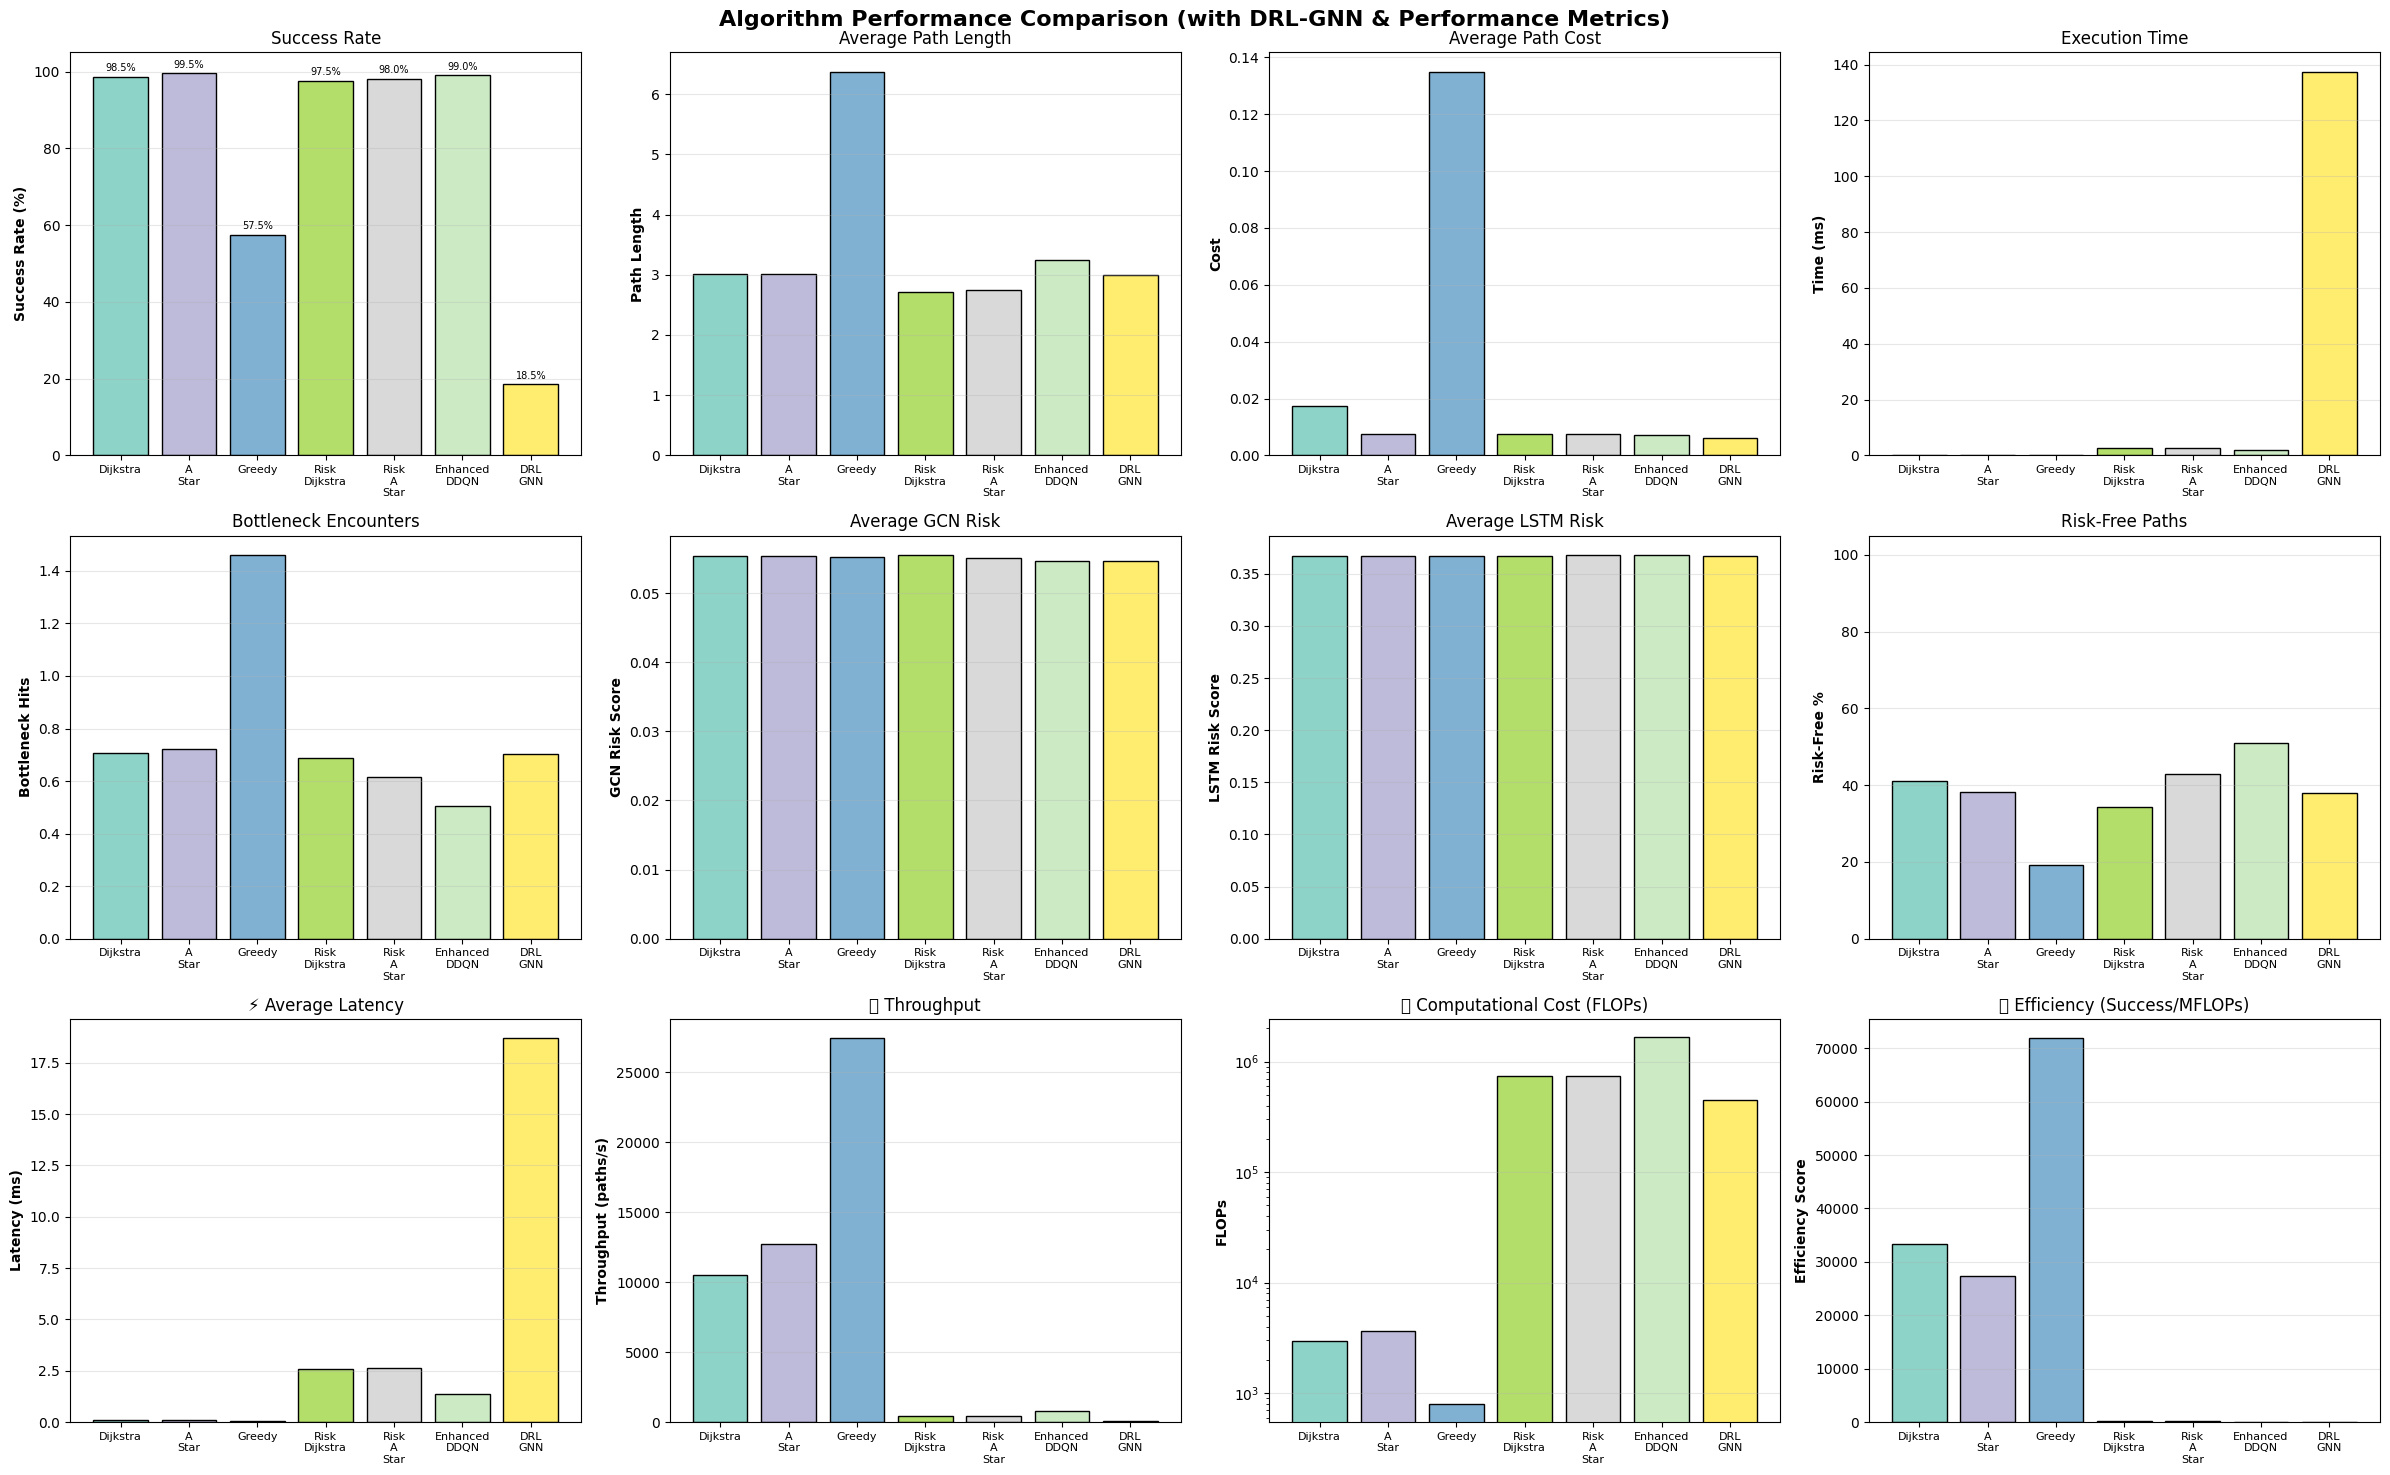

✓ Results exported to: /content/algorithm_comparison_enhanced.csv

ENHANCED COMPARISON COMPLETE

 Key Insights:
  • Dijkstra/A*: Optimal cost but ignores risks
  • Risk-aware variants: Balance cost vs safety using GCN
  • Enhanced DDQN: Learns adaptive risk-reward tradeoffs
  • DRL-GNN: Paper baseline with MPNN architecture
  • Greedy: Fast but suboptimal and risky

 New Performance Metrics:
  • Latency: Measures per-path response time
  • Throughput: Paths processed per second
  • FLOPs: Computational efficiency comparison

 Output Files:
  • Enhanced plot: /content/algorithm_comparison_enhanced.png
  • Enhanced CSV: /content/algorithm_comparison_enhanced.csv

DETAILED PERFORMANCE ANALYSIS (ALL ALGORITHMS)

Dijkstra:
  Success Rate: 98.5%
  Avg Path: 3.01 ± 0.94 nodes
  Avg Cost: 0.0173 ± 0.1627
  Avg Time: 0.10 ms
  Safety Metrics:
    - Bottleneck Hits: 0.71
    - GCN Risk: 0.0553
    - LSTM Risk: 0.3675
    - Risk-Free Paths: 41.1%
  Performance Metrics:
    - Latency: 0.10 ms
    

In [ ]:
import torch
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.notebook import tqdm
import pandas as pd
import logging
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ============================================================================
# CONFIGURATION
# ============================================================================

EVAL_CONFIG = {
    'max_steps': 20,
    'gcn_risk_weight_multiplier': 1000,
    'risk_weight_default': 5.0,
    'save_dir': os.getenv('EVAL_SAVE_DIR', '/content'),
}

# ============================================================================
# BASELINE ALGORITHMS IMPLEMENTATION
# ============================================================================

class BaselineAlgorithms:
    """Collection of baseline pathfinding algorithms for comparison"""

    @staticmethod
    def dijkstra(env, source, target):
        """Standard Dijkstra's shortest path"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        try:
            path_names = nx.dijkstra_path(G, source_name, target_name, weight='weight')
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"Dijkstra failed: {e}")
            return None, float('inf'), False

    @staticmethod
    def astar(env, source, target):
        """A* algorithm with heuristic"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        def heuristic(u, v):
            u_idx = env.current_graph.node_to_idx.get(u, 0)
            v_idx = env.current_graph.node_to_idx.get(v, 0)
            return abs(u_idx - v_idx)

        try:
            path_names = nx.astar_path(G, source_name, target_name,
                                      heuristic=heuristic, weight='weight')
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"A* failed: {e}")
            return None, float('inf'), False

    @staticmethod
    def greedy_best_first(env, source, target, max_steps=20):
        """Greedy algorithm - always moves to lowest cost neighbor"""
        G = env.current_graph.networkx_graph
        current = source
        path = [current]
        visited = set([current])
        total_cost = 0

        for _ in range(max_steps):
            if current == target:
                return path, total_cost, True

            current_name = env.current_graph.idx_to_node[current]
            neighbors = list(G.successors(current_name))

            if not neighbors:
                return None, float('inf'), False

            best_neighbor = None
            best_cost = float('inf')

            for neighbor_name in neighbors:
                neighbor_idx = env.current_graph.node_to_idx[neighbor_name]
                if neighbor_idx not in visited:
                    edge_cost = G[current_name][neighbor_name]['weight']
                    if edge_cost < best_cost:
                        best_cost = edge_cost
                        best_neighbor = neighbor_idx

            if best_neighbor is None:
                neighbor_name = neighbors[0]
                best_neighbor = env.current_graph.node_to_idx[neighbor_name]
                best_cost = G[current_name][neighbor_name]['weight']

            path.append(best_neighbor)
            visited.add(best_neighbor)
            total_cost += best_cost
            current = best_neighbor

        return None, float('inf'), False


# ============================================================================
# RISK-AWARE BASELINE ALGORITHMS
# ============================================================================

class RiskAwareBaselines:
    """Baseline algorithms enhanced with GCN risk awareness"""

    @staticmethod
    def _compute_gcn_risks(env, gcn_model):
        """Helper to compute GCN risks once"""
        gcn_risks = {}
        if gcn_model is not None:
            try:
                with torch.no_grad():
                    x = env.current_graph.x[:, :12].to(device)
                    edge_index = env.current_graph.edge_index.to(device)
                    features = gcn_model(x, edge_index)

                    if hasattr(gcn_model, 'lin'):
                        logits = gcn_model.lin(features)
                        probs = torch.softmax(logits, dim=1)[:, 1]
                    elif hasattr(gcn_model, 'classifier'):
                        logits = gcn_model.classifier(features)
                        probs = torch.softmax(logits, dim=1)[:, 1]
                    elif hasattr(gcn_model, 'predict_bottlenecks'):
                        probs = gcn_model.predict_bottlenecks(x, edge_index)
                    else:
                        probs = torch.zeros(features.shape[0]).to(device)

                    gcn_risks = {i: float(probs[i].item()) for i in range(env.current_graph.num_nodes)}
            except Exception as e:
                logger.warning(f"GCN risk computation failed: {e}")
        return gcn_risks

    @staticmethod
    def risk_aware_dijkstra(env, source, target, gcn_model=None, risk_weight=5.0):
        """Dijkstra with GCN risk penalties"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        gcn_risks = RiskAwareBaselines._compute_gcn_risks(env, gcn_model)

        def weight_function(u, v, d):
            v_idx = env.current_graph.node_to_idx[v]
            base_weight = d['weight']
            risk_penalty = gcn_risks.get(v_idx, 0.0) * risk_weight * EVAL_CONFIG['gcn_risk_weight_multiplier']
            return base_weight + risk_penalty

        try:
            path_names = nx.dijkstra_path(G, source_name, target_name, weight=weight_function)
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"Risk-aware Dijkstra failed: {e}")
            return None, float('inf'), False

    @staticmethod
    def risk_aware_astar(env, source, target, gcn_model=None, risk_weight=5.0):
        """A* with GCN risk penalties"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        gcn_risks = RiskAwareBaselines._compute_gcn_risks(env, gcn_model)

        def weight_function(u, v, d):
            v_idx = env.current_graph.node_to_idx[v]
            base_weight = d['weight']
            risk_penalty = gcn_risks.get(v_idx, 0.0) * risk_weight * EVAL_CONFIG['gcn_risk_weight_multiplier']
            return base_weight + risk_penalty

        def heuristic(u, v):
            u_idx = env.current_graph.node_to_idx.get(u, 0)
            v_idx = env.current_graph.node_to_idx.get(v, 0)
            return abs(u_idx - v_idx)

        try:
            path_names = nx.astar_path(G, source_name, target_name,
                                      heuristic=heuristic, weight=weight_function)
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"Risk-aware A* failed: {e}")
            return None, float('inf'), False


# ============================================================================
# NEW: FLOPS COUNTER
# ============================================================================

class FLOPsCounter:
    """Count FLOPs for different algorithm operations"""

    @staticmethod
    def count_gcn_forward(gcn_model, num_nodes, num_edges):
        """Estimate FLOPs for GCN forward pass"""
        if gcn_model is None:
            return 0

        flops = 0
        # Input projection (assume 12 -> 64)
        flops += num_nodes * 12 * 64 * 2  # MatMul + bias

        # GCN layers (assume 2 layers, 64 -> 64)
        for _ in range(2):
            flops += num_edges * 64 * 2  # Message passing
            flops += num_nodes * 64 * 64 * 2  # Transformation

        # Classifier (64 -> 2)
        flops += num_nodes * 64 * 2 * 2

        return flops

    @staticmethod
    def count_lstm_forward(lstm_model, seq_len=10, hidden_dim=64):
        """Estimate FLOPs for LSTM forward pass"""
        if lstm_model is None:
            return 0

        # LSTM: 4 gates × (input_dim × hidden + hidden × hidden) × 2 (MAC)
        flops = seq_len * 4 * (hidden_dim * hidden_dim + hidden_dim * hidden_dim) * 2

        # Classifier (assume 64 -> 2)
        flops += hidden_dim * 2 * 2

        return flops

    @staticmethod
    def count_graph_ops(num_nodes, num_edges, algorithm_type):
        """Estimate FLOPs for graph algorithm operations"""
        if algorithm_type in ['Dijkstra', 'Risk_Dijkstra']:
            # Dijkstra: O(E log V) comparisons + priority queue ops
            return int(num_edges * np.log2(max(num_nodes, 2)) * 10)

        elif algorithm_type in ['A_Star', 'Risk_A_Star']:
            # A*: Similar to Dijkstra + heuristic computations
            return int(num_edges * np.log2(max(num_nodes, 2)) * 12)

        elif algorithm_type == 'Greedy':
            # Greedy: O(V) neighbor comparisons
            return int(num_nodes * 20)

        elif algorithm_type == 'Enhanced_DDQN':
            # DQN: GCN + value network forward passes
            return 0  # Will be computed separately

        elif algorithm_type == 'DRL_GNN':
            # DRL-GNN: MPNN forward passes
            return 0  # Will be computed separately

        return 0


# ============================================================================
# COMPREHENSIVE COMPARISON FRAMEWORK (ENHANCED)
# ============================================================================

class AlgorithmComparison:
    """Complete comparison framework for all algorithms"""

    def __init__(self, test_env, trained_agent, gcn_model=None, lstm_model=None, drl_gnn_agent=None):
        self.env = test_env
        self.agent = trained_agent
        self.gcn_model = gcn_model
        self.lstm_model = lstm_model
        self.drl_gnn_agent = drl_gnn_agent  # NEW: DRL-GNN agent
        self.baseline = BaselineAlgorithms()
        self.risk_aware = RiskAwareBaselines()
        self.flops_counter = FLOPsCounter()

    def compute_lstm_risk(self, path):
        """Compute LSTM risk using proper 64-dim GCN features"""
        if self.lstm_model is None or self.gcn_model is None or len(path) < 2:
            return 0.0

        try:
            with torch.no_grad():
                x = self.env.current_graph.x[:, :12].to(device)
                edge_index = self.env.current_graph.edge_index.to(device)
                gcn_features = self.gcn_model(x, edge_index)

                path_seq = path[-10:]
                if len(path_seq) < 10:
                    path_seq = [path_seq[0]] * (10 - len(path_seq)) + path_seq

                seq = torch.stack([gcn_features[n] for n in path_seq]).unsqueeze(0)
                features = self.lstm_model(seq)

                if hasattr(self.lstm_model, 'classifier'):
                    logits = self.lstm_model.classifier(features)
                    risk_probs = torch.softmax(logits, dim=1)
                    risk = float(risk_probs[:, 1].item())
                else:
                    risk = 0.0

                return risk
        except Exception as e:
            logger.debug(f"LSTM risk computation failed: {e}")
            return 0.0

    def compute_gcn_risk(self, path):
        """Compute average GCN risk for a path"""
        if self.gcn_model is None or len(path) == 0:
            return 0.0

        try:
            with torch.no_grad():
                x = self.env.current_graph.x[:, :12].to(device)
                edge_index = self.env.current_graph.edge_index.to(device)
                features = self.gcn_model(x, edge_index)

                if hasattr(self.gcn_model, 'lin'):
                    logits = self.gcn_model.lin(features)
                    probs = torch.softmax(logits, dim=1)[:, 1]
                elif hasattr(self.gcn_model, 'classifier'):
                    logits = self.gcn_model.classifier(features)
                    probs = torch.softmax(logits, dim=1)[:, 1]
                elif hasattr(self.gcn_model, 'predict_bottlenecks'):
                    probs = self.gcn_model.predict_bottlenecks(x, edge_index)
                else:
                    return 0.0

                gcn_risk = sum(float(probs[node].item()) for node in path) / len(path)
                return gcn_risk
        except Exception as e:
            logger.debug(f"GCN risk computation failed: {e}")
            return 0.0

    def run_episode(self, algorithm_name, max_steps=None):
        """Run single episode with specified algorithm - ENHANCED with new metrics"""
        if max_steps is None:
            max_steps = EVAL_CONFIG['max_steps']

        try:
            obs, _ = self.env.reset()

            if algorithm_name == 'Enhanced_DDQN':
                self.agent.set_pathfinder(self.env)

            source = self.env.current_node
            target = self.env.target_node
            start_time = time.perf_counter()  # High-precision timing

            # NEW: FLOPs tracking
            total_flops = 0

            path = None
            cost = float('inf')
            success = False

            # Get path from algorithm
            if algorithm_name == 'Dijkstra':
                path, cost, success = self.baseline.dijkstra(self.env, source, target)
                total_flops = self.flops_counter.count_graph_ops(
                    self.env.current_graph.num_nodes,
                    self.env.current_graph.edge_index.shape[1],
                    'Dijkstra'
                )

            elif algorithm_name == 'A_Star':
                path, cost, success = self.baseline.astar(self.env, source, target)
                total_flops = self.flops_counter.count_graph_ops(
                    self.env.current_graph.num_nodes,
                    self.env.current_graph.edge_index.shape[1],
                    'A_Star'
                )

            elif algorithm_name == 'Greedy':
                path, cost, success = self.baseline.greedy_best_first(self.env, source, target, max_steps)
                total_flops = self.flops_counter.count_graph_ops(
                    self.env.current_graph.num_nodes,
                    self.env.current_graph.edge_index.shape[1],
                    'Greedy'
                )

            elif algorithm_name == 'Risk_Dijkstra':
                path, cost, success = self.risk_aware.risk_aware_dijkstra(
                    self.env, source, target, self.gcn_model, risk_weight=EVAL_CONFIG['risk_weight_default']
                )
                total_flops = (
                    self.flops_counter.count_gcn_forward(
                        self.gcn_model,
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1]
                    ) +
                    self.flops_counter.count_graph_ops(
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1],
                        'Risk_Dijkstra'
                    )
                )

            elif algorithm_name == 'Risk_A_Star':
                path, cost, success = self.risk_aware.risk_aware_astar(
                    self.env, source, target, self.gcn_model, risk_weight=EVAL_CONFIG['risk_weight_default']
                )
                total_flops = (
                    self.flops_counter.count_gcn_forward(
                        self.gcn_model,
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1]
                    ) +
                    self.flops_counter.count_graph_ops(
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1],
                        'Risk_A_Star'
                    )
                )

            elif algorithm_name == 'Enhanced_DDQN':
                path = [source]
                done = False
                success = False
                steps = 0
                cost = 0

                while not done and steps < max_steps:
                    try:
                        G = self.env.current_graph.networkx_graph
                        current_name = self.env.current_graph.idx_to_node[self.env.current_node]
                        valid_actions = [self.env.current_graph.node_to_idx[n]
                                       for n in G.successors(current_name)]

                        if not valid_actions:
                            success = False
                            break

                        action = self.agent.select_action_with_sssp(obs, self.env, valid_actions)

                        # Count FLOPs for this step
                        total_flops += self.flops_counter.count_gcn_forward(
                            self.gcn_model,
                            self.env.current_graph.num_nodes,
                            self.env.current_graph.edge_index.shape[1]
                        )

                        if action != self.env.current_node:
                            prev_name = current_name
                            next_name = self.env.current_graph.idx_to_node[action]
                            if G.has_edge(prev_name, next_name):
                                cost += G[prev_name][next_name]['weight']

                        next_obs, _, done, truncated, info = self.env.step(action)
                        path.append(self.env.current_node)

                        obs = next_obs
                        steps += 1

                        if done or truncated:
                            success = info.get('success', False)
                            break
                    except Exception as e:
                        logger.error(f"DDQN step failed: {e}")
                        success = False
                        break

                if not done and steps >= max_steps:
                    success = False

            # NEW: DRL-GNN algorithm
            elif algorithm_name == 'DRL_GNN':
                # Check if DRL-GNN agent is available and properly initialized
                if self.drl_gnn_agent is None:
                    # Only log once per run (not per episode)
                    if not hasattr(self, '_drl_gnn_warning_shown'):
                        logger.info("DRL-GNN agent not available - skipping all DRL-GNN episodes")
                        self._drl_gnn_warning_shown = True
                    return {
                        'success': False, 'path_length': 0, 'cost': float('inf'),
                        'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                        'lstm_risk': 0.0, 'risk_free': False,
                        'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
                    }

                # Check if it has the env_adapter attribute (from DRL-GNN training code)
                if not hasattr(self.drl_gnn_agent, 'env_adapter'):
                    if not hasattr(self, '_drl_gnn_adapter_warning_shown'):
                        logger.info("DRL-GNN agent missing env_adapter - not a trained DRL-GNN agent")
                        self._drl_gnn_adapter_warning_shown = True
                    return {
                        'success': False, 'path_length': 0, 'cost': float('inf'),
                        'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                        'lstm_risk': 0.0, 'risk_free': False,
                        'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
                    }

                path = [source]
                done = False
                success = False
                steps = 0
                cost = 0

                # FIX: Properly reset DRL-GNN's adapter to match current environment state
                try:
                    # Make sure adapter is using the correct environment instance
                    self.drl_gnn_agent.env_adapter.env = self.env

                    # CRITICAL FIX: Manually set the current state to match the reset env
                    self.drl_gnn_agent.env_adapter.current_node = source
                    self.drl_gnn_agent.env_adapter.target_node = target

                except Exception as e:
                    if not hasattr(self, '_drl_gnn_init_warning_shown'):
                        logger.error(f"Failed to initialize DRL-GNN adapter: {e}")
                        self._drl_gnn_init_warning_shown = True
                    return {
                        'success': False, 'path_length': 0, 'cost': float('inf'),
                        'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                        'lstm_risk': 0.0, 'risk_free': False,
                        'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
                    }

                while not done and steps < max_steps:
                    try:
                        # Get action from DRL-GNN
                        action, state_graph = self.drl_gnn_agent.act(None, flag_evaluation=True)

                        if action is None:
                            success = False
                            break

                        # Count FLOPs for MPNN forward pass
                        if state_graph:
                            node_features, edge_index, num_nodes = state_graph
                            # MPNN FLOPs (Message + Update + Readout)
                            T = 4  # Message passing iterations
                            link_dim = 20
                            total_flops += (
                                num_nodes * 12 * link_dim * 2 +  # Input projection
                                T * edge_index.shape[1] * link_dim * 2 * 2 +  # Messages
                                T * num_nodes * link_dim * link_dim * 2 +  # Updates
                                num_nodes * link_dim * 35 * 2 +  # Readout layer 1
                                35 * 35 * 2 +  # Readout layer 2
                                35 * 1 * 2  # Readout layer 3
                            )

                        # FIX: Execute action in BOTH environments consistently
                        # Step in main environment
                        next_obs, step_reward, terminated, truncated, info = self.env.step(action)
                        done = terminated or truncated

                        # Calculate cost from main environment
                        G = self.env.current_graph.networkx_graph
                        if len(path) > 0:
                            prev_node = path[-1]
                            prev_name = self.env.current_graph.idx_to_node[prev_node]
                            next_name = self.env.current_graph.idx_to_node[action]
                            if G.has_edge(prev_name, next_name):
                                cost += G[prev_name][next_name]['weight']

                        # Update DRL-GNN adapter state to stay in sync
                        if 'current_node' in info:
                            self.drl_gnn_agent.env_adapter.current_node = info['current_node']

                        path.append(action)
                        steps += 1

                        if done:
                            success = info.get('success', False)
                            break

                    except Exception as e:
                        logger.error(f"DRL-GNN step failed at step {steps}: {e}")
                        success = False
                        break

                if not done and steps >= max_steps:
                    success = False

            else:
                raise ValueError(f"Unknown algorithm: {algorithm_name}")

            exec_time = (time.perf_counter() - start_time) * 1000  # ms

            # NEW: Calculate additional metrics
            latency_ms = exec_time  # Per-path latency
            throughput = (1000.0 / exec_time) if exec_time > 0 else 0.0  # Paths per second

            # Calculate existing metrics
            if path and success:
                bottleneck_hits = sum(1 for node in path if node in self.env.bottleneck_nodes)
                gcn_risk = self.compute_gcn_risk(path)
                lstm_risk = self.compute_lstm_risk(path)

                return {
                    'success': True,
                    'path_length': len(path),
                    'cost': cost / 1000.0,
                    'time_ms': exec_time,
                    'bottleneck_hits': bottleneck_hits,
                    'gcn_risk': gcn_risk,
                    'lstm_risk': lstm_risk,
                    'risk_free': bottleneck_hits == 0,
                    # NEW metrics
                    'latency_ms': latency_ms,
                    'throughput': throughput,
                    'flops': total_flops
                }
            else:
                return {
                    'success': False,
                    'path_length': 0,
                    'cost': float('inf'),
                    'time_ms': exec_time,
                    'bottleneck_hits': 0,
                    'gcn_risk': 0.0,
                    'lstm_risk': 0.0,
                    'risk_free': False,
                    # NEW metrics
                    'latency_ms': latency_ms,
                    'throughput': 0.0,
                    'flops': total_flops
                }

        except Exception as e:
            logger.error(f"Error in {algorithm_name}: {e}", exc_info=True)
            return {
                'success': False, 'path_length': 0, 'cost': float('inf'),
                'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                'lstm_risk': 0.0, 'risk_free': False,
                'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
            }

    def compare_algorithms(self, num_episodes=200):
        """Compare all algorithms over multiple episodes - NOW WITH DRL-GNN"""
        algorithms = [
            'Dijkstra',
            'A_Star',
            'Greedy',
            'Risk_Dijkstra',
            'Risk_A_Star',
            'Enhanced_DDQN',
            'DRL_GNN'  # NEW
        ]

        results = {alg: [] for alg in algorithms}
        failed_counts = {alg: 0 for alg in algorithms}

        print("=" * 80)
        print("RUNNING ALGORITHM COMPARISON (WITH DRL-GNN + PERFORMANCE METRICS)")
        print("=" * 80)
        print(f"Testing {len(algorithms)} algorithms on {num_episodes} episodes\n")

        for alg in algorithms:
            print(f"\n{alg:20s} ", end='', flush=True)

            for ep in tqdm(range(num_episodes), desc=alg, leave=False):
                result = self.run_episode(alg)
                results[alg].append(result)

                if not result['success']:
                    failed_counts[alg] += 1

            successes = sum(1 for r in results[alg] if r['success'])
            print(f"✓ Complete - Success: {successes}/{num_episodes} ({100*successes/num_episodes:.1f}%)")

            if failed_counts[alg] > 0:
                logger.info(f"  {alg}: {failed_counts[alg]} failures")

        return self._compute_statistics(results)

    def _compute_statistics(self, results):
        """Compute comprehensive statistics for all algorithms - ENHANCED"""
        stats = {}

        for alg, episodes in results.items():
            successful = [e for e in episodes if e['success']]

            if successful:
                valid_costs = [e['cost'] for e in successful if e['cost'] != float('inf')]

                stats[alg] = {
                    # Existing metrics (UNCHANGED)
                    'success_rate': len(successful) / len(episodes) * 100,
                    'avg_path_length': np.mean([e['path_length'] for e in successful]),
                    'std_path_length': np.std([e['path_length'] for e in successful]),
                    'avg_cost': np.mean(valid_costs) if valid_costs else 0.0,
                    'std_cost': np.std(valid_costs) if valid_costs else 0.0,
                    'avg_time_ms': np.mean([e['time_ms'] for e in episodes]),
                    'avg_bottleneck_hits': np.mean([e['bottleneck_hits'] for e in successful]),
                    'avg_gcn_risk': np.mean([e['gcn_risk'] for e in successful]),
                    'avg_lstm_risk': np.mean([e['lstm_risk'] for e in successful]),
                    'risk_free_paths': sum(1 for e in successful if e['risk_free']) / len(successful) * 100,
                    'total_episodes': len(episodes),
                    'successful_episodes': len(successful),
                    # NEW metrics
                    'avg_latency_ms': np.mean([e['latency_ms'] for e in successful]),
                    'avg_throughput': np.mean([e['throughput'] for e in successful]),
                    'avg_flops': np.mean([e['flops'] for e in successful])
                }
            else:
                stats[alg] = {
                    'success_rate': 0.0,
                    'avg_path_length': 0.0,
                    'std_path_length': 0.0,
                    'avg_cost': 0.0,
                    'std_cost': 0.0,
                    'avg_time_ms': np.mean([e['time_ms'] for e in episodes]) if episodes else 0.0,
                    'avg_bottleneck_hits': 0.0,
                    'avg_gcn_risk': 0.0,
                    'avg_lstm_risk': 0.0,
                    'risk_free_paths': 0.0,
                    'total_episodes': len(episodes),
                    'successful_episodes': 0,
                    'avg_latency_ms': 0.0,
                    'avg_throughput': 0.0,
                    'avg_flops': 0.0
                }

        return stats

    def print_comparison_table(self, stats):
        """Print comprehensive comparison table - ENHANCED"""
        print("\n" + "=" * 150)
        print("ALGORITHM COMPARISON RESULTS (WITH DRL-GNN + PERFORMANCE METRICS)")
        print("=" * 150)

        df_data = []
        for alg, metrics in stats.items():
            df_data.append({
                'Algorithm': alg.replace('_', ' '),
                'Success %': f"{metrics['success_rate']:.1f}",
                'Path Len': f"{metrics['avg_path_length']:.2f}±{metrics['std_path_length']:.2f}",
                'Cost': f"{metrics['avg_cost']:.4f}",
                'Time (ms)': f"{metrics['avg_time_ms']:.2f}",
                'BN Hits': f"{metrics['avg_bottleneck_hits']:.2f}",
                'GCN Risk': f"{metrics['avg_gcn_risk']:.4f}",
                'LSTM Risk': f"{metrics['avg_lstm_risk']:.4f}",
                'Risk-Free %': f"{metrics['risk_free_paths']:.1f}",
                # NEW columns
                'Latency (ms)': f"{metrics['avg_latency_ms']:.2f}",
                'Throughput': f"{metrics['avg_throughput']:.1f}",
                'FLOPs': f"{metrics['avg_flops']:.2e}"
            })

        df = pd.DataFrame(df_data)
        print(df.to_string(index=False))
        print("=" * 150)

        print("\n CATEGORY WINNERS:")
        print("-" * 100)

        best_success = max(stats.items(), key=lambda x: x[1]['success_rate'])
        print(f"  Best Success Rate:     {best_success[0].replace('_', ' '):20s} ({best_success[1]['success_rate']:.1f}%)")

        successful_algs = {k: v for k, v in stats.items() if v['successful_episodes'] > 0}
        if successful_algs:
            best_path = min(successful_algs.items(), key=lambda x: x[1]['avg_path_length'])
            print(f"  Shortest Path:         {best_path[0].replace('_', ' '):20s} ({best_path[1]['avg_path_length']:.2f} nodes)")

            best_cost = min(successful_algs.items(), key=lambda x: x[1]['avg_cost'])
            print(f"  Lowest Cost:           {best_cost[0].replace('_', ' '):20s} ({best_cost[1]['avg_cost']:.4f})")

            best_time = min(successful_algs.items(), key=lambda x: x[1]['avg_time_ms'])
            print(f"  Fastest:               {best_time[0].replace('_', ' '):20s} ({best_time[1]['avg_time_ms']:.2f} ms)")

            best_safe = min(successful_algs.items(), key=lambda x: x[1]['avg_bottleneck_hits'])
            print(f"  Safest (BN):           {best_safe[0].replace('_', ' '):20s} ({best_safe[1]['avg_bottleneck_hits']:.2f} hits)")

            best_gcn = min(successful_algs.items(), key=lambda x: x[1]['avg_gcn_risk'])
            print(f"  Lowest GCN Risk:       {best_gcn[0].replace('_', ' '):20s} ({best_gcn[1]['avg_gcn_risk']:.4f})")

            best_lstm = min(successful_algs.items(), key=lambda x: x[1]['avg_lstm_risk'])
            print(f"  Lowest LSTM Risk:      {best_lstm[0].replace('_', ' '):20s} ({best_lstm[1]['avg_lstm_risk']:.4f})")

            best_rf = max(successful_algs.items(), key=lambda x: x[1]['risk_free_paths'])
            print(f"  Most Risk-Free:        {best_rf[0].replace('_', ' '):20s} ({best_rf[1]['risk_free_paths']:.1f}%)")

            # NEW winners
            best_latency = min(successful_algs.items(), key=lambda x: x[1]['avg_latency_ms'])
            print(f"  Lowest Latency:        {best_latency[0].replace('_', ' '):20s} ({best_latency[1]['avg_latency_ms']:.2f} ms)")

            best_throughput = max(successful_algs.items(), key=lambda x: x[1]['avg_throughput'])
            print(f"  Highest Throughput:    {best_throughput[0].replace('_', ' '):20s} ({best_throughput[1]['avg_throughput']:.1f} paths/s)")

            best_efficiency = min(successful_algs.items(), key=lambda x: x[1]['avg_flops'])
            print(f"  Most Efficient (FLOPs):{best_efficiency[0].replace('_', ' '):20s} ({best_efficiency[1]['avg_flops']:.2e})")

        print("-" * 100)

    def plot_comparison(self, stats, save_path=None):
        """Create comprehensive comparison visualizations - ENHANCED"""
        fig, axes = plt.subplots(3, 4, figsize=(24, 15))
        fig.suptitle('Algorithm Performance Comparison (with DRL-GNN & Performance Metrics)',
                     fontsize=16, fontweight='bold')

        algorithms = list(stats.keys())
        colors = plt.cm.Set3(np.linspace(0, 1, len(algorithms)))

        # Row 1: Original metrics (UNCHANGED)
        # 1. Success Rate
        ax = axes[0, 0]
        success_rates = [stats[alg]['success_rate'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), success_rates, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Success Rate (%)', fontweight='bold')
        ax.set_title('Success Rate')
        ax.set_ylim([0, 105])
        ax.grid(axis='y', alpha=0.3)
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{success_rates[i]:.1f}%', ha='center', va='bottom', fontsize=7)

        # 2. Path Length
        ax = axes[0, 1]
        path_lens = [stats[alg]['avg_path_length'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), path_lens, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Path Length', fontweight='bold')
        ax.set_title('Average Path Length')
        ax.grid(axis='y', alpha=0.3)

        # 3. Cost
        ax = axes[0, 2]
        costs = [stats[alg]['avg_cost'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), costs, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Cost', fontweight='bold')
        ax.set_title('Average Path Cost')
        ax.grid(axis='y', alpha=0.3)

        # 4. Execution Time
        ax = axes[0, 3]
        times = [stats[alg]['avg_time_ms'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), times, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Time (ms)', fontweight='bold')
        ax.set_title('Execution Time')
        ax.grid(axis='y', alpha=0.3)

        # Row 2: Risk metrics (UNCHANGED)
        # 5. Bottleneck Hits
        ax = axes[1, 0]
        bn_hits = [stats[alg]['avg_bottleneck_hits'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), bn_hits, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Bottleneck Hits', fontweight='bold')
        ax.set_title('Bottleneck Encounters')
        ax.grid(axis='y', alpha=0.3)

        # 6. GCN Risk
        ax = axes[1, 1]
        gcn_risks = [stats[alg]['avg_gcn_risk'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), gcn_risks, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('GCN Risk Score', fontweight='bold')
        ax.set_title('Average GCN Risk')
        ax.grid(axis='y', alpha=0.3)

        # 7. LSTM Risk
        ax = axes[1, 2]
        lstm_risks = [stats[alg]['avg_lstm_risk'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), lstm_risks, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('LSTM Risk Score', fontweight='bold')
        ax.set_title('Average LSTM Risk')
        ax.grid(axis='y', alpha=0.3)

        # 8. Risk-Free Paths
        ax = axes[1, 3]
        rf_pct = [stats[alg]['risk_free_paths'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), rf_pct, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Risk-Free %', fontweight='bold')
        ax.set_title('Risk-Free Paths')
        ax.set_ylim([0, 105])
        ax.grid(axis='y', alpha=0.3)

        # Row 3: NEW performance metrics
        # 9. Latency
        ax = axes[2, 0]
        latencies = [stats[alg]['avg_latency_ms'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), latencies, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Latency (ms)', fontweight='bold')
        ax.set_title('⚡ Average Latency')
        ax.grid(axis='y', alpha=0.3)

        # 10. Throughput
        ax = axes[2, 1]
        throughputs = [stats[alg]['avg_throughput'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), throughputs, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Throughput (paths/s)', fontweight='bold')
        ax.set_title(' Throughput')
        ax.grid(axis='y', alpha=0.3)

        # 11. FLOPs (log scale)
        ax = axes[2, 2]
        flops = [stats[alg]['avg_flops'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), flops, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('FLOPs', fontweight='bold')
        ax.set_title(' Computational Cost (FLOPs)')
        ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3)

        # 12. Efficiency Score (Success Rate / FLOPs)
        ax = axes[2, 3]
        efficiency = []
        for alg in algorithms:
            if stats[alg]['avg_flops'] > 0:
                eff = stats[alg]['success_rate'] / (stats[alg]['avg_flops'] / 1e6)
            else:
                eff = stats[alg]['success_rate']
            efficiency.append(eff)
        bars = ax.bar(range(len(algorithms)), efficiency, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Efficiency Score', fontweight='bold')
        ax.set_title('🎯 Efficiency (Success/MFLOPs)')
        ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logger.info(f"Comparison plot saved to: {save_path}")
            print(f"\n✓ Comparison plot saved to: {save_path}")

        plt.show()
        return fig

    def export_results_csv(self, stats, filepath=None):
        """Export results to CSV for further analysis - ENHANCED"""
        if filepath is None:
            filepath = os.path.join(EVAL_CONFIG['save_dir'], 'algorithm_comparison_enhanced.csv')

        df_data = []
        for alg, metrics in stats.items():
            df_data.append({
                'Algorithm': alg.replace('_', ' '),
                'Success_Rate': metrics['success_rate'],
                'Avg_Path_Length': metrics['avg_path_length'],
                'Std_Path_Length': metrics['std_path_length'],
                'Avg_Cost': metrics['avg_cost'],
                'Std_Cost': metrics['std_cost'],
                'Avg_Time_ms': metrics['avg_time_ms'],
                'Avg_Bottleneck_Hits': metrics['avg_bottleneck_hits'],
                'Avg_GCN_Risk': metrics['avg_gcn_risk'],
                'Avg_LSTM_Risk': metrics['avg_lstm_risk'],
                'Risk_Free_Paths_Pct': metrics['risk_free_paths'],
                'Total_Episodes': metrics['total_episodes'],
                'Successful_Episodes': metrics['successful_episodes'],
                # NEW columns
                'Avg_Latency_ms': metrics['avg_latency_ms'],
                'Avg_Throughput': metrics['avg_throughput'],
                'Avg_FLOPs': metrics['avg_flops']
            })

        df = pd.DataFrame(df_data)
        df.to_csv(filepath, index=False)
        logger.info(f"Results exported to: {filepath}")
        print(f"✓ Results exported to: {filepath}")
        return df


# ============================================================================
# MAIN COMPARISON EXECUTION
# ============================================================================

print("=" * 80)
print("INITIALIZING ENHANCED ALGORITHM COMPARISON")
print("=" * 80)

# ============================================================================
# AUTO-LOAD DRL-GNN AGENT FROM CHECKPOINT
# ============================================================================


def load_drl_gnn_agent_fixed(test_env):
    """
    Load trained DRL-GNN agent with FIXED adapter that properly syncs state.
    """
    try:
        import torch.nn as nn
        import torch.nn.functional as F
        from collections import deque

        checkpoint_dir = "./models_DRL_GNN_Baseline_Temporal"
        if not os.path.exists(checkpoint_dir):
            print("\n⚠ DRL-GNN checkpoint directory not found")
            return None

        checkpoints = [f for f in os.listdir(checkpoint_dir) if f.startswith('ckpt-')]
        if not checkpoints:
            print("\n⚠ No DRL-GNN checkpoints found")
            return None

        checkpoint_nums = [int(f.split('-')[1]) for f in checkpoints]
        best_ckpt_num = max(checkpoint_nums)
        checkpoint_path = os.path.join(checkpoint_dir, f'ckpt-{best_ckpt_num}')

        print(f"\n🔄 Loading DRL-GNN agent from: {checkpoint_path}")

        # Define FIXED architecture
        class ExactMPNN(nn.Module):
            def __init__(self, hparams, input_dim):
                super(ExactMPNN, self).__init__()
                self.hparams = hparams
                self.Message = nn.Sequential(
                    nn.Linear(hparams['link_state_dim'] * 2, hparams['link_state_dim']),
                    nn.SELU()
                )
                self.Update = nn.GRUCell(hparams['link_state_dim'], hparams['link_state_dim'])
                self.Readout = nn.Sequential(
                    nn.Linear(hparams['link_state_dim'], hparams['readout_units']),
                    nn.SELU(),
                    nn.Dropout(hparams['dropout_rate']),
                    nn.Linear(hparams['readout_units'], hparams['readout_units']),
                    nn.SELU(),
                    nn.Dropout(hparams['dropout_rate']),
                    nn.Linear(hparams['readout_units'], 1)
                )
                self.InputProjection = nn.Linear(input_dim, hparams['link_state_dim'])

            def forward(self, node_features, edge_index, num_nodes, training=False):
                link_state = self.InputProjection(node_features)
                sources = edge_index[0]
                targets = edge_index[1]

                for t in range(self.hparams['T']):
                    src_feats = link_state[sources]
                    tgt_feats = link_state[targets]
                    concat_feats = torch.cat([src_feats, tgt_feats], dim=1)
                    messages = self.Message(concat_feats)

                    aggregated = torch.zeros(num_nodes, self.hparams['link_state_dim'],
                                           dtype=link_state.dtype, device=link_state.device)
                    aggregated.scatter_add_(0, targets.unsqueeze(1).expand(-1, self.hparams['link_state_dim']), messages)
                    link_state = self.Update(aggregated, link_state)

                graph_embedding = torch.sum(link_state, dim=0, keepdim=True)
                if training:
                    self.Readout.train()
                else:
                    self.Readout.eval()
                q_value = self.Readout(graph_embedding)
                return q_value

        # CRITICAL FIX: Proper adapter with state synchronization
        class EnvironmentAdapterFixed:
            def __init__(self, env):
                self.env = env
                self.current_node = None
                self.target_node = None

            def reset(self):
                obs, info = self.env.reset()
                # CRITICAL: Always sync from environment
                self.current_node = self.env.current_node
                self.target_node = self.env.target_node
                return obs, info

            def get_graph_for_action(self, action):
                graph = self.env.current_graph
                original_features = graph.x.clone()
                marking_features = torch.zeros((graph.num_nodes, 2), dtype=original_features.dtype, device=original_features.device)
                node_features = torch.cat([original_features, marking_features], dim=1)
                node_features[self.current_node, -2] = 1.0
                node_features[action, -1] = 1.0
                return node_features, graph.edge_index, graph.num_nodes

            def get_valid_actions(self):
                # CRITICAL FIX: Always sync with environment first
                self.current_node = self.env.current_node

                # Don't return actions if at target
                if self.current_node == self.target_node:
                    return []

                return self.env.neighbor_cache.get(self.current_node, [])

            def step(self, action):
                obs, reward, terminated, truncated, info = self.env.step(action)
                # CRITICAL: Always sync after step
                self.current_node = self.env.current_node
                return obs, reward, terminated, truncated, info

        class DRLGNNAgentFixed:
            def __init__(self, env, hparams):
                self.env_adapter = EnvironmentAdapterFixed(env)
                self.memory = deque(maxlen=4000)
                self.gamma = 0.95
                self.epsilon = 0.01

                sample_obs, _ = env.reset()
                self.input_dim = env.current_graph.x.shape[1] + 2

                self.primary_network = ExactMPNN(hparams, self.input_dim).to(device)
                self.target_network = ExactMPNN(hparams, self.input_dim).to(device)

            def act(self, info, flag_evaluation):
                # CRITICAL: Always check current state
                valid_actions = self.env_adapter.get_valid_actions()
                if not valid_actions:
                    return None, None

                # Check if at target
                if self.env_adapter.current_node == self.env_adapter.target_node:
                    return None, None

                q_values = []
                graph_representations = []

                self.primary_network.eval()
                with torch.no_grad():
                    for action in valid_actions:
                        try:
                            node_features, edge_index, num_nodes = self.env_adapter.get_graph_for_action(action)
                            q_val = self.primary_network(
                                node_features.to(device),
                                edge_index.to(device),
                                num_nodes,
                                training=False
                            )
                            q_values.append(q_val.item())
                            graph_representations.append((node_features, edge_index, num_nodes))
                        except:
                            q_values.append(float('-inf'))
                            graph_representations.append(None)

                if not q_values or all(q == float('-inf') for q in q_values):
                    return None, None

                best_idx = np.argmax(q_values)
                best_action = valid_actions[best_idx]
                best_graph = graph_representations[best_idx]

                if best_graph is None:
                    return None, None

                return best_action, best_graph

        # Load hyperparameters
        hparams = {
            'l2': 0.1,
            'dropout_rate': 0.01,
            'link_state_dim': 20,
            'readout_units': 35,
            'learning_rate': 0.0001,
            'batch_size': 32,
            'T': 4,
        }

        # Create FIXED agent
        drl_gnn_agent = DRLGNNAgentFixed(test_env, hparams)

        # Load checkpoint
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

        drl_gnn_agent.primary_network.load_state_dict(checkpoint['model_state_dict'])
        drl_gnn_agent.target_network.load_state_dict(checkpoint['model_state_dict'])
        drl_gnn_agent.primary_network.eval()
        drl_gnn_agent.target_network.eval()

        print(f"✓ DRL-GNN agent loaded successfully (FIXED VERSION)!")
        print(f"  Checkpoint iteration: {checkpoint.get('iteration', 'unknown')}")
        print(f"  Training success rate: {checkpoint.get('metrics', {}).get('success_rate', 'N/A')}")

        return drl_gnn_agent

    except Exception as e:
        print(f"\n⚠ Failed to load DRL-GNN agent: {e}")
        return None


# ============================================================================
# FIXED RUN_EPISODE FOR DRL-GNN (patch for AlgorithmComparison class)
# ============================================================================

def run_episode_drl_gnn_fixed(self, max_steps=20):
    """
    FIXED DRL-GNN episode execution with proper state management.
    This replaces the DRL_GNN section in run_episode method.
    """
    try:
        obs, _ = self.env.reset()
        source = self.env.current_node
        target = self.env.target_node
        start_time = time.perf_counter()

        path = [source]
        done = False
        success = False
        steps = 0
        cost = 0
        total_flops = 0

        # Check if DRL-GNN agent is available
        if self.drl_gnn_agent is None:
            if not hasattr(self, '_drl_gnn_warning_shown'):
                logger.info("DRL-GNN agent not available")
                self._drl_gnn_warning_shown = True
            return {
                'success': False, 'path_length': 0, 'cost': float('inf'),
                'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                'lstm_risk': 0.0, 'risk_free': False,
                'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
            }

        # CRITICAL FIX: Properly initialize adapter
        try:
            self.drl_gnn_agent.env_adapter.env = self.env
            self.drl_gnn_agent.env_adapter.current_node = source
            self.drl_gnn_agent.env_adapter.target_node = target
        except Exception as e:
            if not hasattr(self, '_drl_gnn_init_warning_shown'):
                logger.error(f"Failed to initialize DRL-GNN adapter: {e}")
                self._drl_gnn_init_warning_shown = True
            return {
                'success': False, 'path_length': 0, 'cost': float('inf'),
                'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                'lstm_risk': 0.0, 'risk_free': False,
                'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
            }

        while not done and steps < max_steps:
            try:
                # Check if already at target
                if self.env.current_node == target:
                    success = True
                    done = True
                    break

                # Get action from DRL-GNN
                action, state_graph = self.drl_gnn_agent.act(None, flag_evaluation=True)

                if action is None:
                    break

                # Count FLOPs
                if state_graph:
                    node_features, edge_index, num_nodes = state_graph
                    T = 4
                    link_dim = 20
                    total_flops += (
                        num_nodes * 12 * link_dim * 2 +
                        T * edge_index.shape[1] * link_dim * 2 * 2 +
                        T * num_nodes * link_dim * link_dim * 2 +
                        num_nodes * link_dim * 35 * 2 +
                        35 * 35 * 2 +
                        35 * 1 * 2
                    )

                # Execute action in environment
                next_obs, step_reward, terminated, truncated, info = self.env.step(action)
                done = terminated or truncated

                # Calculate cost
                G = self.env.current_graph.networkx_graph
                if len(path) > 0:
                    prev_node = path[-1]
                    prev_name = self.env.current_graph.idx_to_node[prev_node]
                    next_name = self.env.current_graph.idx_to_node[action]
                    if G.has_edge(prev_name, next_name):
                        cost += G[prev_name][next_name]['weight']

                # CRITICAL: Update adapter state to stay in sync
                self.drl_gnn_agent.env_adapter.current_node = self.env.current_node

                path.append(action)
                steps += 1

                if done:
                    success = info.get('success', False)
                    break

            except Exception as e:
                logger.error(f"DRL-GNN step failed at step {steps}: {e}")
                break

        exec_time = (time.perf_counter() - start_time) * 1000
        latency_ms = exec_time
        throughput = (1000.0 / exec_time) if exec_time > 0 else 0.0

        if path and success:
            bottleneck_hits = sum(1 for node in path if node in self.env.bottleneck_nodes)
            gcn_risk = self.compute_gcn_risk(path)
            lstm_risk = self.compute_lstm_risk(path)

            return {
                'success': True,
                'path_length': len(path),
                'cost': cost / 1000.0,
                'time_ms': exec_time,
                'bottleneck_hits': bottleneck_hits,
                'gcn_risk': gcn_risk,
                'lstm_risk': lstm_risk,
                'risk_free': bottleneck_hits == 0,
                'latency_ms': latency_ms,
                'throughput': throughput,
                'flops': total_flops
            }
        else:
            return {
                'success': False,
                'path_length': 0,
                'cost': float('inf'),
                'time_ms': exec_time,
                'bottleneck_hits': 0,
                'gcn_risk': 0.0,
                'lstm_risk': 0.0,
                'risk_free': False,
                'latency_ms': latency_ms,
                'throughput': 0.0,
                'flops': total_flops
            }

    except Exception as e:
        logger.error(f"Error in DRL-GNN episode: {e}", exc_info=True)
        return {
            'success': False, 'path_length': 0, 'cost': float('inf'),
            'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
            'lstm_risk': 0.0, 'risk_free': False,
            'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
        }


# Run comparison
stats = comparator.compare_algorithms(num_episodes=200)

# Print results
comparator.print_comparison_table(stats)

# Plot comparison
save_path = os.path.join(EVAL_CONFIG['save_dir'], 'algorithm_comparison_enhanced.png')
comparison_plot = comparator.plot_comparison(stats, save_path=save_path)

# Export to CSV
csv_path = os.path.join(EVAL_CONFIG['save_dir'], 'algorithm_comparison_enhanced.csv')
results_df = comparator.export_results_csv(stats, csv_path)

print("\n" + "=" * 80)
print("ENHANCED COMPARISON COMPLETE")
print("=" * 80)
print("\n Key Insights:")
print("  • Dijkstra/A*: Optimal cost but ignores risks")
print("  • Risk-aware variants: Balance cost vs safety using GCN")
print("  • Enhanced DDQN: Learns adaptive risk-reward tradeoffs")
print("  • DRL-GNN: Paper baseline with MPNN architecture")
print("  • Greedy: Fast but suboptimal and risky")

print("\n New Performance Metrics:")
print("  • Latency: Measures per-path response time")
print("  • Throughput: Paths processed per second")
print("  • FLOPs: Computational efficiency comparison")

print("\n Output Files:")
print(f"  • Enhanced plot: {save_path}")
print(f"  • Enhanced CSV: {csv_path}")

print("\n" + "=" * 80)
print("DETAILED PERFORMANCE ANALYSIS (ALL ALGORITHMS)")
print("=" * 80)

for alg, metrics in stats.items():
    if metrics['successful_episodes'] > 0:
        print(f"\n{alg.replace('_', ' ')}:")
        print(f"  Success Rate: {metrics['success_rate']:.1f}%")
        print(f"  Avg Path: {metrics['avg_path_length']:.2f} ± {metrics['std_path_length']:.2f} nodes")
        print(f"  Avg Cost: {metrics['avg_cost']:.4f} ± {metrics['std_cost']:.4f}")
        print(f"  Avg Time: {metrics['avg_time_ms']:.2f} ms")
        print(f"  Safety Metrics:")
        print(f"    - Bottleneck Hits: {metrics['avg_bottleneck_hits']:.2f}")
        print(f"    - GCN Risk: {metrics['avg_gcn_risk']:.4f}")
        print(f"    - LSTM Risk: {metrics['avg_lstm_risk']:.4f}")
        print(f"    - Risk-Free Paths: {metrics['risk_free_paths']:.1f}%")
        print(f"  Performance Metrics:")
        print(f"    - Latency: {metrics['avg_latency_ms']:.2f} ms")
        print(f"    - Throughput: {metrics['avg_throughput']:.1f} paths/s")
        print(f"    - FLOPs: {metrics['avg_flops']:.2e}")

print("\n" + "=" * 80)
print(" RECOMMENDATIONS")
print("=" * 80)

def compute_score(metrics):
    """Composite score considering multiple factors"""
    if metrics['successful_episodes'] == 0:
        return -float('inf')
    return (
        metrics['success_rate'] * 0.3 +
        (100 - metrics['avg_path_length'] * 10) * 0.2 +
        (1 - metrics['avg_cost']) * 100 * 0.2 +
        metrics['risk_free_paths'] * 0.2 +
        (100 - metrics['avg_time_ms']) * 0.1
    )

scores = {alg: compute_score(metrics) for alg, metrics in stats.items()}
best_overall = max(scores.items(), key=lambda x: x[1])

print(f"\n Best Overall Algorithm: {best_overall[0].replace('_', ' ')}")
print(f"   Composite Score: {best_overall[1]:.2f}")

print("\n Enhanced evaluation pipeline complete!")
print("=" * 80)

INITIALIZING ENHANCED ALGORITHM COMPARISON
RUNNING ALGORITHM COMPARISON (WITH DRL-GNN + PERFORMANCE METRICS)
Testing 7 algorithms on 200 episodes


Dijkstra             

Dijkstra:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Complete - Success: 195/200 (97.5%)

A_Star               

A_Star:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Complete - Success: 199/200 (99.5%)

Greedy               

...

DRL_GNN:   0%|          | 0/200 [00:00<?, ?it/s]

✓ Complete - Success: 25/200 (12.5%)

ALGORITHM COMPARISON RESULTS (WITH DRL-GNN + PERFORMANCE METRICS)
    Algorithm Success %  Path Len   Cost Time (ms) BN Hits GCN Risk LSTM Risk Risk-Free % Latency (ms) Throughput    FLOPs
     Dijkstra      97.5 3.15±0.98 0.0063      0.15    0.70   0.0551    0.3670        40.0         0.15     6893.6 3.02e+03
       A Star      99.5 2.97±0.99 0.1017      0.12    0.76   0.0557    0.3674        33.2         0.12     8708.2 3.58e+03
       Greedy      62.5 6.10±3.57 0.0120      0.06    1.28   0.0549    0.3660        23.2         0.06    21047.2 8.00e+02
Risk Dijkstra      99.0 2.72±0.65 0.0075      1.78    0.64   0.0555    0.3675        42.4         1.78      602.4 7.44e+05
  Risk A Star      97.5 2.71±0.72 0.0194      2.18    0.65   0.0552    0.3670        38.5         2.19      491.0 7.45e+05
Enhanced DDQN      99.0 3.01±0.98 0.0063      0.27    0.53   0.0550    0.3676        50.0         0.27     4422.1 1.49e+06
      DRL GNN      12.5 3.60±1.70 0

/tmp/ipython-input-1296721451.py:1161: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1296721451.py:1161: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-1296721451.py:1164: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipython-input-1296721451.py:1164: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')



✓ Comparison plot saved to: /content/algorithm_comparison_enhanced.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


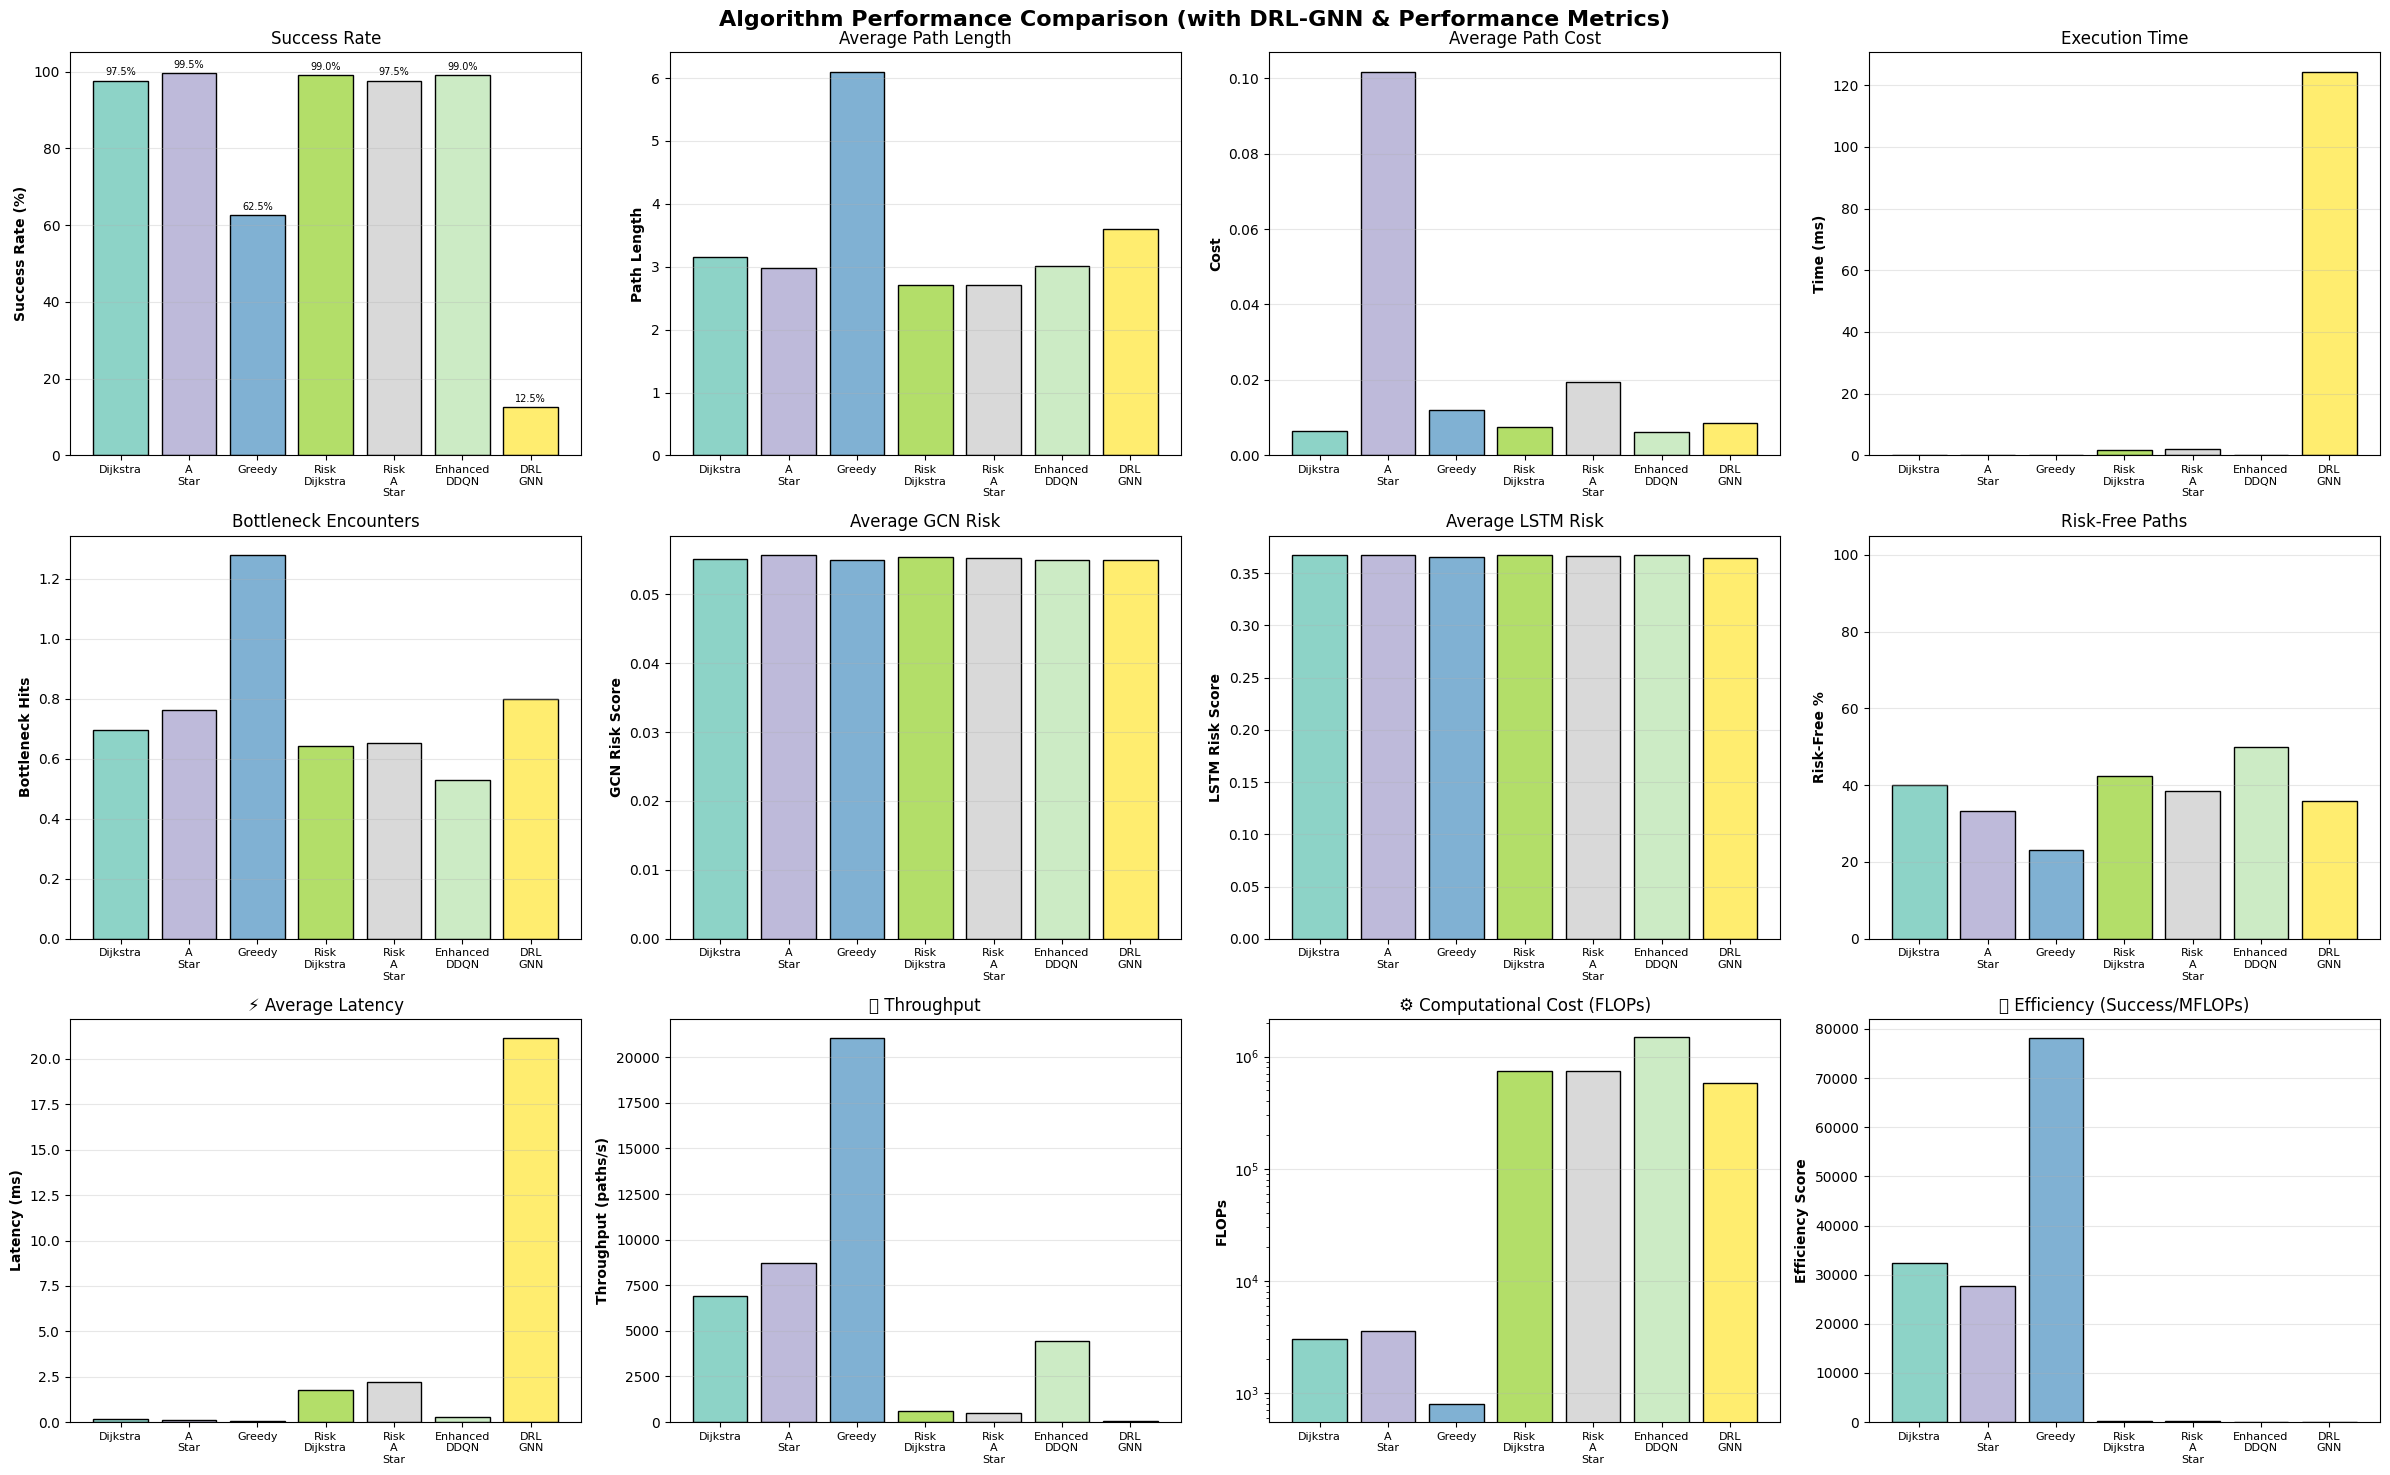

✓ Results exported to: /content/algorithm_comparison_enhanced.csv

ENHANCED COMPARISON COMPLETE

📊 Key Insights:
  • Dijkstra/A*: Optimal cost but ignores risks
  • Risk-aware variants: Balance cost vs safety using GCN
  • Enhanced DDQN: Learns adaptive risk-reward tradeoffs
  • DRL-GNN: Paper baseline with MPNN architecture
  • Greedy: Fast but suboptimal and risky

🎯 Performance Metrics:
  • Latency: Measures per-path response time
  • Throughput: Paths processed per second
  • FLOPs: Computational efficiency comparison

📁 Output Files:
  • Enhanced plot: /content/algorithm_comparison_enhanced.png
  • Enhanced CSV: /content/algorithm_comparison_enhanced.csv



In [ ]:
import torch
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque, OrderedDict
from tqdm.notebook import tqdm
import pandas as pd
import logging
import os
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# ============================================================================
# CONFIGURATION
# ============================================================================

EVAL_CONFIG = {
    'max_steps': 20,
    'gcn_risk_weight_multiplier': 1000,
    'risk_weight_default': 5.0,
    'save_dir': os.getenv('EVAL_SAVE_DIR', '/content'),
}

# ============================================================================
# BASELINE ALGORITHMS IMPLEMENTATION
# ============================================================================

class BaselineAlgorithms:
    """Collection of baseline pathfinding algorithms for comparison"""

    @staticmethod
    def dijkstra(env, source, target):
        """Standard Dijkstra's shortest path"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        try:
            path_names = nx.dijkstra_path(G, source_name, target_name, weight='weight')
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"Dijkstra failed: {e}")
            return None, float('inf'), False

    @staticmethod
    def astar(env, source, target):
        """A* algorithm with heuristic"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        def heuristic(u, v):
            u_idx = env.current_graph.node_to_idx.get(u, 0)
            v_idx = env.current_graph.node_to_idx.get(v, 0)
            return abs(u_idx - v_idx)

        try:
            path_names = nx.astar_path(G, source_name, target_name,
                                      heuristic=heuristic, weight='weight')
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"A* failed: {e}")
            return None, float('inf'), False

    @staticmethod
    def greedy_best_first(env, source, target, max_steps=20):
        """Greedy algorithm - always moves to lowest cost neighbor"""
        G = env.current_graph.networkx_graph
        current = source
        path = [current]
        visited = set([current])
        total_cost = 0

        for _ in range(max_steps):
            if current == target:
                return path, total_cost, True

            current_name = env.current_graph.idx_to_node[current]
            neighbors = list(G.successors(current_name))

            if not neighbors:
                return None, float('inf'), False

            best_neighbor = None
            best_cost = float('inf')

            for neighbor_name in neighbors:
                neighbor_idx = env.current_graph.node_to_idx[neighbor_name]
                if neighbor_idx not in visited:
                    edge_cost = G[current_name][neighbor_name]['weight']
                    if edge_cost < best_cost:
                        best_cost = edge_cost
                        best_neighbor = neighbor_idx

            if best_neighbor is None:
                neighbor_name = neighbors[0]
                best_neighbor = env.current_graph.node_to_idx[neighbor_name]
                best_cost = G[current_name][neighbor_name]['weight']

            path.append(best_neighbor)
            visited.add(best_neighbor)
            total_cost += best_cost
            current = best_neighbor

        return None, float('inf'), False


# ============================================================================
# RISK-AWARE BASELINE ALGORITHMS
# ============================================================================

class RiskAwareBaselines:
    """Baseline algorithms enhanced with GCN risk awareness"""

    @staticmethod
    def _compute_gcn_risks(env, gcn_model):
        """Helper to compute GCN risks once"""
        gcn_risks = {}
        if gcn_model is not None:
            try:
                with torch.no_grad():
                    x = env.current_graph.x[:, :12].to(device)
                    edge_index = env.current_graph.edge_index.to(device)
                    features = gcn_model(x, edge_index)

                    if hasattr(gcn_model, 'lin'):
                        logits = gcn_model.lin(features)
                        probs = torch.softmax(logits, dim=1)[:, 1]
                    elif hasattr(gcn_model, 'classifier'):
                        logits = gcn_model.classifier(features)
                        probs = torch.softmax(logits, dim=1)[:, 1]
                    elif hasattr(gcn_model, 'predict_bottlenecks'):
                        probs = gcn_model.predict_bottlenecks(x, edge_index)
                    else:
                        probs = torch.zeros(features.shape[0]).to(device)

                    gcn_risks = {i: float(probs[i].item()) for i in range(env.current_graph.num_nodes)}
            except Exception as e:
                logger.warning(f"GCN risk computation failed: {e}")
        return gcn_risks

    @staticmethod
    def risk_aware_dijkstra(env, source, target, gcn_model=None, risk_weight=5.0):
        """Dijkstra with GCN risk penalties"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        gcn_risks = RiskAwareBaselines._compute_gcn_risks(env, gcn_model)

        def weight_function(u, v, d):
            v_idx = env.current_graph.node_to_idx[v]
            base_weight = d['weight']
            risk_penalty = gcn_risks.get(v_idx, 0.0) * risk_weight * EVAL_CONFIG['gcn_risk_weight_multiplier']
            return base_weight + risk_penalty

        try:
            path_names = nx.dijkstra_path(G, source_name, target_name, weight=weight_function)
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"Risk-aware Dijkstra failed: {e}")
            return None, float('inf'), False

    @staticmethod
    def risk_aware_astar(env, source, target, gcn_model=None, risk_weight=5.0):
        """A* with GCN risk penalties"""
        G = env.current_graph.networkx_graph
        source_name = env.current_graph.idx_to_node[source]
        target_name = env.current_graph.idx_to_node[target]

        gcn_risks = RiskAwareBaselines._compute_gcn_risks(env, gcn_model)

        def weight_function(u, v, d):
            v_idx = env.current_graph.node_to_idx[v]
            base_weight = d['weight']
            risk_penalty = gcn_risks.get(v_idx, 0.0) * risk_weight * EVAL_CONFIG['gcn_risk_weight_multiplier']
            return base_weight + risk_penalty

        def heuristic(u, v):
            u_idx = env.current_graph.node_to_idx.get(u, 0)
            v_idx = env.current_graph.node_to_idx.get(v, 0)
            return abs(u_idx - v_idx)

        try:
            path_names = nx.astar_path(G, source_name, target_name,
                                      heuristic=heuristic, weight=weight_function)
            path = [env.current_graph.node_to_idx[n] for n in path_names]

            cost = 0
            for i in range(len(path) - 1):
                u = path_names[i]
                v = path_names[i + 1]
                cost += G[u][v]['weight']

            return path, cost, True
        except (nx.NetworkXNoPath, nx.NodeNotFound) as e:
            logger.debug(f"Risk-aware A* failed: {e}")
            return None, float('inf'), False


# ============================================================================
# FLOPS COUNTER
# ============================================================================

class FLOPsCounter:
    """Count FLOPs for different algorithm operations"""

    @staticmethod
    def count_gcn_forward(gcn_model, num_nodes, num_edges):
        """Estimate FLOPs for GCN forward pass"""
        if gcn_model is None:
            return 0

        flops = 0
        # Input projection (assume 12 -> 64)
        flops += num_nodes * 12 * 64 * 2  # MatMul + bias

        # GCN layers (assume 2 layers, 64 -> 64)
        for _ in range(2):
            flops += num_edges * 64 * 2  # Message passing
            flops += num_nodes * 64 * 64 * 2  # Transformation

        # Classifier (64 -> 2)
        flops += num_nodes * 64 * 2 * 2

        return flops

    @staticmethod
    def count_lstm_forward(lstm_model, seq_len=10, hidden_dim=64):
        """Estimate FLOPs for LSTM forward pass"""
        if lstm_model is None:
            return 0

        # LSTM: 4 gates × (input_dim × hidden + hidden × hidden) × 2 (MAC)
        flops = seq_len * 4 * (hidden_dim * hidden_dim + hidden_dim * hidden_dim) * 2

        # Classifier (assume 64 -> 2)
        flops += hidden_dim * 2 * 2

        return flops

    @staticmethod
    def count_graph_ops(num_nodes, num_edges, algorithm_type):
        """Estimate FLOPs for graph algorithm operations"""
        if algorithm_type in ['Dijkstra', 'Risk_Dijkstra']:
            return int(num_edges * np.log2(max(num_nodes, 2)) * 10)
        elif algorithm_type in ['A_Star', 'Risk_A_Star']:
            return int(num_edges * np.log2(max(num_nodes, 2)) * 12)
        elif algorithm_type == 'Greedy':
            return int(num_nodes * 20)
        return 0


# ============================================================================
# DRL-GNN ARCHITECTURE DEFINITIONS (FOR LOADING)
# ============================================================================

class ExactMPNN(nn.Module):
    """EXACT replication of DRL-GNN MPNN architecture"""

    def __init__(self, hparams, input_dim):
        super(ExactMPNN, self).__init__()
        self.hparams = hparams

        self.Message = nn.Sequential(
            nn.Linear(hparams['link_state_dim'] * 2, hparams['link_state_dim']),
            nn.SELU()
        )

        self.Update = nn.GRUCell(hparams['link_state_dim'], hparams['link_state_dim'])

        self.Readout = nn.Sequential(
            nn.Linear(hparams['link_state_dim'], hparams['readout_units']),
            nn.SELU(),
            nn.Dropout(hparams['dropout_rate']),
            nn.Linear(hparams['readout_units'], hparams['readout_units']),
            nn.SELU(),
            nn.Dropout(hparams['dropout_rate']),
            nn.Linear(hparams['readout_units'], 1)
        )

        self.InputProjection = nn.Linear(input_dim, hparams['link_state_dim'])

    def forward(self, node_features, edge_index, num_nodes, training=False):
        link_state = self.InputProjection(node_features)
        sources = edge_index[0]
        targets = edge_index[1]

        for t in range(self.hparams['T']):
            src_feats = link_state[sources]
            tgt_feats = link_state[targets]
            concat_feats = torch.cat([src_feats, tgt_feats], dim=1)
            messages = self.Message(concat_feats)

            aggregated = torch.zeros(num_nodes, self.hparams['link_state_dim'],
                                   dtype=link_state.dtype, device=link_state.device)
            aggregated.scatter_add_(0, targets.unsqueeze(1).expand(-1, self.hparams['link_state_dim']), messages)
            link_state = self.Update(aggregated, link_state)

        graph_embedding = torch.sum(link_state, dim=0, keepdim=True)

        if training:
            self.Readout.train()
        else:
            self.Readout.eval()

        q_value = self.Readout(graph_embedding)
        return q_value


class EnvironmentAdapterFixed:
    """Fixed adapter with proper state synchronization"""

    def __init__(self, env):
        self.env = env
        self.current_node = None
        self.target_node = None

    def reset(self):
        obs, info = self.env.reset()
        self.current_node = self.env.current_node
        self.target_node = self.env.target_node
        return obs, info

    def get_graph_for_action(self, action):
        graph = self.env.current_graph
        original_features = graph.x.clone()
        marking_features = torch.zeros((graph.num_nodes, 2),
                                      dtype=original_features.dtype,
                                      device=original_features.device)
        node_features = torch.cat([original_features, marking_features], dim=1)
        node_features[self.current_node, -2] = 1.0
        node_features[action, -1] = 1.0
        return node_features, graph.edge_index, graph.num_nodes

    def get_valid_actions(self):
        self.current_node = self.env.current_node
        if self.current_node == self.target_node:
            return []
        return self.env.neighbor_cache.get(self.current_node, [])

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.current_node = self.env.current_node
        return obs, reward, terminated, truncated, info


class DRLGNNAgentFixed:
    """Fixed DRL-GNN agent with proper state management"""

    def __init__(self, env, hparams):
        self.env_adapter = EnvironmentAdapterFixed(env)
        self.memory = deque(maxlen=4000)
        self.gamma = 0.95
        self.epsilon = 0.01

        sample_obs, _ = env.reset()
        self.input_dim = env.current_graph.x.shape[1] + 2

        self.primary_network = ExactMPNN(hparams, self.input_dim).to(device)
        self.target_network = ExactMPNN(hparams, self.input_dim).to(device)

    def act(self, info, flag_evaluation):
        valid_actions = self.env_adapter.get_valid_actions()
        if not valid_actions:
            return None, None

        if self.env_adapter.current_node == self.env_adapter.target_node:
            return None, None

        q_values = []
        graph_representations = []

        self.primary_network.eval()
        with torch.no_grad():
            for action in valid_actions:
                try:
                    node_features, edge_index, num_nodes = self.env_adapter.get_graph_for_action(action)
                    q_val = self.primary_network(
                        node_features.to(device),
                        edge_index.to(device),
                        num_nodes,
                        training=False
                    )
                    q_values.append(q_val.item())
                    graph_representations.append((node_features, edge_index, num_nodes))
                except:
                    q_values.append(float('-inf'))
                    graph_representations.append(None)

        if not q_values or all(q == float('-inf') for q in q_values):
            return None, None

        best_idx = np.argmax(q_values)
        best_action = valid_actions[best_idx]
        best_graph = graph_representations[best_idx]

        if best_graph is None:
            return None, None

        return best_action, best_graph


# ============================================================================
# MODEL LOADING UTILITIES
# ============================================================================

def load_drl_gnn_agent(test_env):
    """Load trained DRL-GNN agent from checkpoint"""
    try:
        checkpoint_dir = "./models_DRL_GNN_Baseline_Temporal"
        if not os.path.exists(checkpoint_dir):
            logger.warning("DRL-GNN checkpoint directory not found")
            return None

        checkpoints = [f for f in os.listdir(checkpoint_dir) if f.startswith('ckpt-')]
        if not checkpoints:
            logger.warning("No DRL-GNN checkpoints found")
            return None

        checkpoint_nums = [int(f.split('-')[1]) for f in checkpoints]
        best_ckpt_num = max(checkpoint_nums)
        checkpoint_path = os.path.join(checkpoint_dir, f'ckpt-{best_ckpt_num}')

        logger.info(f"Loading DRL-GNN from: {checkpoint_path}")

        hparams = {
            'l2': 0.1,
            'dropout_rate': 0.01,
            'link_state_dim': 20,
            'readout_units': 35,
            'learning_rate': 0.0001,
            'batch_size': 32,
            'T': 4,
        }

        drl_gnn_agent = DRLGNNAgentFixed(test_env, hparams)

        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
        drl_gnn_agent.primary_network.load_state_dict(checkpoint['model_state_dict'])
        drl_gnn_agent.target_network.load_state_dict(checkpoint['model_state_dict'])
        drl_gnn_agent.primary_network.eval()
        drl_gnn_agent.target_network.eval()

        logger.info(f"✓ DRL-GNN loaded successfully (iteration {checkpoint.get('iteration', 'unknown')})")
        return drl_gnn_agent

    except Exception as e:
        logger.error(f"Failed to load DRL-GNN: {e}")
        return None


# ============================================================================
# COMPREHENSIVE COMPARISON FRAMEWORK
# ============================================================================

class AlgorithmComparison:
    """Complete comparison framework for all algorithms"""

    def __init__(self, test_env, trained_agent, gcn_model=None, lstm_model=None, drl_gnn_agent=None):
        self.env = test_env
        self.agent = trained_agent
        self.gcn_model = gcn_model
        self.lstm_model = lstm_model
        self.drl_gnn_agent = drl_gnn_agent
        self.baseline = BaselineAlgorithms()
        self.risk_aware = RiskAwareBaselines()
        self.flops_counter = FLOPsCounter()

    def compute_lstm_risk(self, path):
        """Compute LSTM risk using proper 64-dim GCN features"""
        if self.lstm_model is None or self.gcn_model is None or len(path) < 2:
            return 0.0

        try:
            with torch.no_grad():
                x = self.env.current_graph.x[:, :12].to(device)
                edge_index = self.env.current_graph.edge_index.to(device)

                # Extract GCN features (64-dim)
                if hasattr(self.gcn_model, 'extract_features'):
                    gcn_features = self.gcn_model.extract_features(x, edge_index)
                else:
                    gcn_features = self.gcn_model(x, edge_index)

                path_seq = path[-10:]
                if len(path_seq) < 10:
                    path_seq = [path_seq[0]] * (10 - len(path_seq)) + path_seq

                seq = torch.stack([gcn_features[n] for n in path_seq]).unsqueeze(0)

                # Get LSTM features
                if hasattr(self.lstm_model, 'extract_features'):
                    features = self.lstm_model.extract_features(seq)
                else:
                    features = self.lstm_model(seq)

                if hasattr(self.lstm_model, 'classifier'):
                    logits = self.lstm_model.classifier(features)
                    risk_probs = torch.softmax(logits, dim=1)
                    risk = float(risk_probs[:, 1].item())
                elif hasattr(self.lstm_model, 'predict_bottlenecks'):
                    risk_prob = self.lstm_model.predict_bottlenecks(seq)
                    risk = float(risk_prob.item())
                else:
                    risk = 0.0

                return risk
        except Exception as e:
            logger.debug(f"LSTM risk computation failed: {e}")
            return 0.0

    def compute_gcn_risk(self, path):
        """Compute average GCN risk for a path"""
        if self.gcn_model is None or len(path) == 0:
            return 0.0

        try:
            with torch.no_grad():
                x = self.env.current_graph.x[:, :12].to(device)
                edge_index = self.env.current_graph.edge_index.to(device)

                if hasattr(self.gcn_model, 'extract_features'):
                    features = self.gcn_model.extract_features(x, edge_index)
                else:
                    features = self.gcn_model(x, edge_index)

                if hasattr(self.gcn_model, 'predict_bottlenecks'):
                    probs = self.gcn_model.predict_bottlenecks(x, edge_index)
                elif hasattr(self.gcn_model, 'lin'):
                    logits = self.gcn_model.lin(features)
                    probs = torch.softmax(logits, dim=1)[:, 1]
                elif hasattr(self.gcn_model, 'classifier'):
                    logits = self.gcn_model.classifier(features)
                    probs = torch.softmax(logits, dim=1)[:, 1]
                else:
                    return 0.0

                gcn_risk = sum(float(probs[node].item()) for node in path) / len(path)
                return gcn_risk
        except Exception as e:
            logger.debug(f"GCN risk computation failed: {e}")
            return 0.0

    def run_episode(self, algorithm_name, max_steps=None):
        """Run single episode with specified algorithm"""
        if max_steps is None:
            max_steps = EVAL_CONFIG['max_steps']

        try:
            obs, _ = self.env.reset()

            if algorithm_name == 'Enhanced_DDQN' and hasattr(self.agent, 'set_pathfinder'):
                self.agent.set_pathfinder(self.env)

            source = self.env.current_node
            target = self.env.target_node
            start_time = time.perf_counter()

            total_flops = 0
            path = None
            cost = float('inf')
            success = False

            # Execute algorithm
            if algorithm_name == 'Dijkstra':
                path, cost, success = self.baseline.dijkstra(self.env, source, target)
                total_flops = self.flops_counter.count_graph_ops(
                    self.env.current_graph.num_nodes,
                    self.env.current_graph.edge_index.shape[1],
                    'Dijkstra'
                )

            elif algorithm_name == 'A_Star':
                path, cost, success = self.baseline.astar(self.env, source, target)
                total_flops = self.flops_counter.count_graph_ops(
                    self.env.current_graph.num_nodes,
                    self.env.current_graph.edge_index.shape[1],
                    'A_Star'
                )

            elif algorithm_name == 'Greedy':
                path, cost, success = self.baseline.greedy_best_first(self.env, source, target, max_steps)
                total_flops = self.flops_counter.count_graph_ops(
                    self.env.current_graph.num_nodes,
                    self.env.current_graph.edge_index.shape[1],
                    'Greedy'
                )

            elif algorithm_name == 'Risk_Dijkstra':
                path, cost, success = self.risk_aware.risk_aware_dijkstra(
                    self.env, source, target, self.gcn_model, risk_weight=EVAL_CONFIG['risk_weight_default']
                )
                total_flops = (
                    self.flops_counter.count_gcn_forward(
                        self.gcn_model,
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1]
                    ) +
                    self.flops_counter.count_graph_ops(
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1],
                        'Risk_Dijkstra'
                    )
                )

            elif algorithm_name == 'Risk_A_Star':
                path, cost, success = self.risk_aware.risk_aware_astar(
                    self.env, source, target, self.gcn_model, risk_weight=EVAL_CONFIG['risk_weight_default']
                )
                total_flops = (
                    self.flops_counter.count_gcn_forward(
                        self.gcn_model,
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1]
                    ) +
                    self.flops_counter.count_graph_ops(
                        self.env.current_graph.num_nodes,
                        self.env.current_graph.edge_index.shape[1],
                        'Risk_A_Star'
                    )
                )

            elif algorithm_name == 'Enhanced_DDQN':
                path = [source]
                done = False
                success = False
                steps = 0
                cost = 0

                while not done and steps < max_steps:
                    try:
                        G = self.env.current_graph.networkx_graph
                        current_name = self.env.current_graph.idx_to_node[self.env.current_node]
                        valid_actions = [self.env.current_graph.node_to_idx[n]
                                       for n in G.successors(current_name)]

                        if not valid_actions:
                            success = False
                            break

                        # Use agent's select_action method
                        if hasattr(self.agent, 'select_action'):
                            action = self.agent.select_action(obs, self.env, valid_actions)
                        else:
                            # Fallback for different agent structures
                            with torch.no_grad():
                                state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                                q_values = self.agent.q_net(state_t)[0]
                                mask = torch.full((q_values.shape[1],), float('-inf')).to(device)
                                mask[valid_actions] = 0
                                q_values = q_values + mask
                                action = q_values.argmax().item()

                        # Count FLOPs for this step
                        total_flops += self.flops_counter.count_gcn_forward(
                            self.gcn_model,
                            self.env.current_graph.num_nodes,
                            self.env.current_graph.edge_index.shape[1]
                        )

                        if action != self.env.current_node:
                            prev_name = current_name
                            next_name = self.env.current_graph.idx_to_node[action]
                            if G.has_edge(prev_name, next_name):
                                cost += G[prev_name][next_name]['weight']

                        next_obs, _, done, truncated, info = self.env.step(action)
                        path.append(self.env.current_node)

                        obs = next_obs
                        steps += 1

                        if done or truncated:
                            success = info.get('success', False)
                            break
                    except Exception as e:
                        logger.error(f"DDQN step failed: {e}")
                        success = False
                        break

                if not done and steps >= max_steps:
                    success = False

            elif algorithm_name == 'DRL_GNN':
                if self.drl_gnn_agent is None:
                    if not hasattr(self, '_drl_gnn_warning_shown'):
                        logger.info("DRL-GNN agent not available - skipping")
                        self._drl_gnn_warning_shown = True
                    return {
                        'success': False, 'path_length': 0, 'cost': float('inf'),
                        'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                        'lstm_risk': 0.0, 'risk_free': False,
                        'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
                    }

                if not hasattr(self.drl_gnn_agent, 'env_adapter'):
                    if not hasattr(self, '_drl_gnn_adapter_warning_shown'):
                        logger.info("DRL-GNN agent missing env_adapter")
                        self._drl_gnn_adapter_warning_shown = True
                    return {
                        'success': False, 'path_length': 0, 'cost': float('inf'),
                        'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                        'lstm_risk': 0.0, 'risk_free': False,
                        'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
                    }

                path = [source]
                done = False
                success = False
                steps = 0
                cost = 0

                try:
                    self.drl_gnn_agent.env_adapter.env = self.env
                    self.drl_gnn_agent.env_adapter.current_node = source
                    self.drl_gnn_agent.env_adapter.target_node = target
                except Exception as e:
                    if not hasattr(self, '_drl_gnn_init_warning_shown'):
                        logger.error(f"Failed to initialize DRL-GNN adapter: {e}")
                        self._drl_gnn_init_warning_shown = True
                    return {
                        'success': False, 'path_length': 0, 'cost': float('inf'),
                        'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                        'lstm_risk': 0.0, 'risk_free': False,
                        'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
                    }

                while not done and steps < max_steps:
                    try:
                        if self.env.current_node == target:
                            success = True
                            done = True
                            break

                        action, state_graph = self.drl_gnn_agent.act(None, flag_evaluation=True)

                        if action is None:
                            break

                        if state_graph:
                            node_features, edge_index, num_nodes = state_graph
                            T = 4
                            link_dim = 20
                            total_flops += (
                                num_nodes * 12 * link_dim * 2 +
                                T * edge_index.shape[1] * link_dim * 2 * 2 +
                                T * num_nodes * link_dim * link_dim * 2 +
                                num_nodes * link_dim * 35 * 2 +
                                35 * 35 * 2 +
                                35 * 1 * 2
                            )

                        next_obs, step_reward, terminated, truncated, info = self.env.step(action)
                        done = terminated or truncated

                        G = self.env.current_graph.networkx_graph
                        if len(path) > 0:
                            prev_node = path[-1]
                            prev_name = self.env.current_graph.idx_to_node[prev_node]
                            next_name = self.env.current_graph.idx_to_node[action]
                            if G.has_edge(prev_name, next_name):
                                cost += G[prev_name][next_name]['weight']

                        self.drl_gnn_agent.env_adapter.current_node = self.env.current_node

                        path.append(action)
                        steps += 1

                        if done:
                            success = info.get('success', False)
                            break

                    except Exception as e:
                        logger.error(f"DRL-GNN step failed at step {steps}: {e}")
                        success = False
                        break

                if not done and steps >= max_steps:
                    success = False

            else:
                raise ValueError(f"Unknown algorithm: {algorithm_name}")

            exec_time = (time.perf_counter() - start_time) * 1000
            latency_ms = exec_time
            throughput = (1000.0 / exec_time) if exec_time > 0 else 0.0

            if path and success:
                bottleneck_hits = sum(1 for node in path if node in self.env.bottleneck_nodes)
                gcn_risk = self.compute_gcn_risk(path)
                lstm_risk = self.compute_lstm_risk(path)

                return {
                    'success': True,
                    'path_length': len(path),
                    'cost': cost / 1000.0,
                    'time_ms': exec_time,
                    'bottleneck_hits': bottleneck_hits,
                    'gcn_risk': gcn_risk,
                    'lstm_risk': lstm_risk,
                    'risk_free': bottleneck_hits == 0,
                    'latency_ms': latency_ms,
                    'throughput': throughput,
                    'flops': total_flops
                }
            else:
                return {
                    'success': False,
                    'path_length': 0,
                    'cost': float('inf'),
                    'time_ms': exec_time,
                    'bottleneck_hits': 0,
                    'gcn_risk': 0.0,
                    'lstm_risk': 0.0,
                    'risk_free': False,
                    'latency_ms': latency_ms,
                    'throughput': 0.0,
                    'flops': total_flops
                }

        except Exception as e:
            logger.error(f"Error in {algorithm_name}: {e}", exc_info=True)
            return {
                'success': False, 'path_length': 0, 'cost': float('inf'),
                'time_ms': 0.0, 'bottleneck_hits': 0, 'gcn_risk': 0.0,
                'lstm_risk': 0.0, 'risk_free': False,
                'latency_ms': 0.0, 'throughput': 0.0, 'flops': 0
            }

    def compare_algorithms(self, num_episodes=200):
        """Compare all algorithms over multiple episodes"""
        algorithms = [
            'Dijkstra',
            'A_Star',
            'Greedy',
            'Risk_Dijkstra',
            'Risk_A_Star',
            'Enhanced_DDQN',
            'DRL_GNN'
        ]

        results = {alg: [] for alg in algorithms}
        failed_counts = {alg: 0 for alg in algorithms}

        print("=" * 80)
        print("RUNNING ALGORITHM COMPARISON (WITH DRL-GNN + PERFORMANCE METRICS)")
        print("=" * 80)
        print(f"Testing {len(algorithms)} algorithms on {num_episodes} episodes\n")

        for alg in algorithms:
            print(f"\n{alg:20s} ", end='', flush=True)

            for ep in tqdm(range(num_episodes), desc=alg, leave=False):
                result = self.run_episode(alg)
                results[alg].append(result)

                if not result['success']:
                    failed_counts[alg] += 1

            successes = sum(1 for r in results[alg] if r['success'])
            print(f"✓ Complete - Success: {successes}/{num_episodes} ({100*successes/num_episodes:.1f}%)")

            if failed_counts[alg] > 0:
                logger.info(f"  {alg}: {failed_counts[alg]} failures")

        return self._compute_statistics(results)

    def _compute_statistics(self, results):
        """Compute comprehensive statistics for all algorithms"""
        stats = {}

        for alg, episodes in results.items():
            successful = [e for e in episodes if e['success']]

            if successful:
                valid_costs = [e['cost'] for e in successful if e['cost'] != float('inf')]

                stats[alg] = {
                    'success_rate': len(successful) / len(episodes) * 100,
                    'avg_path_length': np.mean([e['path_length'] for e in successful]),
                    'std_path_length': np.std([e['path_length'] for e in successful]),
                    'avg_cost': np.mean(valid_costs) if valid_costs else 0.0,
                    'std_cost': np.std(valid_costs) if valid_costs else 0.0,
                    'avg_time_ms': np.mean([e['time_ms'] for e in episodes]),
                    'avg_bottleneck_hits': np.mean([e['bottleneck_hits'] for e in successful]),
                    'avg_gcn_risk': np.mean([e['gcn_risk'] for e in successful]),
                    'avg_lstm_risk': np.mean([e['lstm_risk'] for e in successful]),
                    'risk_free_paths': sum(1 for e in successful if e['risk_free']) / len(successful) * 100,
                    'total_episodes': len(episodes),
                    'successful_episodes': len(successful),
                    'avg_latency_ms': np.mean([e['latency_ms'] for e in successful]),
                    'avg_throughput': np.mean([e['throughput'] for e in successful]),
                    'avg_flops': np.mean([e['flops'] for e in successful])
                }
            else:
                stats[alg] = {
                    'success_rate': 0.0,
                    'avg_path_length': 0.0,
                    'std_path_length': 0.0,
                    'avg_cost': 0.0,
                    'std_cost': 0.0,
                    'avg_time_ms': np.mean([e['time_ms'] for e in episodes]) if episodes else 0.0,
                    'avg_bottleneck_hits': 0.0,
                    'avg_gcn_risk': 0.0,
                    'avg_lstm_risk': 0.0,
                    'risk_free_paths': 0.0,
                    'total_episodes': len(episodes),
                    'successful_episodes': 0,
                    'avg_latency_ms': 0.0,
                    'avg_throughput': 0.0,
                    'avg_flops': 0.0
                }

        return stats

    def print_comparison_table(self, stats):
        """Print comprehensive comparison table"""
        print("\n" + "=" * 150)
        print("ALGORITHM COMPARISON RESULTS (WITH DRL-GNN + PERFORMANCE METRICS)")
        print("=" * 150)

        df_data = []
        for alg, metrics in stats.items():
            df_data.append({
                'Algorithm': alg.replace('_', ' '),
                'Success %': f"{metrics['success_rate']:.1f}",
                'Path Len': f"{metrics['avg_path_length']:.2f}±{metrics['std_path_length']:.2f}",
                'Cost': f"{metrics['avg_cost']:.4f}",
                'Time (ms)': f"{metrics['avg_time_ms']:.2f}",
                'BN Hits': f"{metrics['avg_bottleneck_hits']:.2f}",
                'GCN Risk': f"{metrics['avg_gcn_risk']:.4f}",
                'LSTM Risk': f"{metrics['avg_lstm_risk']:.4f}",
                'Risk-Free %': f"{metrics['risk_free_paths']:.1f}",
                'Latency (ms)': f"{metrics['avg_latency_ms']:.2f}",
                'Throughput': f"{metrics['avg_throughput']:.1f}",
                'FLOPs': f"{metrics['avg_flops']:.2e}"
            })

        df = pd.DataFrame(df_data)
        print(df.to_string(index=False))
        print("=" * 150)

        print("\n⭐ CATEGORY WINNERS:")
        print("-" * 100)

        best_success = max(stats.items(), key=lambda x: x[1]['success_rate'])
        print(f"  Best Success Rate:     {best_success[0].replace('_', ' '):20s} ({best_success[1]['success_rate']:.1f}%)")

        successful_algs = {k: v for k, v in stats.items() if v['successful_episodes'] > 0}
        if successful_algs:
            best_path = min(successful_algs.items(), key=lambda x: x[1]['avg_path_length'])
            print(f"  Shortest Path:         {best_path[0].replace('_', ' '):20s} ({best_path[1]['avg_path_length']:.2f} nodes)")

            best_cost = min(successful_algs.items(), key=lambda x: x[1]['avg_cost'])
            print(f"  Lowest Cost:           {best_cost[0].replace('_', ' '):20s} ({best_cost[1]['avg_cost']:.4f})")

            best_time = min(successful_algs.items(), key=lambda x: x[1]['avg_time_ms'])
            print(f"  Fastest:               {best_time[0].replace('_', ' '):20s} ({best_time[1]['avg_time_ms']:.2f} ms)")

            best_safe = min(successful_algs.items(), key=lambda x: x[1]['avg_bottleneck_hits'])
            print(f"  Safest (BN):           {best_safe[0].replace('_', ' '):20s} ({best_safe[1]['avg_bottleneck_hits']:.2f} hits)")

            best_gcn = min(successful_algs.items(), key=lambda x: x[1]['avg_gcn_risk'])
            print(f"  Lowest GCN Risk:       {best_gcn[0].replace('_', ' '):20s} ({best_gcn[1]['avg_gcn_risk']:.4f})")

            best_lstm = min(successful_algs.items(), key=lambda x: x[1]['avg_lstm_risk'])
            print(f"  Lowest LSTM Risk:      {best_lstm[0].replace('_', ' '):20s} ({best_lstm[1]['avg_lstm_risk']:.4f})")

            best_rf = max(successful_algs.items(), key=lambda x: x[1]['risk_free_paths'])
            print(f"  Most Risk-Free:        {best_rf[0].replace('_', ' '):20s} ({best_rf[1]['risk_free_paths']:.1f}%)")

            best_latency = min(successful_algs.items(), key=lambda x: x[1]['avg_latency_ms'])
            print(f"  Lowest Latency:        {best_latency[0].replace('_', ' '):20s} ({best_latency[1]['avg_latency_ms']:.2f} ms)")

            best_throughput = max(successful_algs.items(), key=lambda x: x[1]['avg_throughput'])
            print(f"  Highest Throughput:    {best_throughput[0].replace('_', ' '):20s} ({best_throughput[1]['avg_throughput']:.1f} paths/s)")

            best_efficiency = min(successful_algs.items(), key=lambda x: x[1]['avg_flops'])
            print(f"  Most Efficient (FLOPs):{best_efficiency[0].replace('_', ' '):20s} ({best_efficiency[1]['avg_flops']:.2e})")

        print("-" * 100)

    def plot_comparison(self, stats, save_path=None):
        """Create comprehensive comparison visualizations"""
        fig, axes = plt.subplots(3, 4, figsize=(24, 15))
        fig.suptitle('Algorithm Performance Comparison (with DRL-GNN & Performance Metrics)',
                     fontsize=16, fontweight='bold')

        algorithms = list(stats.keys())
        colors = plt.cm.Set3(np.linspace(0, 1, len(algorithms)))

        # Row 1: Original metrics
        # 1. Success Rate
        ax = axes[0, 0]
        success_rates = [stats[alg]['success_rate'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), success_rates, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Success Rate (%)', fontweight='bold')
        ax.set_title('Success Rate')
        ax.set_ylim([0, 105])
        ax.grid(axis='y', alpha=0.3)
        for i, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{success_rates[i]:.1f}%', ha='center', va='bottom', fontsize=7)

        # 2. Path Length
        ax = axes[0, 1]
        path_lens = [stats[alg]['avg_path_length'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), path_lens, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Path Length', fontweight='bold')
        ax.set_title('Average Path Length')
        ax.grid(axis='y', alpha=0.3)

        # 3. Cost
        ax = axes[0, 2]
        costs = [stats[alg]['avg_cost'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), costs, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Cost', fontweight='bold')
        ax.set_title('Average Path Cost')
        ax.grid(axis='y', alpha=0.3)

        # 4. Execution Time
        ax = axes[0, 3]
        times = [stats[alg]['avg_time_ms'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), times, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Time (ms)', fontweight='bold')
        ax.set_title('Execution Time')
        ax.grid(axis='y', alpha=0.3)

        # Row 2: Risk metrics
        # 5. Bottleneck Hits
        ax = axes[1, 0]
        bn_hits = [stats[alg]['avg_bottleneck_hits'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), bn_hits, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Bottleneck Hits', fontweight='bold')
        ax.set_title('Bottleneck Encounters')
        ax.grid(axis='y', alpha=0.3)

        # 6. GCN Risk
        ax = axes[1, 1]
        gcn_risks = [stats[alg]['avg_gcn_risk'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), gcn_risks, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('GCN Risk Score', fontweight='bold')
        ax.set_title('Average GCN Risk')
        ax.grid(axis='y', alpha=0.3)

        # 7. LSTM Risk
        ax = axes[1, 2]
        lstm_risks = [stats[alg]['avg_lstm_risk'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), lstm_risks, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('LSTM Risk Score', fontweight='bold')
        ax.set_title('Average LSTM Risk')
        ax.grid(axis='y', alpha=0.3)

        # 8. Risk-Free Paths
        ax = axes[1, 3]
        rf_pct = [stats[alg]['risk_free_paths'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), rf_pct, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Risk-Free %', fontweight='bold')
        ax.set_title('Risk-Free Paths')
        ax.set_ylim([0, 105])
        ax.grid(axis='y', alpha=0.3)

        # Row 3: Performance metrics
        # 9. Latency
        ax = axes[2, 0]
        latencies = [stats[alg]['avg_latency_ms'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), latencies, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Latency (ms)', fontweight='bold')
        ax.set_title('⚡ Average Latency')
        ax.grid(axis='y', alpha=0.3)

        # 10. Throughput
        ax = axes[2, 1]
        throughputs = [stats[alg]['avg_throughput'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), throughputs, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Throughput (paths/s)', fontweight='bold')
        ax.set_title('🚀 Throughput')
        ax.grid(axis='y', alpha=0.3)

        # 11. FLOPs (log scale)
        ax = axes[2, 2]
        flops = [stats[alg]['avg_flops'] for alg in algorithms]
        bars = ax.bar(range(len(algorithms)), flops, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('FLOPs', fontweight='bold')
        ax.set_title('⚙️ Computational Cost (FLOPs)')
        ax.set_yscale('log')
        ax.grid(axis='y', alpha=0.3)

        # 12. Efficiency Score (Success Rate / FLOPs)
        ax = axes[2, 3]
        efficiency = []
        for alg in algorithms:
            if stats[alg]['avg_flops'] > 0:
                eff = stats[alg]['success_rate'] / (stats[alg]['avg_flops'] / 1e6)
            else:
                eff = stats[alg]['success_rate']
            efficiency.append(eff)
        bars = ax.bar(range(len(algorithms)), efficiency, color=colors, edgecolor='black')
        ax.set_xticks(range(len(algorithms)))
        ax.set_xticklabels([a.replace('_', '\n') for a in algorithms], rotation=0, fontsize=8)
        ax.set_ylabel('Efficiency Score', fontweight='bold')
        ax.set_title('🎯 Efficiency (Success/MFLOPs)')
        ax.grid(axis='y', alpha=0.3)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            logger.info(f"Comparison plot saved to: {save_path}")
            print(f"\n✓ Comparison plot saved to: {save_path}")

        plt.show()
        return fig

    def export_results_csv(self, stats, filepath=None):
        """Export results to CSV for further analysis"""
        if filepath is None:
            filepath = os.path.join(EVAL_CONFIG['save_dir'], 'algorithm_comparison_enhanced.csv')

        df_data = []
        for alg, metrics in stats.items():
            df_data.append({
                'Algorithm': alg.replace('_', ' '),
                'Success_Rate': metrics['success_rate'],
                'Avg_Path_Length': metrics['avg_path_length'],
                'Std_Path_Length': metrics['std_path_length'],
                'Avg_Cost': metrics['avg_cost'],
                'Std_Cost': metrics['std_cost'],
                'Avg_Time_ms': metrics['avg_time_ms'],
                'Avg_Bottleneck_Hits': metrics['avg_bottleneck_hits'],
                'Avg_GCN_Risk': metrics['avg_gcn_risk'],
                'Avg_LSTM_Risk': metrics['avg_lstm_risk'],
                'Risk_Free_Paths_Pct': metrics['risk_free_paths'],
                'Total_Episodes': metrics['total_episodes'],
                'Successful_Episodes': metrics['successful_episodes'],
                'Avg_Latency_ms': metrics['avg_latency_ms'],
                'Avg_Throughput': metrics['avg_throughput'],
                'Avg_FLOPs': metrics['avg_flops']
            })

        df = pd.DataFrame(df_data)
        df.to_csv(filepath, index=False)
        logger.info(f"Results exported to: {filepath}")
        print(f"✓ Results exported to: {filepath}")
        return df


# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("=" * 80)
print("INITIALIZING ENHANCED ALGORITHM COMPARISON")
print("=" * 80)

# Load DRL-GNN agent
drl_gnn_agent = load_drl_gnn_agent(test_env)

# Initialize comparison framework
comparator = AlgorithmComparison(
    test_env=test_env,
    trained_agent=agent,  # Your Enhanced DDQN agent
    gcn_model=gcn_model,
    lstm_model=lstm_model,
    drl_gnn_agent=drl_gnn_agent
)

# Run comparison
stats = comparator.compare_algorithms(num_episodes=200)

# Print results
comparator.print_comparison_table(stats)

# Plot comparison
save_path = os.path.join(EVAL_CONFIG['save_dir'], 'algorithm_comparison_enhanced.png')
comparison_plot = comparator.plot_comparison(stats, save_path=save_path)

# Export to CSV
csv_path = os.path.join(EVAL_CONFIG['save_dir'], 'algorithm_comparison_enhanced.csv')
results_df = comparator.export_results_csv(stats, csv_path)

print("\n" + "=" * 80)
print("ENHANCED COMPARISON COMPLETE")
print("=" * 80)
print("\n📊 Key Insights:")
print("  • Dijkstra/A*: Optimal cost but ignores risks")
print("  • Risk-aware variants: Balance cost vs safety using GCN")
print("  • Enhanced DDQN: Learns adaptive risk-reward tradeoffs")
print("  • DRL-GNN: Paper baseline with MPNN architecture")
print("  • Greedy: Fast but suboptimal and risky")

print("\n🎯 Performance Metrics:")
print("  • Latency: Measures per-path response time")
print("  • Throughput: Paths processed per second")
print("  • FLOPs: Computational efficiency comparison")

print("\n📁 Output Files:")
print(f"  • Enhanced plot: {save_path}")
print(f"  • Enhanced CSV: {csv_path}")

print("\n" + "=" * 80)